<pre style="color:#D00000;text-align:center;font-size:150%;font-weight:bold;font-family:Helvetica;background-color:#F9E4D0;border-style: solid;  border-color: coral; border-width: 1px;">
Portuguese Bank Marketing Campaign Analysis & Prediction
</pre>


 **Domain Perspective**

- Industry: The project is focused on the Finance/Banking sector, specifically looking at how a bank can improve its marketing campaigns for term deposit subscriptions.
  
- Problem Statement: The goal is to analyze customer data from a direct phone call marketing campaign aimed at promoting term deposits. The task is to predict customer behavior (whether they will subscribe to a term deposit) and offer suggestions to the marketing team to increase future subscriptions.

- Objective: The project has three main objectives: 
  1. Perform a data analysis to understand customer patterns.
  2. Build a predictive model to forecast which customers are likely to subscribe to a term deposit.
  3. Provide marketing Recommendations, Model Comparison and Challenges faced report to improve customer engagement.

- Target Audience: The target audience for this marketing campaign is existing customers of a Portuguese bank, reached out via direct phone calls from May 2008 to November 2010.

 **Data Perspective**

- Data Source: The dataset contains information from the bank’s marketing campaigns. It includes data about direct phone calls made to existing customers between 2008 and 2010. and used bank-additional-full.csv for this use case. 

- Variables: The dataset contains a variety of features, such as:
  - Demographic information (age, job, marital status, education).
  - Loan and credit details (housing loan, personal loan).
  - Campaign-related data (contact type, contact duration, previous campaign outcomes).
  - Economic context indicators (employment rate, consumer price index).

- Target Variable: The primary target variable is y, which indicates whether a customer subscribed to a term deposit ("yes" or "no").

- Input Variables: The dataset includes both categorical variables (e.g., job type, marital status, education level) and numerical variables (e.g., age, campaign duration, previous contact count). These features will help predict whether a customer subscribes to a term deposit.

---

# Data Analysis 

### Import data

In [ ]:
import sys
from pathlib import Path
import pandas as pd

# Project directory setup
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Define paths
DATA_PATH = project_root / "data" / "raw" / "bank-additional-full.csv"
PROCESSED_PATH = project_root / "data" / "processed"
MODELS_PATH = project_root / "models"
RESULTS_PATH = project_root / "results" / "figures"

# Create directories if they don't exist
(PROCESSED_PATH / "train_test").mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {project_root}")
print(f"Data Path: {DATA_PATH}")
print(f"Data exists: {DATA_PATH.exists()}")

# Load data
data = pd.read_csv(DATA_PATH, sep=";")

In [2]:
from tabulate import tabulate
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_colwidth", None)

### Imports & functions

In [ ]:
# pip install insightfulpy==0.1.7
from insightfulpy.eda import *

In [4]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# import dtale
from scipy import stats
from scipy.stats import (
    chi2_contingency,
    fisher_exact,
    pearsonr,
    spearmanr,
    ttest_ind,
    mannwhitneyu,
    shapiro,
)
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    learning_curve,
)
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils import resample, compute_class_weight

In [5]:
import time
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor
import catboost as cb
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
import scikitplot as skplt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder

---

In [ ]:
# Import utility functions from src
from src.utils import memory_usage, dataframe_memory_usage, garbage_collection

In [7]:
if __name__ == "__main__":
    memory_usage()

Memory Usage: 294.79 MB


In [8]:
dataframe_memory_usage(data)

DataFrame Memory Usage: 30.26 MB


30.260939598083496

----

In [ ]:
# Import statistical analysis functions from src
import sys
from pathlib import Path

if str(Path().absolute().parent) not in sys.path:
    sys.path.insert(0, str(Path().absolute().parent))

from src.statistical_analysis import (
    chi_square_test,
    fisher_exact_test,
    spearman_correlation_with_target,
    hypothesis_testing_mann_whitney,
    cap_outliers_percentile,
    normality_test_with_skew_kurt,
    spearman_correlation,
    calculate_vif,
)

---

## Data understanding and cleaning

In [10]:
print(data.shape)
for idx, col in enumerate(data.columns):
    print(f"{idx}: {col}")

(41188, 21)
0: age
1: job
2: marital
3: education
4: default
5: housing
6: loan
7: contact
8: month
9: day_of_week
10: duration
11: campaign
12: pdays
13: previous
14: poutcome
15: emp.var.rate
16: cons.price.idx
17: cons.conf.idx
18: euribor3m
19: nr.employed
20: y


In [11]:
data.head().T

,0,1,2,3,4
age,56,57,37,40,56
job,housemaid,services,services,admin.,services
marital,married,married,married,married,married
education,basic.4y,high.school,high.school,basic.6y,high.school
default,no,unknown,no,no,no
housing,no,no,yes,no,no
loan,no,no,no,no,yes
contact,telephone,telephone,telephone,telephone,telephone
month,may,may,may,may,may
day_of_week,mon,mon,mon,mon,mon


In [12]:
detect_mixed_data_types(data)

'No mixed data types detected!'

In [13]:
cat_high_cardinality(data)

high_cardinality_columns


[]

In [14]:
data.replace("unknown", pd.NA, inplace=True)
print(f"Total Missing Percentage: {(data.isnull().sum().sum() / data.size) * 100:.2f}%")

Total Missing Percentage: 1.47%


Missing Values Summary:
          Data Type  Missing Count  Missing Percentage
default      object           8597           20.872584
education    object           1731            4.202680
housing      object            990            2.403613
loan         object            990            2.403613
job          object            330            0.801204
marital      object             80            0.194231

Infinite Values Summary:
No infinite values found.

Number of duplicate rows: 12



<Figure size 2000x800 with 0 Axes>

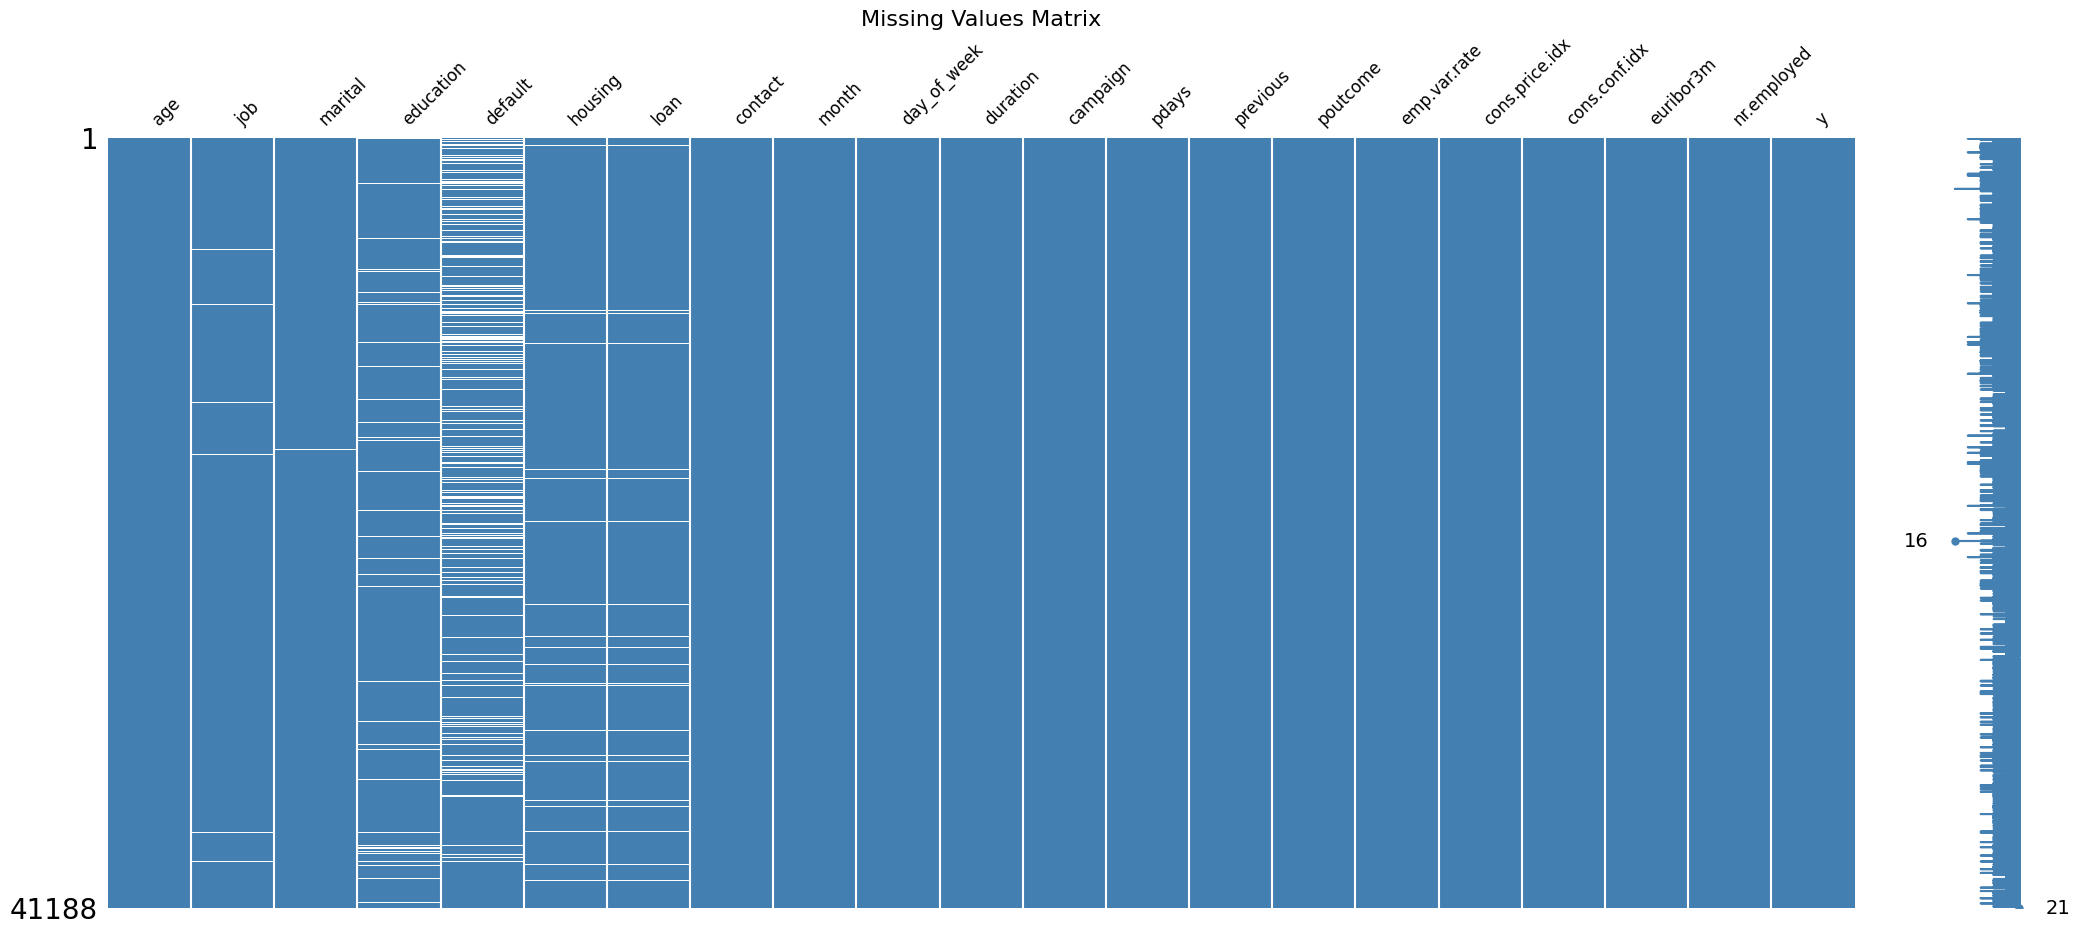

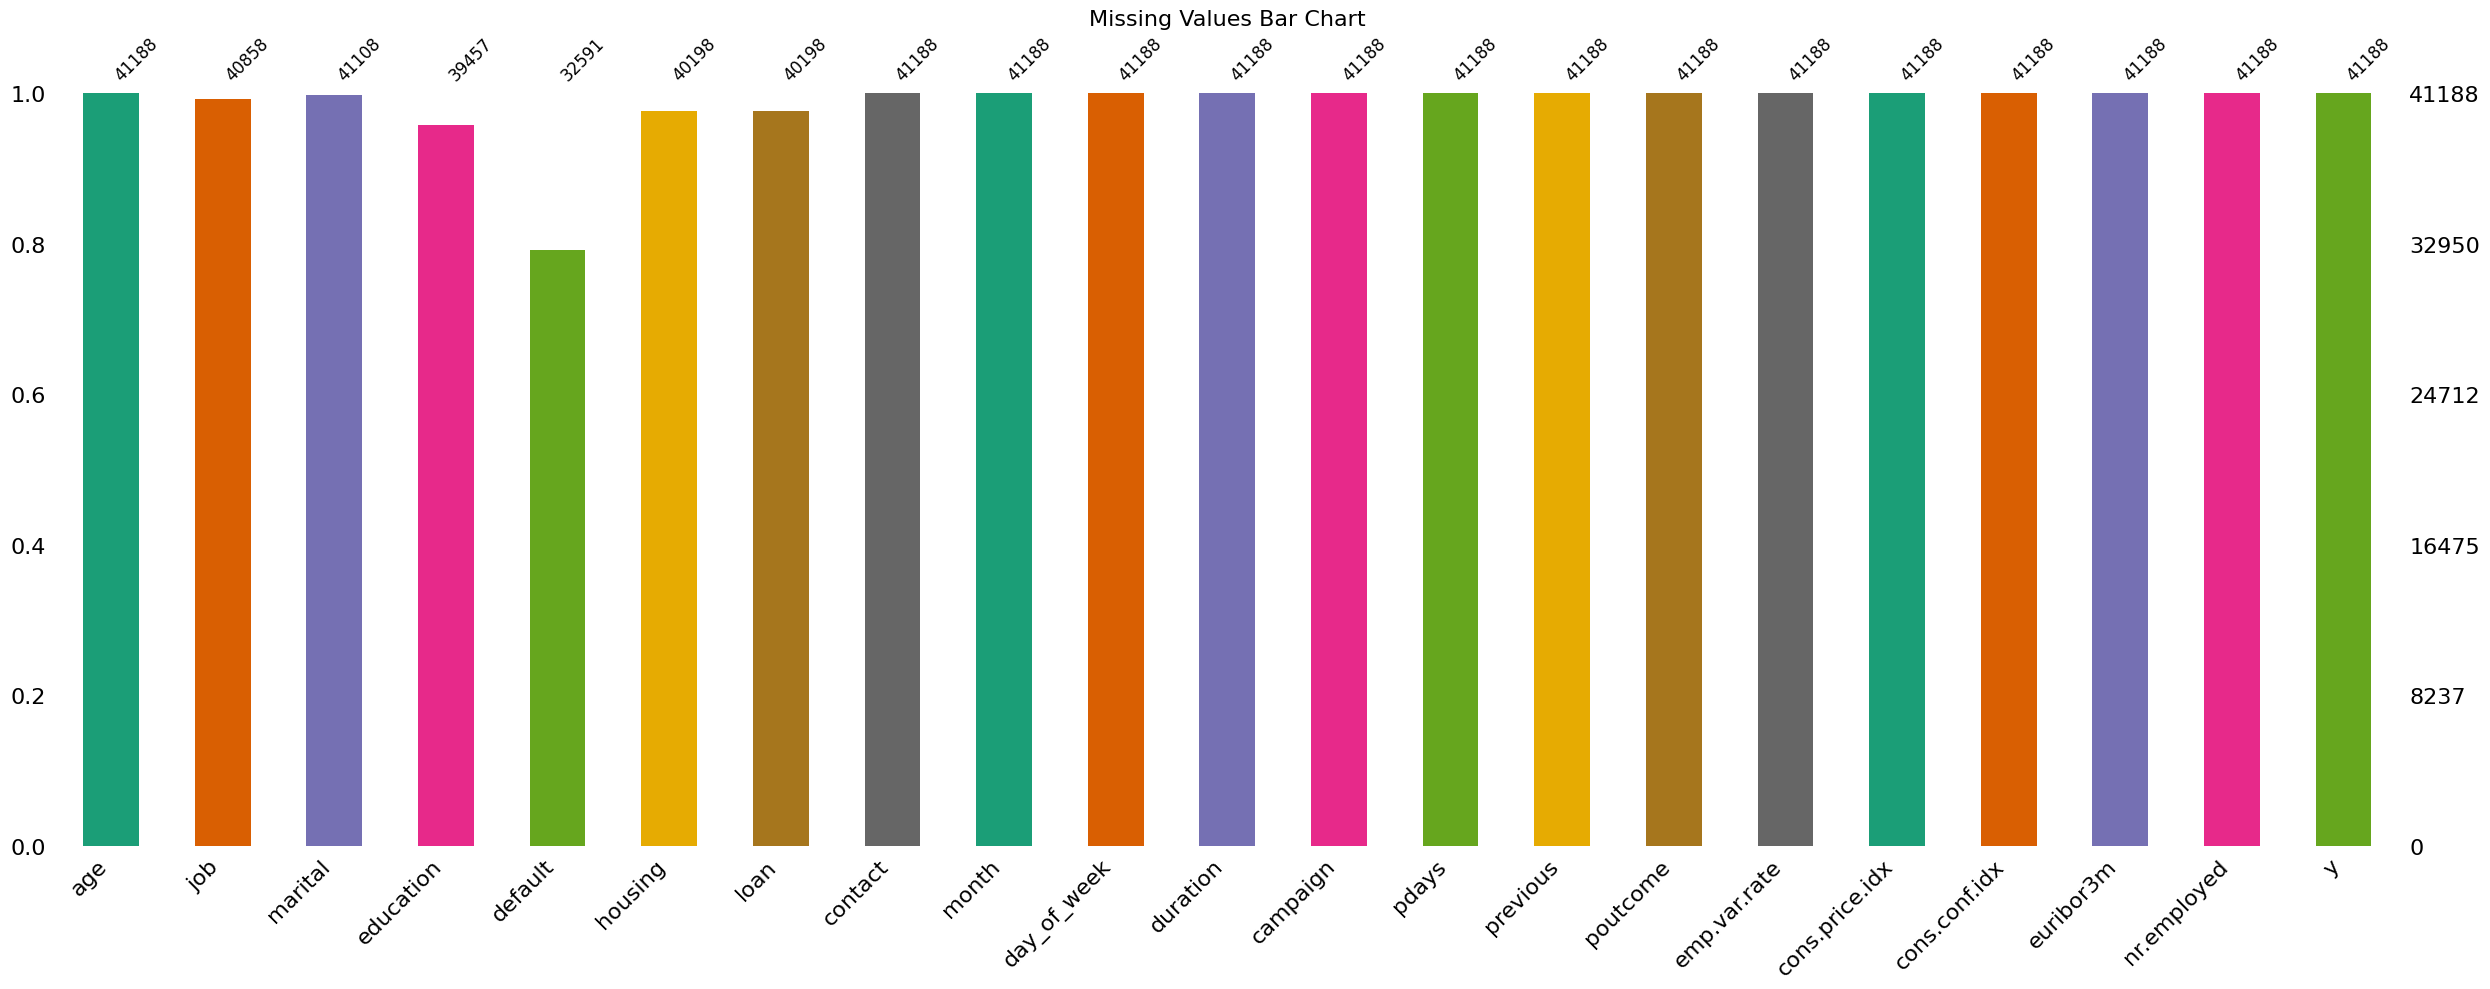

In [15]:
missing_inf_values(data)
print(f"\nNumber of duplicate rows: {data.duplicated().sum()}\n")
duplicates = data[data.duplicated()]
duplicates
show_missing(data)

In [16]:
cat_cols = data.select_dtypes(include="object").columns
for col in cat_cols:
    if data[col].isna().sum() > 0:
        data[col].fillna(data[col].mode()[0], inplace=True)
print(f"\nNumber of duplicate rows: {data.duplicated().sum()}\n")
duplicates = data[data.duplicated()]


Number of duplicate rows: 14



In [17]:
data = data.drop_duplicates()

In [18]:
missing_inf_values(data)

Missing Values Summary:
No missing values found.

Infinite Values Summary:
No infinite values found.


In [19]:
inf_counts = np.isinf(data.select_dtypes(include=[np.number])).sum().sum()
print(f"Total Inf values: {inf_counts}")

Total Inf values: 0


There are missing values in key columns: default (21%) and education (4%). Other columns have minimal missing data. No infinite values were found. There are 12 duplicate rows that need to be removed.

In [20]:
data.dtypes.value_counts()

object     11
int64       5
float64     5
Name: count, dtype: int64

In [21]:
columns_info("Dataset Overview", data)


======== Dataset Overview: ===========

Index Col Index  Attribute                      Data Type       Range                          Distinct Count
----- ---------- ------------------------------ --------------- ------------------------------ ---------------
1     15         emp.var.rate                   float64         -3.4 - 1.4                     10
2     16         cons.price.idx                 float64         92.201 - 94.767                26
3     17         cons.conf.idx                  float64         -50.8 - -26.9                  26
4     18         euribor3m                      float64         0.634 - 5.045                  316
5     19         nr.employed                    float64         4963.6 - 5228.1                11
6     0          age                            int64           17 - 98                        78
7     10         duration                       int64           0 - 4918                       1544
8     11         campaign                       i

In [22]:
analyze_data(data)





















=== Numerical Analysis ===
|    | Variable       |     N |      Mean |       SD |     SE |   95% Conf. |   Interval |
|---:|:---------------|------:|----------:|---------:|-------:|------------:|-----------:|
|  0 | age            | 41174 |   40.0236 |  10.4206 | 0.0514 |     39.9229 |    40.1242 |
|  1 | duration       | 41174 |  258.324  | 259.309  | 1.2779 |    255.819  |   260.828  |
|  2 | campaign       | 41174 |    2.568  |   2.7704 | 0.0137 |      2.5412 |     2.5947 |
|  3 | pdays          | 41174 |  962.463  | 186.941  | 0.9213 |    960.657  |   964.269  |
|  4 | previous       | 41174 |    0.173  |   0.495  | 0.0024 |      0.1682 |     0.1778 |
|  5 | emp.var.rate   | 41174 |    0.0819 |   1.5709 | 0.0077 |      0.0667 |     0.097  |
|  6 | cons.price.idx | 41174 |   93.5757 |   0.5788 | 0.0029 |     93.5701 |    93.5813 |
|  7 | cons.conf.idx  | 41174 |  -40.5031 |   4.6279 | 0.0228 |    -40.5478 |   -40.4584 |
|  8 | euribor3m      | 41174 |    3.6212 |

In [23]:
data_cat_missing_summary, data_cat_non_missing_summary = comp_cat_analysis(
    data, missing_df=True
)
data_num_missing_summary, data_num_non_missing_summary = comp_num_analysis(
    data, missing_df=True
)
data_outlier_summary, data_non_outlier_summary = comp_num_analysis(
    data, outlier_df=True
)
print(data_cat_missing_summary.shape)
print(data_num_missing_summary.shape)
print(data_outlier_summary.shape)

(0, 9)
(0, 31)
(6, 31)


In [24]:
data_cat_missing_summary

,Index,Column,DataType,Count,Missing_Percentage,Unique_Count,Mode,Mode Frequency,Mode %


In [25]:
data_num_missing_summary

,Index,Column,DataType,Count,Missing_Percentage,Unique_Count,Min,Q1,50% (Median),Q3,Max,Mode,Range,IQR,Lower Bound,Upper Bound,Total Distinct,Outliers Distinct,Outliers Count,Outliers %,Negative Count,Negative Distinct,Negative %,Mean,Variance,Std,Skewness,Kurtosis,Normality Test,Normality Statistic,Normality p-value


In [26]:
data_cat_non_missing_summary

,Index,Column,DataType,Count,Missing_Percentage,Unique_Count,Mode,Mode Frequency,Mode %
6,7,contact,object,41174,0.0,2,cellular,26134,63.472094
8,9,day_of_week,object,41174,0.0,5,thu,8617,20.928256
3,4,default,object,41174,0.0,2,no,41171,99.992714
2,3,education,object,41174,0.0,7,university.degree,13893,33.742167
4,5,housing,object,41174,0.0,2,yes,22560,54.791859
0,1,job,object,41174,0.0,11,admin.,10748,26.103852
5,6,loan,object,41174,0.0,2,no,34926,84.825375
1,2,marital,object,41174,0.0,3,married,24999,60.715500
7,8,month,object,41174,0.0,10,may,13766,33.433720
9,14,poutcome,object,41174,0.0,3,nonexistent,35549,86.338466


In [27]:
data_num_non_missing_summary

,Index,Column,DataType,Count,Missing_Percentage,Unique_Count,Min,Q1,50% (Median),Q3,Max,Mode,Range,IQR,Lower Bound,Upper Bound,Total Distinct,Outliers Distinct,Outliers Count,Outliers %,Negative Count,Negative Distinct,Negative %,Mean,Variance,Std,Skewness,Kurtosis,Normality Test,Normality Statistic,Normality p-value
0,0,age,int64,41174,0.0,78,17.000,32.000,38.000,47.000,98.000,31.000,81.000,15.000,9.5000,69.5000,78,25,468,1.136640,0,0,0.000000,40.023583,108.588446,10.420578,0.784575,0.791130,Kolmogorov-Smirnov,0.094435,5.032553e-320
1,10,duration,int64,41174,0.0,1544,0.000,102.000,180.000,319.000,4918.000,85.000,4918.000,217.000,-223.5000,644.5000,1544,899,2963,7.196289,0,0,0.000000,258.323627,67241.187348,259.309058,3.262629,20.240554,Kolmogorov-Smirnov,0.169505,0.000000e+00
2,11,campaign,int64,41174,0.0,42,1.000,1.000,2.000,3.000,56.000,1.000,55.000,2.000,-2.0000,6.0000,42,36,2406,5.843493,0,0,0.000000,2.567956,7.674917,2.770364,4.761792,36.965996,Kolmogorov-Smirnov,0.285706,0.000000e+00
3,12,pdays,int64,41174,0.0,27,0.000,999.000,999.000,999.000,999.000,999.000,999.000,0.000,999.0000,999.0000,27,26,1515,3.679506,0,0,0.000000,962.463035,34947.112652,186.941469,-4.921073,22.217391,Kolmogorov-Smirnov,0.540683,0.000000e+00
4,13,previous,int64,41174,0.0,8,0.000,0.000,0.000,0.000,7.000,0.000,7.000,0.000,0.0000,0.0000,8,7,5625,13.661534,0,0,0.000000,0.173022,0.245000,0.494975,3.831148,20.098468,Kolmogorov-Smirnov,0.500049,0.000000e+00
5,15,emp.var.rate,float64,41174,0.0,10,-3.400,-1.800,1.100,1.400,1.400,1.400,4.800,3.200,-6.6000,6.2000,10,0,0,0.000000,17186,8,41.739933,0.081865,2.467725,1.570899,-0.723959,-1.062824,Kolmogorov-Smirnov,0.324148,0.000000e+00
6,16,cons.price.idx,float64,41174,0.0,26,92.201,93.075,93.749,93.994,94.767,93.994,2.566,0.919,91.6965,95.3725,26,0,0,0.000000,0,0,0.000000,93.575713,0.335066,0.578849,-0.230817,-0.829959,Kolmogorov-Smirnov,0.214032,0.000000e+00
7,17,cons.conf.idx,float64,41174,0.0,26,-50.800,-42.700,-41.800,-36.400,-26.900,-36.400,23.900,6.300,-52.1500,-26.9500,26,1,446,1.083208,41174,26,100.000000,-40.503070,21.417248,4.627877,0.302972,-0.359091,Kolmogorov-Smirnov,0.190261,0.000000e+00
8,18,euribor3m,float64,41174,0.0,316,0.634,1.344,4.857,4.961,5.045,4.857,4.411,3.617,-4.0815,10.3865,316,0,0,0.000000,0,0,0.000000,3.621231,3.008337,1.734456,-0.709092,-1.406875,Kolmogorov-Smirnov,0.345472,0.000000e+00
9,19,nr.employed,float64,41174,0.0,11,4963.600,5099.100,5191.000,5228.100,5228.100,5228.100,264.500,129.000,4905.6000,5421.6000,11,0,0,0.000000,0,0,0.000000,5167.032805,5220.408652,72.252395,-1.044215,-0.003843,Kolmogorov-Smirnov,0.301974,0.000000e+00


In [28]:
data_non_outlier_summary

,Index,Column,DataType,Count,Missing_Percentage,Unique_Count,Min,Q1,50% (Median),Q3,Max,Mode,Range,IQR,Lower Bound,Upper Bound,Total Distinct,Outliers Distinct,Outliers Count,Outliers %,Negative Count,Negative Distinct,Negative %,Mean,Variance,Std,Skewness,Kurtosis,Normality Test,Normality Statistic,Normality p-value
5,15,emp.var.rate,float64,41174,0.0,10,-3.400,-1.800,1.100,1.400,1.400,1.400,4.800,3.200,-6.6000,6.2000,10,0,0,0.0,17186,8,41.739933,0.081865,2.467725,1.570899,-0.723959,-1.062824,Kolmogorov-Smirnov,0.324148,0.0
6,16,cons.price.idx,float64,41174,0.0,26,92.201,93.075,93.749,93.994,94.767,93.994,2.566,0.919,91.6965,95.3725,26,0,0,0.0,0,0,0.000000,93.575713,0.335066,0.578849,-0.230817,-0.829959,Kolmogorov-Smirnov,0.214032,0.0
8,18,euribor3m,float64,41174,0.0,316,0.634,1.344,4.857,4.961,5.045,4.857,4.411,3.617,-4.0815,10.3865,316,0,0,0.0,0,0,0.000000,3.621231,3.008337,1.734456,-0.709092,-1.406875,Kolmogorov-Smirnov,0.345472,0.0
9,19,nr.employed,float64,41174,0.0,11,4963.600,5099.100,5191.000,5228.100,5228.100,5228.100,264.500,129.000,4905.6000,5421.6000,11,0,0,0.0,0,0,0.000000,5167.032805,5220.408652,72.252395,-1.044215,-0.003843,Kolmogorov-Smirnov,0.301974,0.0


In [29]:
data_outlier_summary

,Index,Column,DataType,Count,Missing_Percentage,Unique_Count,Min,Q1,50% (Median),Q3,Max,Mode,Range,IQR,Lower Bound,Upper Bound,Total Distinct,Outliers Distinct,Outliers Count,Outliers %,Negative Count,Negative Distinct,Negative %,Mean,Variance,Std,Skewness,Kurtosis,Normality Test,Normality Statistic,Normality p-value
0,0,age,int64,41174,0.0,78,17.0,32.0,38.0,47.0,98.0,31.0,81.0,15.0,9.50,69.50,78,25,468,1.136640,0,0,0.0,40.023583,108.588446,10.420578,0.784575,0.791130,Kolmogorov-Smirnov,0.094435,5.032553e-320
3,12,pdays,int64,41174,0.0,27,0.0,999.0,999.0,999.0,999.0,999.0,999.0,0.0,999.00,999.00,27,26,1515,3.679506,0,0,0.0,962.463035,34947.112652,186.941469,-4.921073,22.217391,Kolmogorov-Smirnov,0.540683,0.000000e+00
2,11,campaign,int64,41174,0.0,42,1.0,1.0,2.0,3.0,56.0,1.0,55.0,2.0,-2.00,6.00,42,36,2406,5.843493,0,0,0.0,2.567956,7.674917,2.770364,4.761792,36.965996,Kolmogorov-Smirnov,0.285706,0.000000e+00
1,10,duration,int64,41174,0.0,1544,0.0,102.0,180.0,319.0,4918.0,85.0,4918.0,217.0,-223.50,644.50,1544,899,2963,7.196289,0,0,0.0,258.323627,67241.187348,259.309058,3.262629,20.240554,Kolmogorov-Smirnov,0.169505,0.000000e+00
4,13,previous,int64,41174,0.0,8,0.0,0.0,0.0,0.0,7.0,0.0,7.0,0.0,0.00,0.00,8,7,5625,13.661534,0,0,0.0,0.173022,0.245000,0.494975,3.831148,20.098468,Kolmogorov-Smirnov,0.500049,0.000000e+00
7,17,cons.conf.idx,float64,41174,0.0,26,-50.8,-42.7,-41.8,-36.4,-26.9,-36.4,23.9,6.3,-52.15,-26.95,26,1,446,1.083208,41174,26,100.0,-40.503070,21.417248,4.627877,0.302972,-0.359091,Kolmogorov-Smirnov,0.190261,0.000000e+00


In [30]:
data_negative_values = data.select_dtypes(include=[np.number]).lt(0).sum()
data_negative_values = data_negative_values[data_negative_values > 0].sort_values(
    ascending=False
)
print("Columns with Negative Values (Sorted):\n", data_negative_values)

Columns with Negative Values (Sorted):
 cons.conf.idx    41174
emp.var.rate     17186
dtype: int64


In [31]:
data_normal_df, data_not_normal_df = normality_test_with_skew_kurt(data)


Normal Columns (p > 0.05):


,Column,Test,Statistic,p_value,Skewness,Kurtosis



Not Normal Columns (p ≤ 0.05) - Sorted from Near Normal to Not Normal:


,Column,Test,Statistic,p_value,Skewness,Kurtosis
0,age,Kolmogorov-Smirnov,0.094435,5.032553e-320,0.784575,0.791130
1,duration,Kolmogorov-Smirnov,0.169505,0.000000e+00,3.262629,20.240554
2,campaign,Kolmogorov-Smirnov,0.285706,0.000000e+00,4.761792,36.965996
3,pdays,Kolmogorov-Smirnov,0.540683,0.000000e+00,-4.921073,22.217391
4,previous,Kolmogorov-Smirnov,0.500049,0.000000e+00,3.831148,20.098468
5,emp.var.rate,Kolmogorov-Smirnov,0.324148,0.000000e+00,-0.723959,-1.062824
6,cons.price.idx,Kolmogorov-Smirnov,0.214032,0.000000e+00,-0.230817,-0.829959
7,cons.conf.idx,Kolmogorov-Smirnov,0.190261,0.000000e+00,0.302972,-0.359091
8,euribor3m,Kolmogorov-Smirnov,0.345472,0.000000e+00,-0.709092,-1.406875
9,nr.employed,Kolmogorov-Smirnov,0.301974,0.000000e+00,-1.044215,-0.003843


several columns contain outliers. For example, age has 469 outliers (1.14%), while pdays, campaign, duration, and previous have more significant outliers. The distribution of most columns is skewed, with duration and campaign showing strong positive skew. pdays has a high concentration of 999 values, indicating a lot of unchanged data. Overall, the data is non-normal, and transformations may be necessary for certain models.


Variables Exhibiting Multicollinearity (|Correlation| > 0.80):
- emp.var.rate & euribor3m: Correlation=0.9399
- emp.var.rate & nr.employed: Correlation=0.9447
- euribor3m & nr.employed: Correlation=0.9289


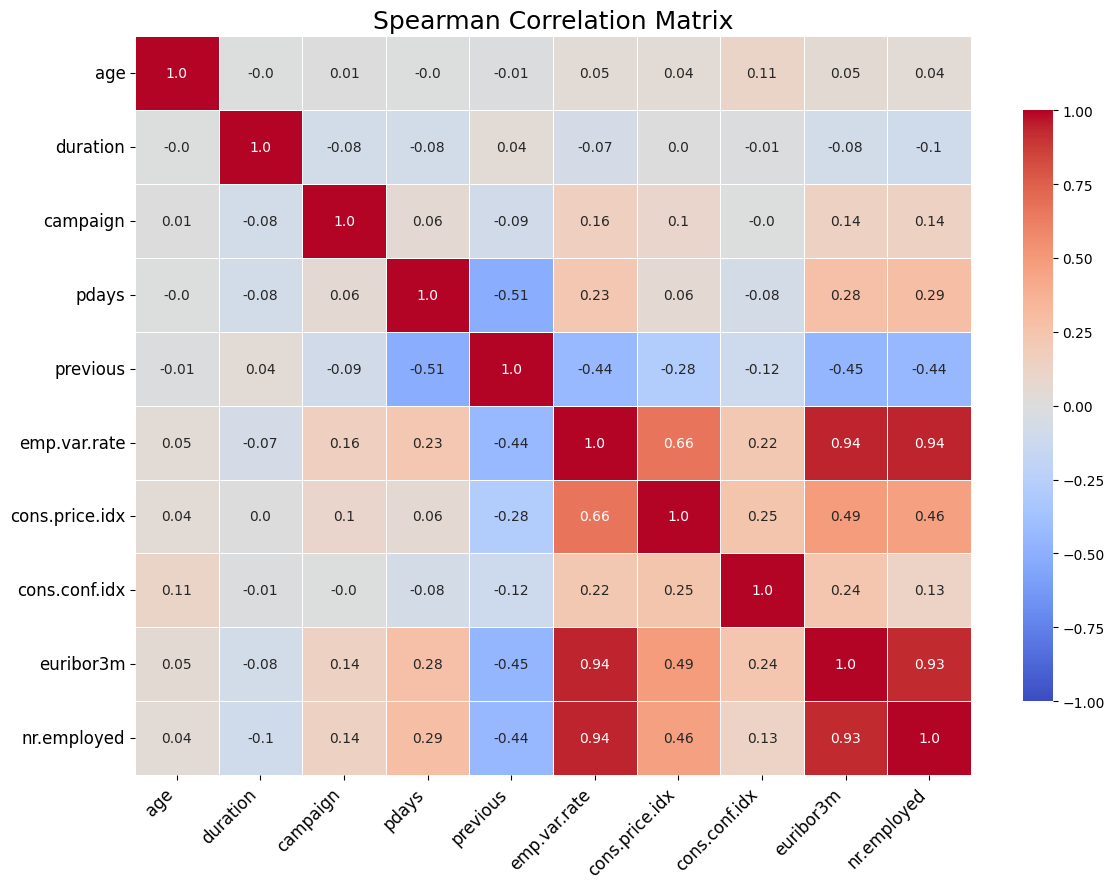

In [32]:
spearman_correlation(
    data, data_not_normal_df, exclude_target="y", multicollinearity_threshold=0.8
)

In [33]:
at_above_threshold, at_below_threshold = calculate_vif(
    data, exclude_target="y", multicollinearity_threshold=8.0
)


Variance Inflation Factor (VIF) Scores (multicollinearity_threshold = 8.0):

Features with VIF > threshold (High Multicollinearity):
       Feature          VIF
   nr.employed 26744.075510
cons.price.idx 22558.526669
     euribor3m   226.217188
 cons.conf.idx   120.098329
         pdays    44.398360
  emp.var.rate    28.907236
           age    16.047465

Features with VIF <= threshold (Low/No Multicollinearity):
 Feature      VIF
duration 2.011120
previous 2.001613
campaign 1.921579


There is strong multicollinearity in the dataset between **emp.var.rate**, **euribor3m**, and **nr.employed**, with correlation values above 0.90. This means these variables are highly related and could cause issues in modeling

### Exploratory Data Analysis (EDA)

### Descriptive Statistics


Value counts and percentages for Y:

| Y   |   Count |   % Total |
|:----|--------:|----------:|
| no  |   36535 |     88.73 |
| yes |    4639 |     11.27 |


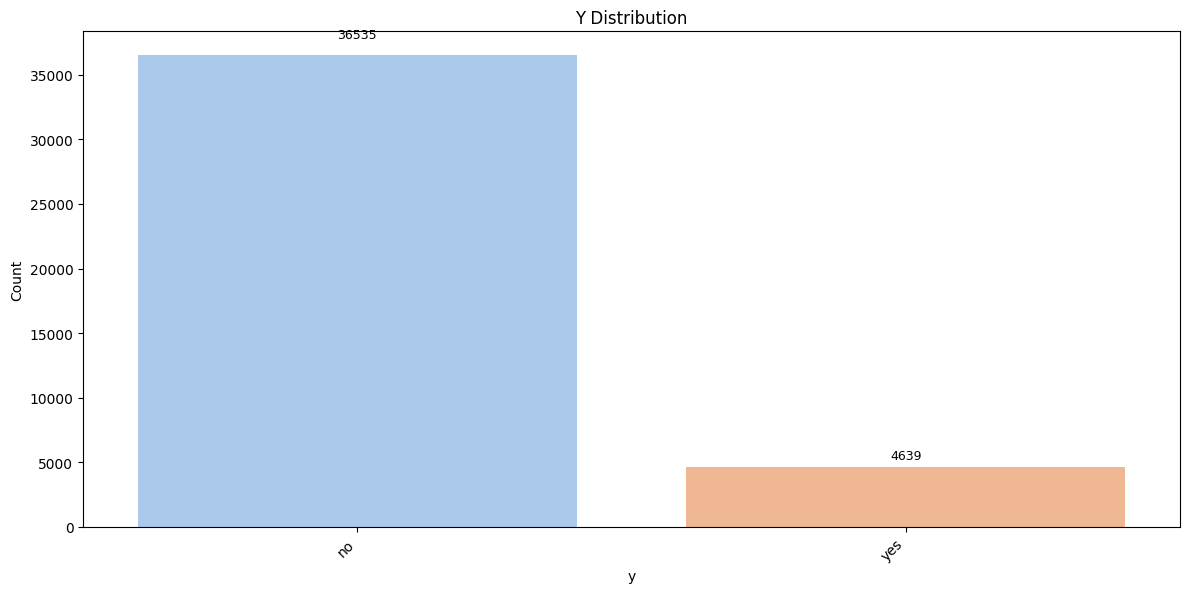

In [34]:
cat_analyze_and_plot(data, "y")

In [35]:
grouped_summary(data, groupby="y")

=== Summary Grouped by 'y' ===


Grouped by y                                                     
                                                   Missing        Overall             no            yes P-Value
n                                                                   41174          36535           4639        
age, mean (SD)                                           0    40.0 (10.4)     39.9 (9.9)    40.9 (13.8)  <0.001
job, n (%)                admin.                             10748 (26.1)    9360 (25.6)    1388 (29.9)  <0.001
                          blue-collar                         9252 (22.5)    8614 (23.6)     638 (13.8)        
                          entrepreneur                         1456 (3.5)     1332 (3.6)      124 (2.7)        
                          housemaid                            1060 (2.6)      954 (2.6)      106 (2.3)        
                          management                           2924 (7.1)     2596 (7.1)      328 (7.1)        
                          retired                              1718 (4.2)     1284 (3.5)      434 (9.4)        
                          self-employed                        1421 (3.5)     1272 (3.5)      149 (3.2)        
                          services                             3967 (9.6)    3644 (10.0)      323 (7.0)        
                          student                               875 (2.1)      600 (1.6)      275 (5.9)        
                          technician                          6739 (16.4)    6009 (16.4)     730 (15.7)        
                          unemployed                           1014 (2.5)      870 (2.4)      144 (3.1)        
marital, n (%)            divorced                            4611 (11.2)    4135 (11.3)     476 (10.3)  <0.001
                          married                            24999 (60.7)   22456 (61.5)    2543 (54.8)        
                          single                             11564 (28.1)    9944 (27.2)    1620 (34.9)        
education, n (%)          basic.4y                            4175 (10.1)    3747 (10.3)      428 (9.2)  <0.001
                          basic.6y                             2291 (5.6)     2103 (5.8)      188 (4.1)        
                          basic.9y                            6045 (14.7)    5572 (15.3)     473 (10.2)        
                          high.school                         9512 (23.1)    8481 (23.2)    1031 (22.2)        
                          illiterate                             18 (0.0)       14 (0.0)        4 (0.1)        
                          professional.course                 5240 (12.7)    4645 (12.7)     595 (12.8)        
                          university.degree                  13893 (33.7)   11973 (32.8)    1920 (41.4)        
default, n (%)            no                                41171 (100.0)  36532 (100.0)   4639 (100.0)   1.000
                          yes                                     3 (0.0)        3 (0.0)                       
housing, n (%)            no                                 18614 (45.2)   16589 (45.4)    2025 (43.7)   0.025
                          yes                                22560 (54.8)   19946 (54.6)    2614 (56.3)        
loan, n (%)               no                                 34926 (84.8)   30970 (84.8)    3956 (85.3)   0.374
                          yes                                 6248 (15.2)    5565 (15.2)     683 (14.7)        
contact, n (%)            cellular                           26134 (63.5)   22282 (61.0)    3852 (83.0)  <0.001
                          telephone                          15040 (36.5)   14253 (39.0)     787 (17.0)        
month, n (%)              apr                                  2631 (6.4)     2092 (5.7)     539 (11.6)  <0.001
                          aug                                 6175 (15.0)    5520 (15.1)     655 (14.1)        
                          dec                                   182 (0.4)       93 (0.3)       89 (1.9)        
              

1. Demographic Differences: Those who said “yes” tend to be slightly older, more likely single, and more often highly educated (e.g., have a university degree). They also show specific job patterns (higher proportions of retirees and students).

2. Contact/Timing Factors: 
   - “Cellular” contacts are much more common in the “yes” group.  
   - The duration of the last call is significantly longer among “yes” than “no.”  
   - The month of contact matters: certain months (e.g., March, October) have higher shares of “yes” than might be expected given the overall distribution.

3. Previous Interaction: “Yes” is more likely if a previous campaign outcome was “success,” and typically they had fewer days since last contact and possibly more total prior contacts overall.

4. Macroeconomic Indicators: Lower euribor3m rates, lower “emp.var.rate,” and fewer employees (nr.employed) seem to be associated with the “yes” group.

Overall, the significant p-values (< 0.001 for most) imply strong evidence that the “yes” and “no” groups differ on these features—important for modeling or understanding who might subscribe.

In [36]:
columns_info("Dataset Overview", data)


======== Dataset Overview: ===========

Index Col Index  Attribute                      Data Type       Range                          Distinct Count
----- ---------- ------------------------------ --------------- ------------------------------ ---------------
1     15         emp.var.rate                   float64         -3.4 - 1.4                     10
2     16         cons.price.idx                 float64         92.201 - 94.767                26
3     17         cons.conf.idx                  float64         -50.8 - -26.9                  26
4     18         euribor3m                      float64         0.634 - 5.045                  316
5     19         nr.employed                    float64         4963.6 - 5228.1                11
6     0          age                            int64           17 - 98                        78
7     10         duration                       int64           0 - 4918                       1544
8     11         campaign                       i

In [37]:
num_summary(data)

,Count,Unique,Mean,Std,Min,25%,50%,75%,Max,Mode,Range,IQR,Variance,Skewness,Kurtosis,Shapiro-Wilk Stat,Shapiro-Wilk p-value
age,41174.0,78.0,40.0236,10.4206,17.000,32.000,38.000,47.000,98.000,31.000,81.000,15.000,108.5884,0.7846,0.7914,0.9573,0.0
duration,41174.0,1544.0,258.3236,259.3091,0.000,102.000,180.000,319.000,4918.000,85.000,4918.000,217.000,67241.1873,3.2627,20.2432,0.7217,0.0
campaign,41174.0,42.0,2.5680,2.7704,1.000,1.000,2.000,3.000,56.000,1.000,55.000,2.000,7.6749,4.7620,36.9706,0.5579,0.0
pdays,41174.0,27.0,962.4630,186.9415,0.000,999.000,999.000,999.000,999.000,999.000,999.000,0.000,34947.1127,-4.9213,22.2202,0.1830,0.0
previous,41174.0,8.0,0.1730,0.4950,0.000,0.000,0.000,0.000,7.000,0.000,7.000,0.000,0.2450,3.8313,20.1011,0.3913,0.0
emp.var.rate,41174.0,10.0,0.0819,1.5709,-3.400,-1.800,1.100,1.400,1.400,1.400,4.800,3.200,2.4677,-0.7240,-1.0628,0.7622,0.0
cons.price.idx,41174.0,26.0,93.5757,0.5788,92.201,93.075,93.749,93.994,94.767,93.994,2.566,0.919,0.3351,-0.2308,-0.8299,0.9339,0.0
cons.conf.idx,41174.0,26.0,-40.5031,4.6279,-50.800,-42.700,-41.800,-36.400,-26.900,-36.400,23.900,6.300,21.4172,0.3030,-0.3590,0.9241,0.0
euribor3m,41174.0,316.0,3.6212,1.7345,0.634,1.344,4.857,4.961,5.045,4.857,4.411,3.617,3.0083,-0.7091,-1.4069,0.6863,0.0
nr.employed,41174.0,11.0,5167.0328,72.2524,4963.600,5099.100,5191.000,5228.100,5228.100,5228.100,264.500,129.000,5220.4087,-1.0443,-0.0037,0.7878,0.0


In [38]:
cat_summary(data)

,Count,Unique,Top,Freq,Top %
job,41174,11,admin.,10748,26.10%
marital,41174,3,married,24999,60.72%
education,41174,7,university.degree,13893,33.74%
default,41174,2,no,41171,99.99%
housing,41174,2,yes,22560,54.79%
loan,41174,2,no,34926,84.83%
contact,41174,2,cellular,26134,63.47%
month,41174,10,may,13766,33.43%
day_of_week,41174,5,thu,8617,20.93%
poutcome,41174,3,nonexistent,35549,86.34%


the duration of phone calls varies significantly, indicating a mixture of very short and exceptionally long calls. The average call duration is approximately 258 seconds, but it can extend to nearly 4918 seconds. This suggests that longer calls might be associated with successful conversions, which could be a focus area for enhancing customer engagement strategies.

In terms of campaign contact, the data reveals a skewed distribution, with most clients being contacted less than three times, but a few receiving up to 56 contacts. This pattern suggests the possibility of diminishing returns on repeated contacts, indicating a need to optimize the number of interactions per client.

The 'pdays' attribute shows a predominance of the value 999, indicating that most clients had not been contacted before this campaign. This observation suggests that the bank is frequently reaching out to new prospects or has not effectively followed up with previous contacts.

From a demographic perspective, administrative roles dominate the client job categories, representing over a quarter of the total client base. This suggests that marketing efforts could be tailored to appeal specifically to this group. Additionally, the majority of clients are married and well-educated (with university degrees), which might influence the type of products they are interested in or the marketing channels that are most effective.

overall, the low conversion rate of 11.27% for term deposit subscriptions highlights a significant challenge in the marketing strategy's effectiveness. This low rate suggests there is substantial room for improvement in campaign targeting, messaging, and possibly product offers to better meet the needs and preferences of potential clients.

### Univariate Analysis

#### num_analysis

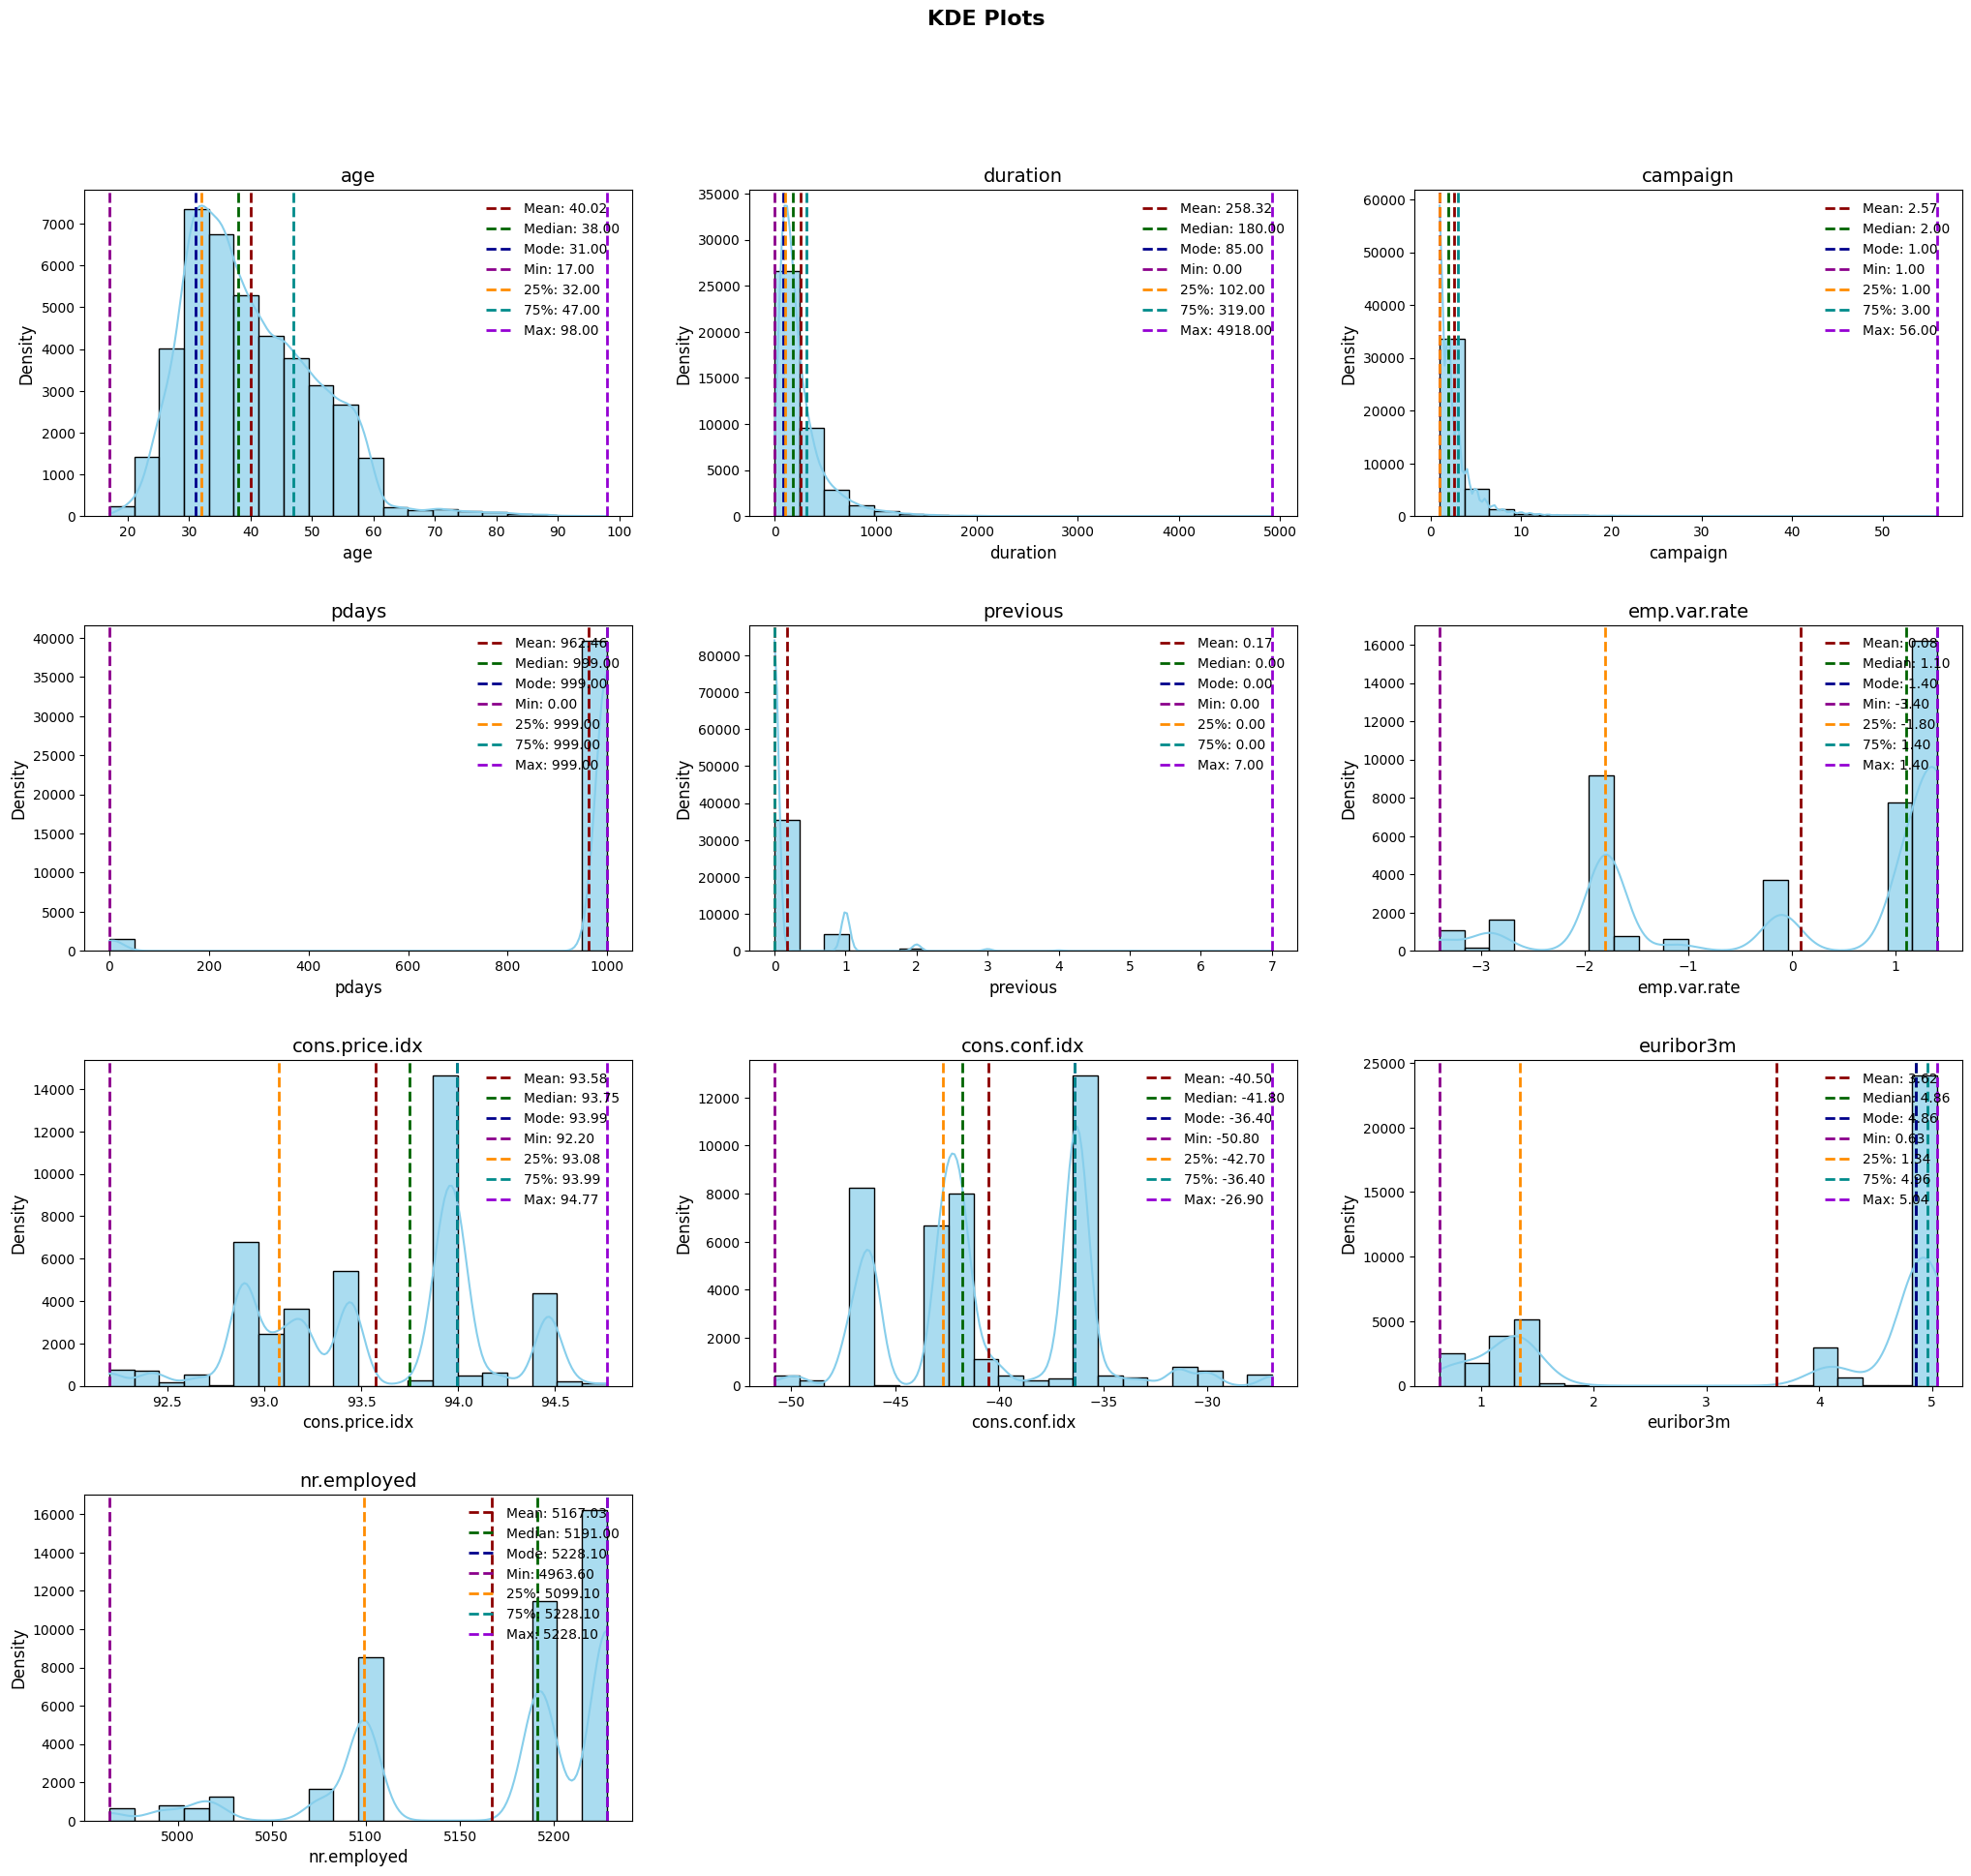

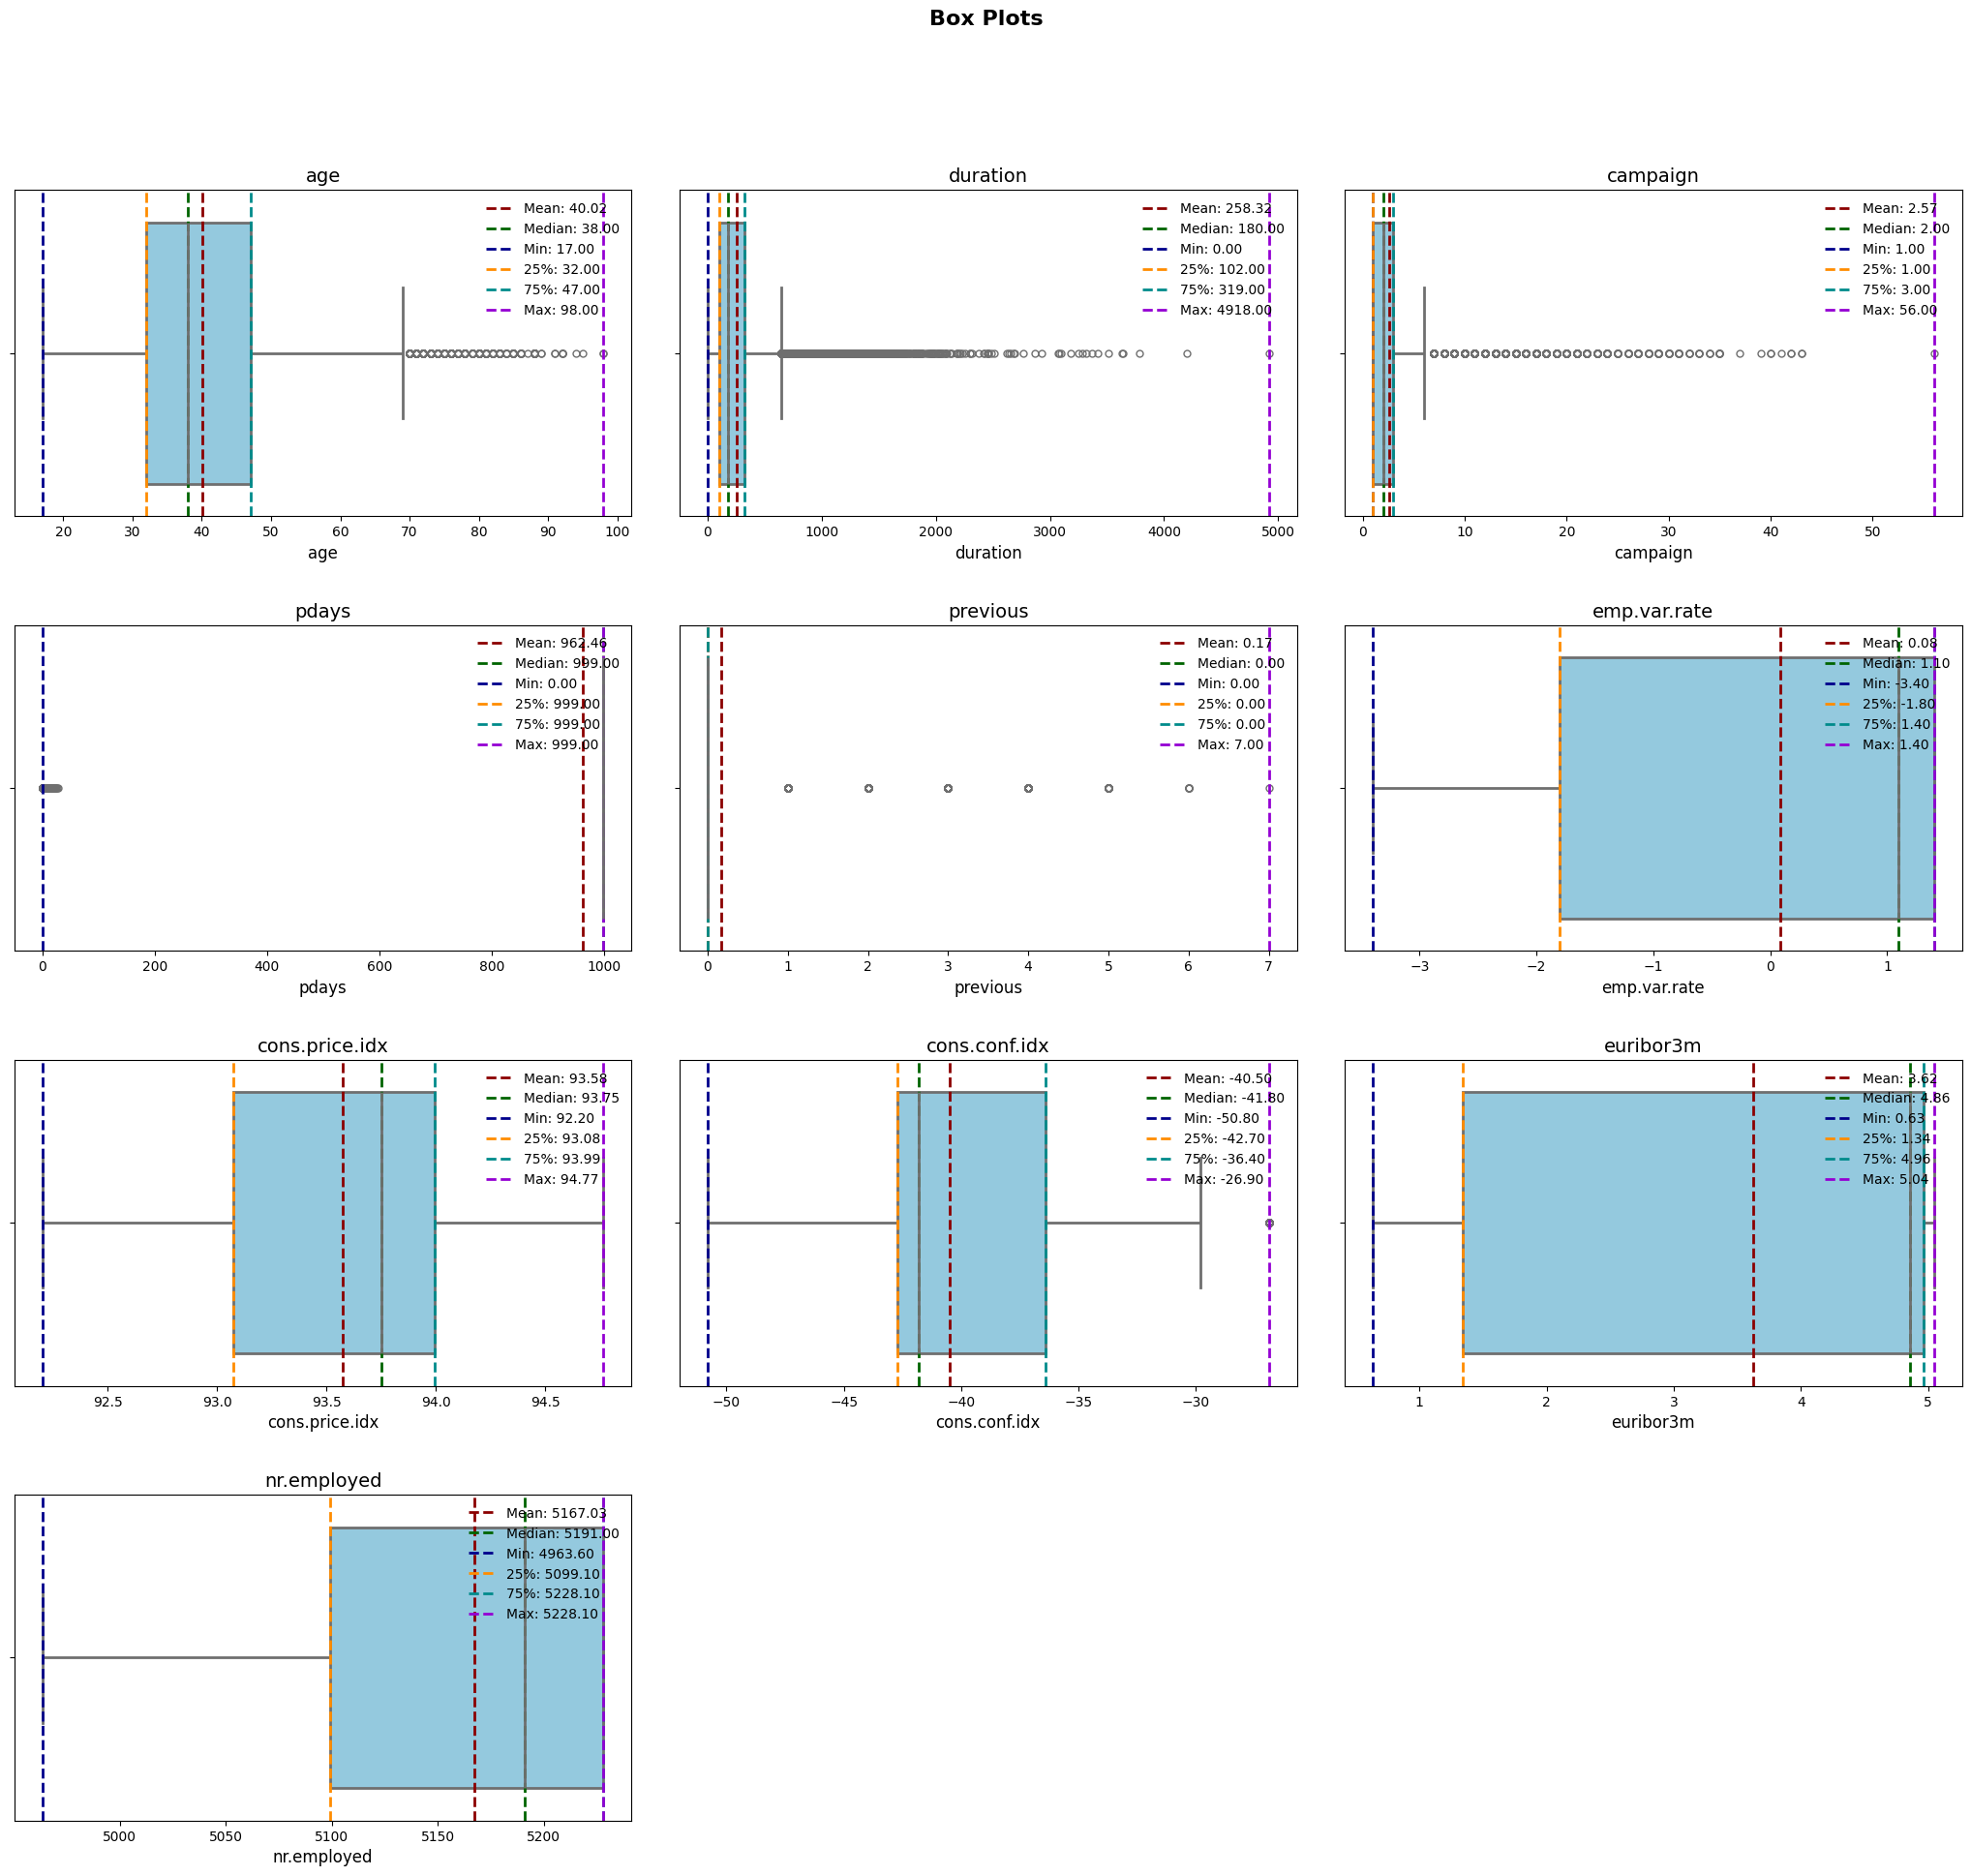

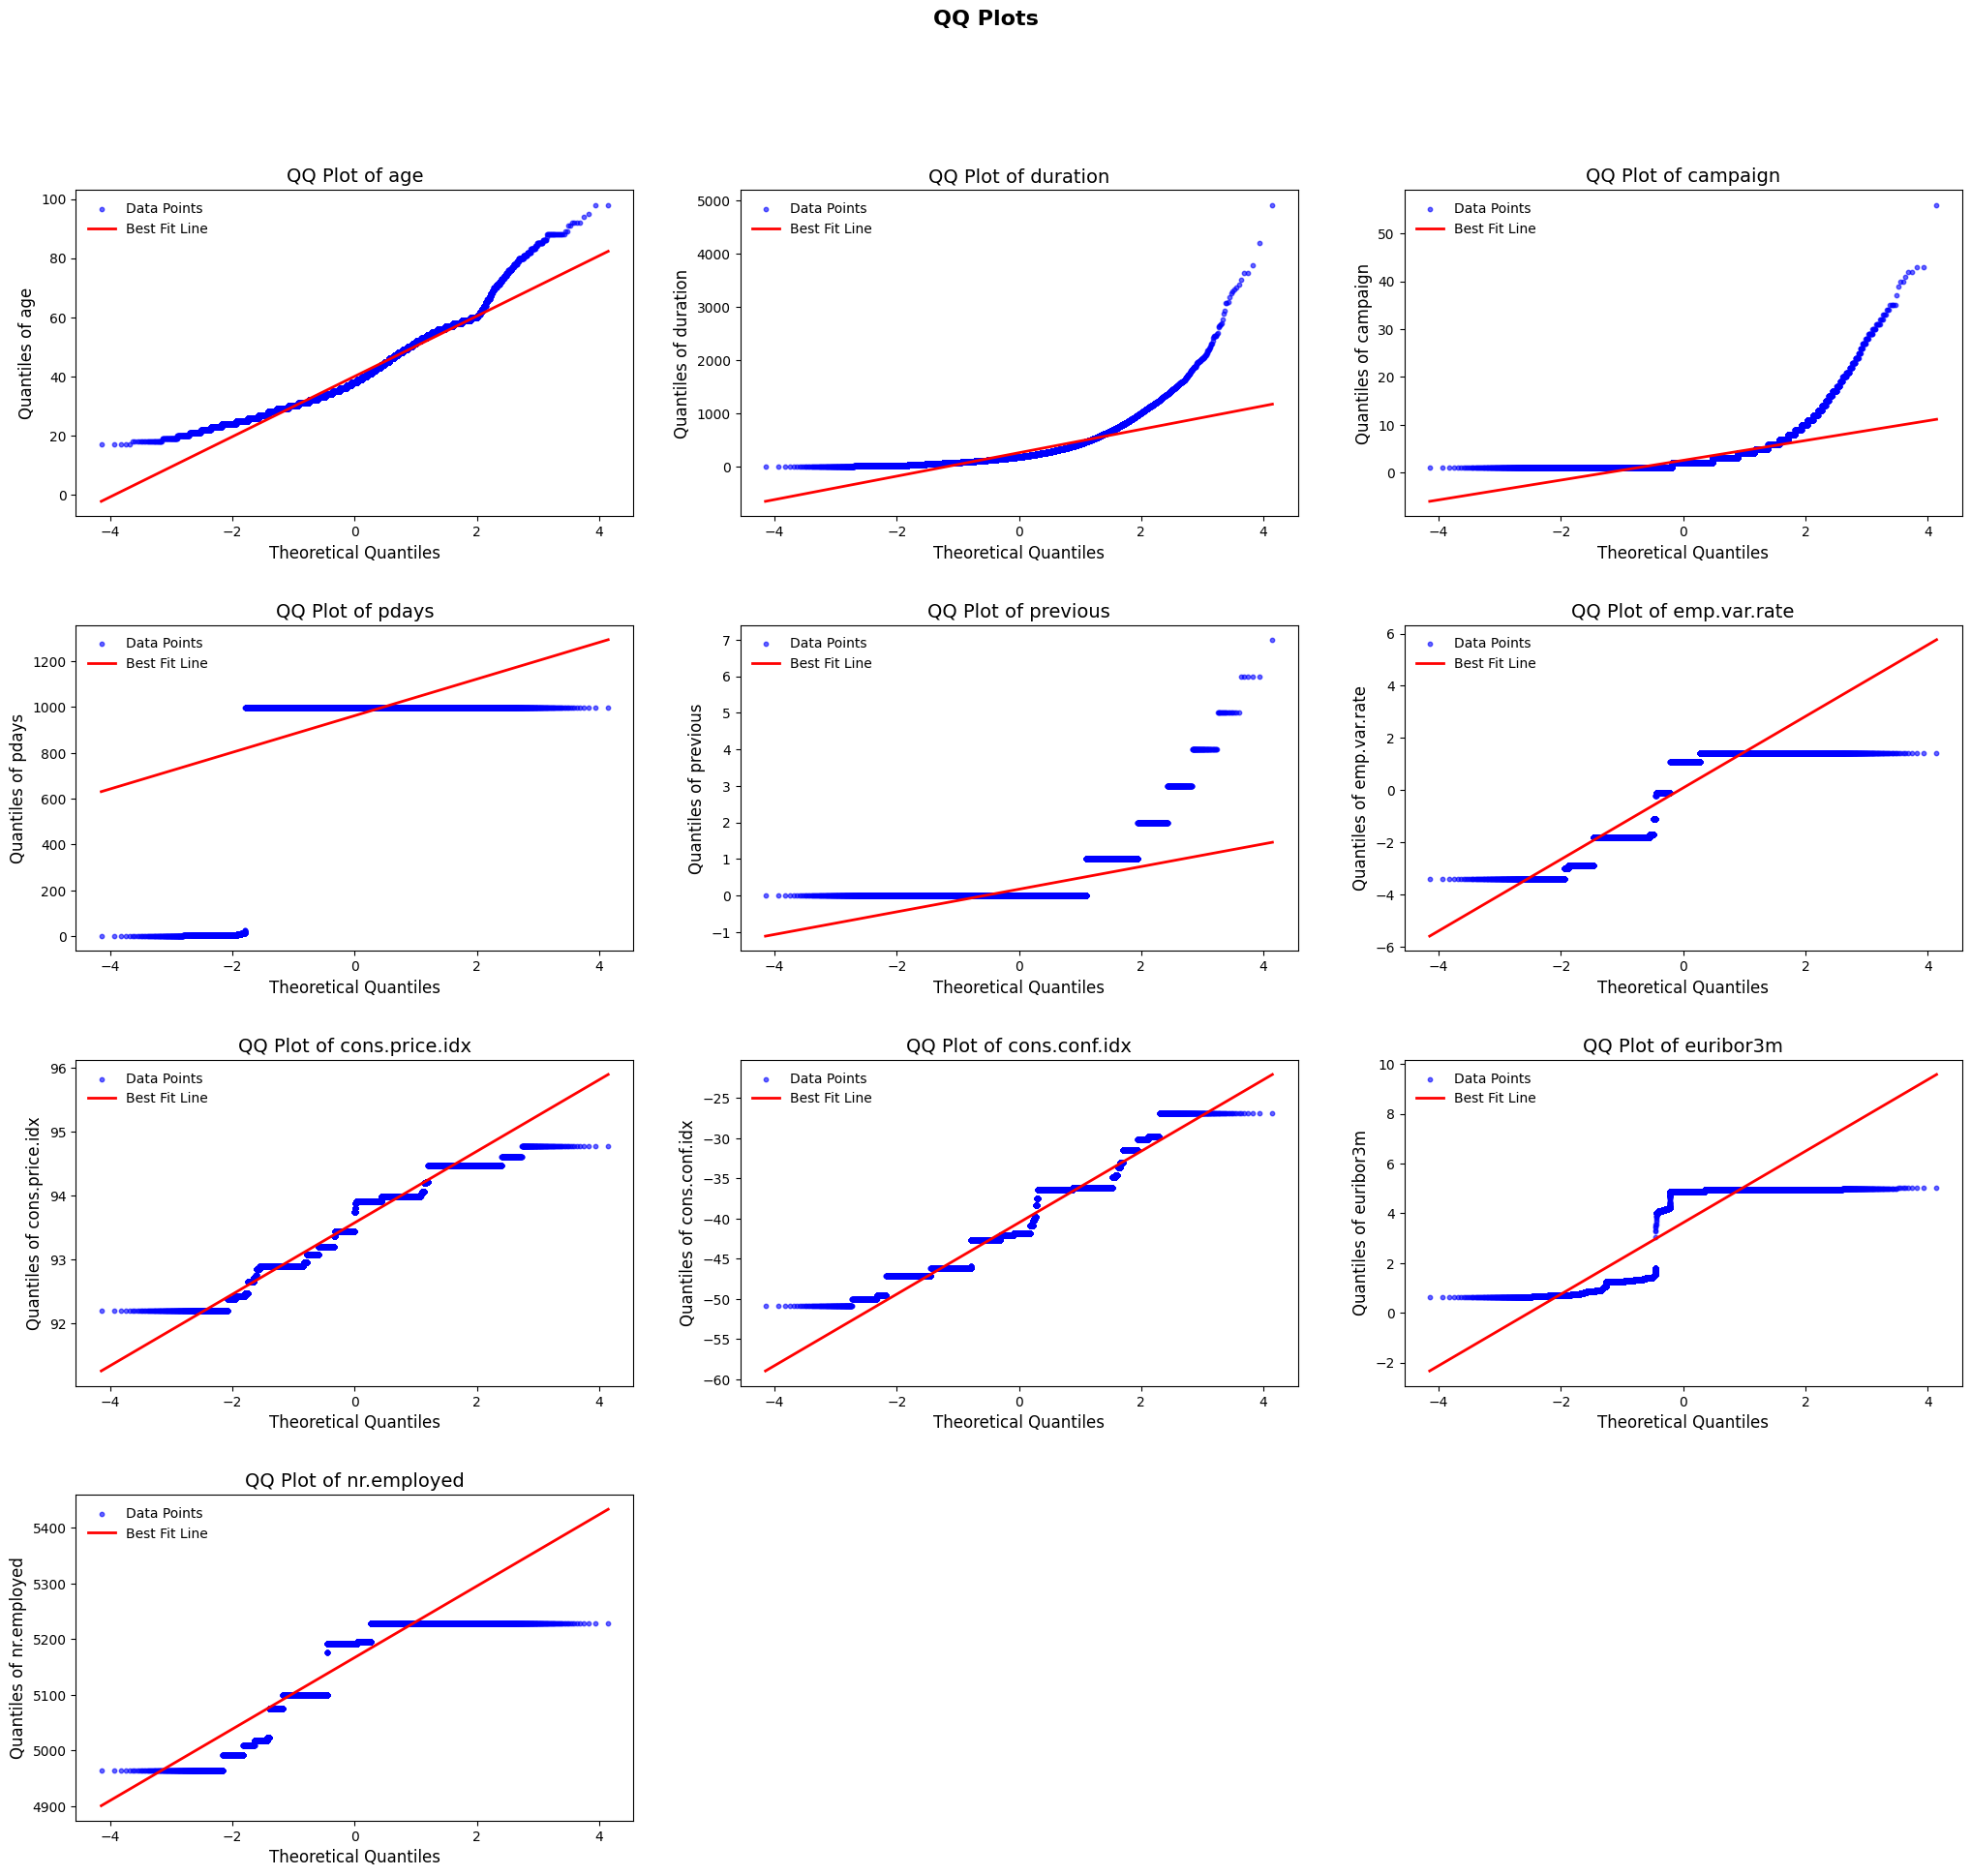

In [39]:
kde_batches(data, batch_num=1)
box_plot_batches(data, batch_num=1)
qq_plot_batches(data, batch_num=1)

Age peaks around 40 with a slight right skew and a few outliers. Duration and campaign are highly skewed, with many short contacts and some extremely long or frequent ones. Pdays and previous mostly sit at zero or 999, indicating minimal prior contact for most customers. Emp.var.rate shows wide variation, while cons.price.idx and cons.conf.idx remain relatively stable with few outliers. Euribor3m has a broad distribution featuring some extreme values, and nr.employed clusters around 5228. Overall, several features deviate from normality, confirming the presence of skewed distributions and outliers.

#### cat_analysis

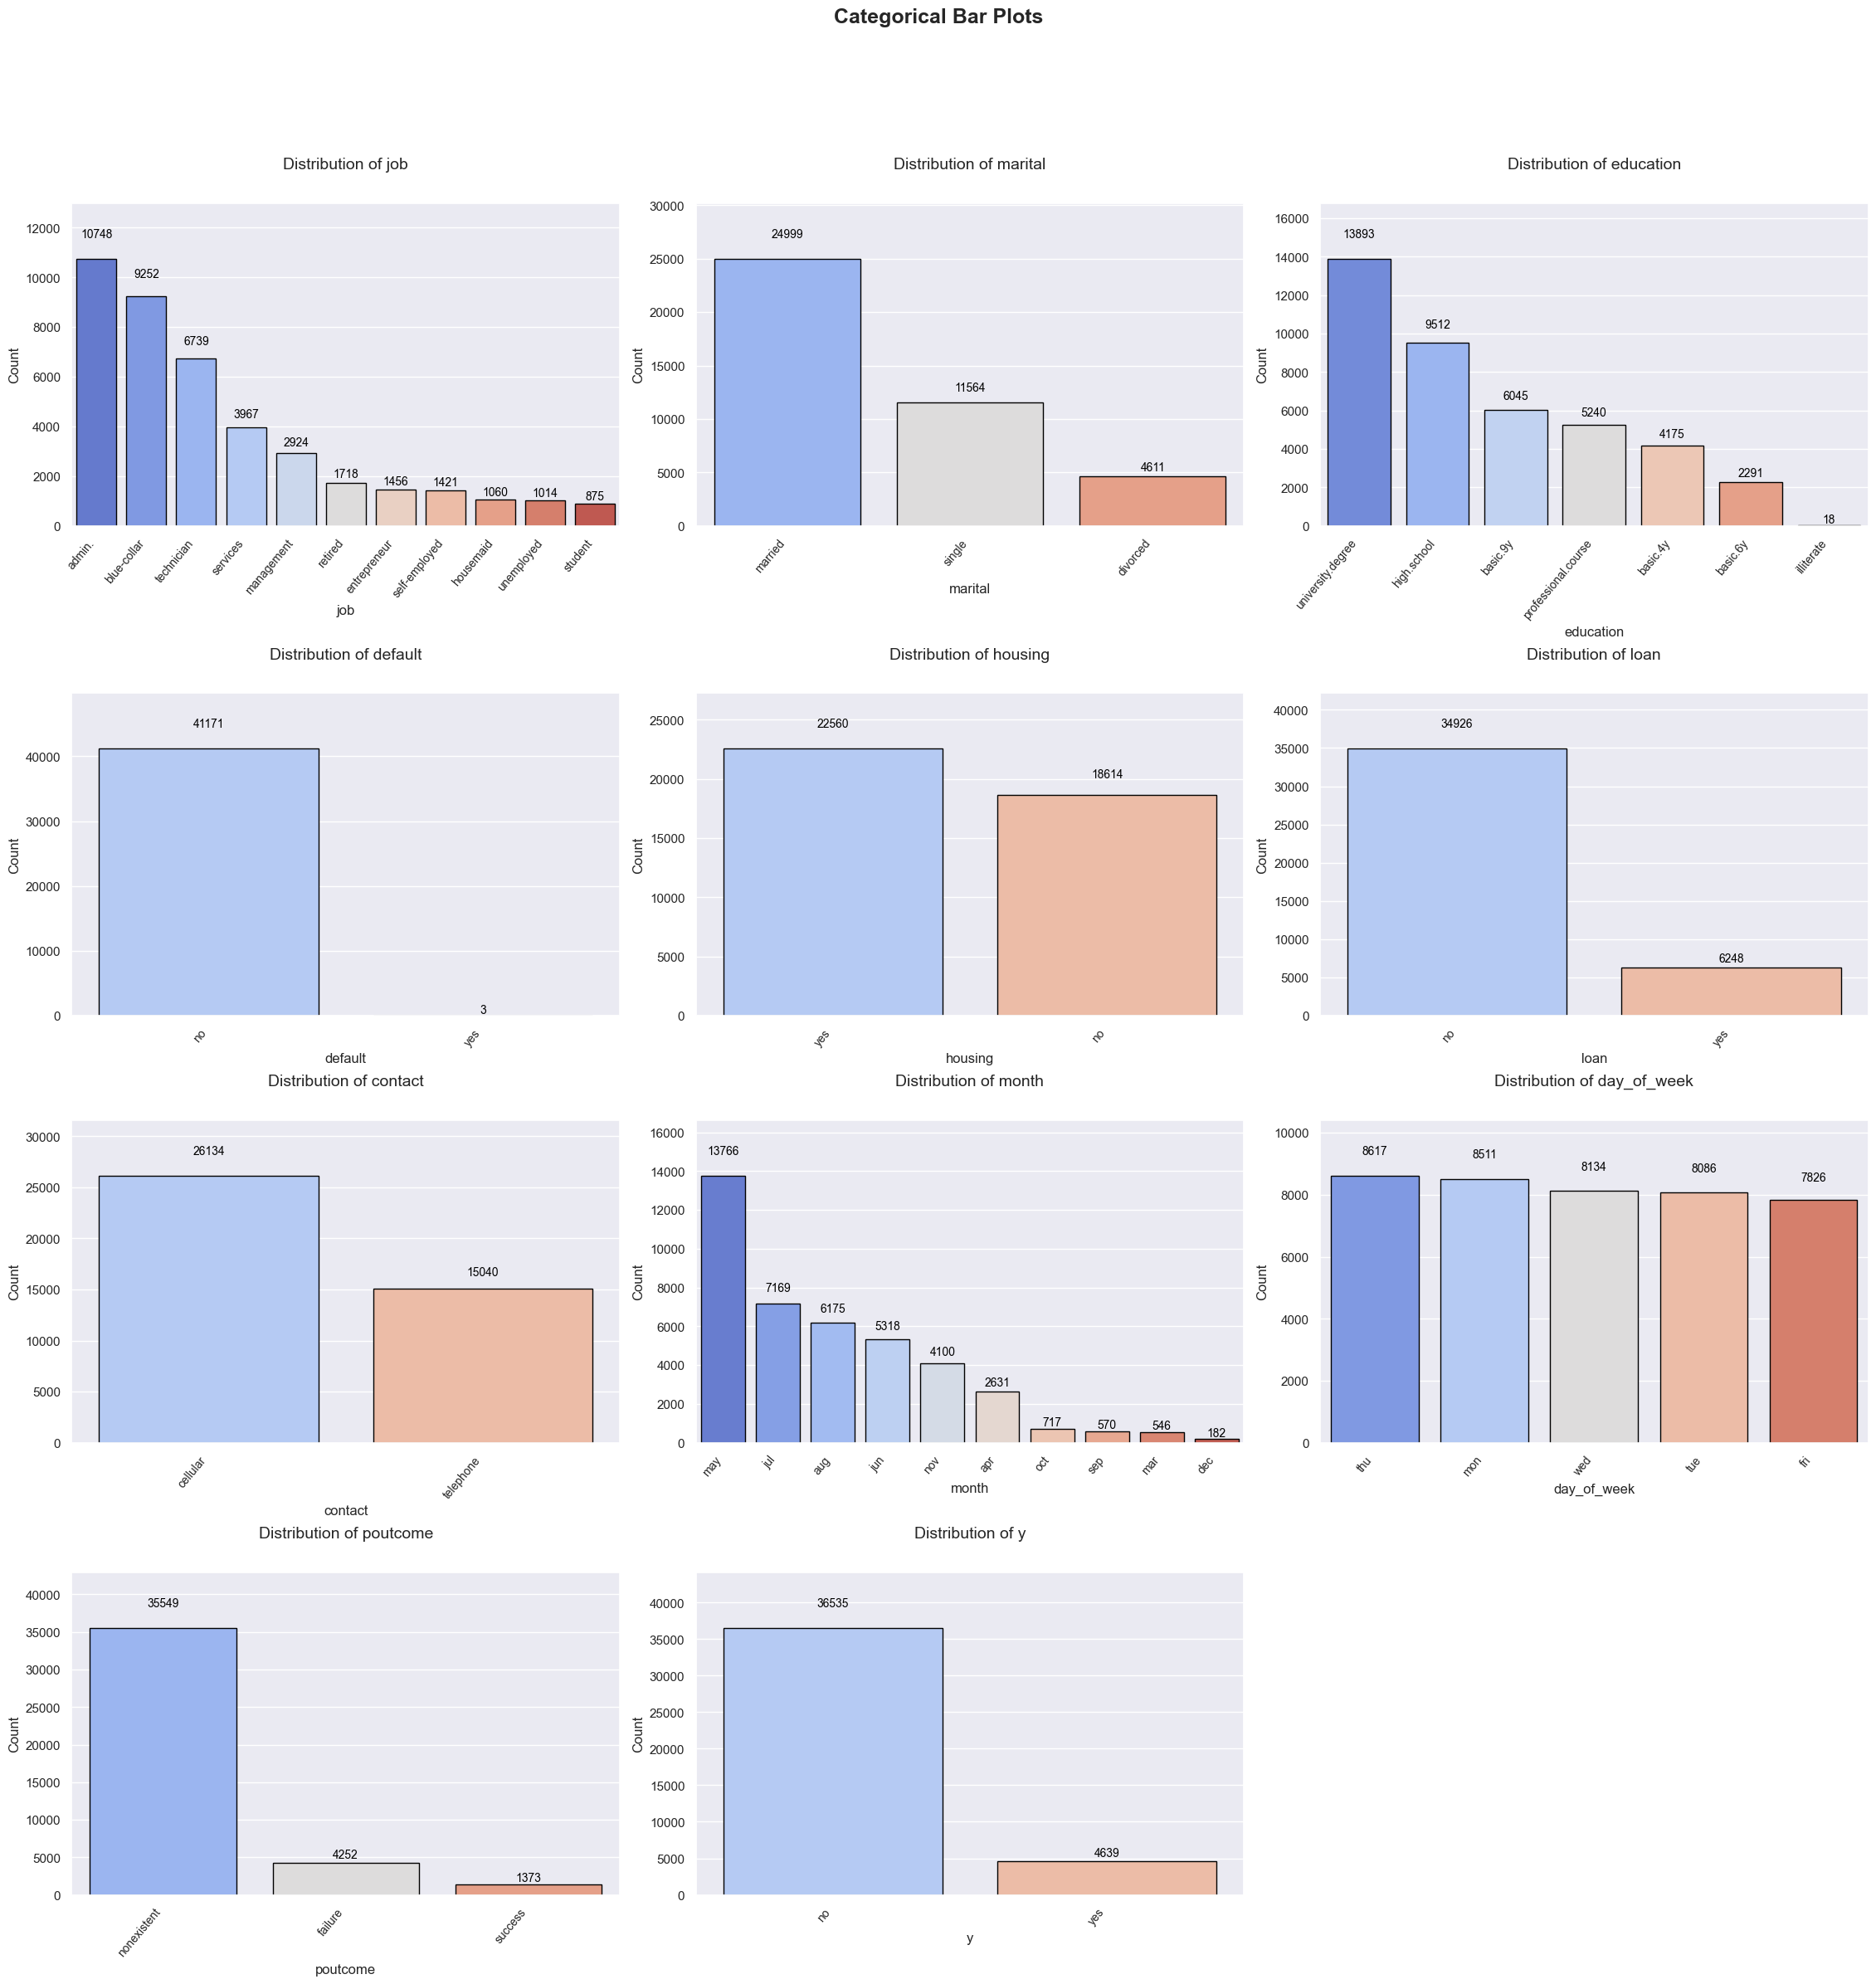

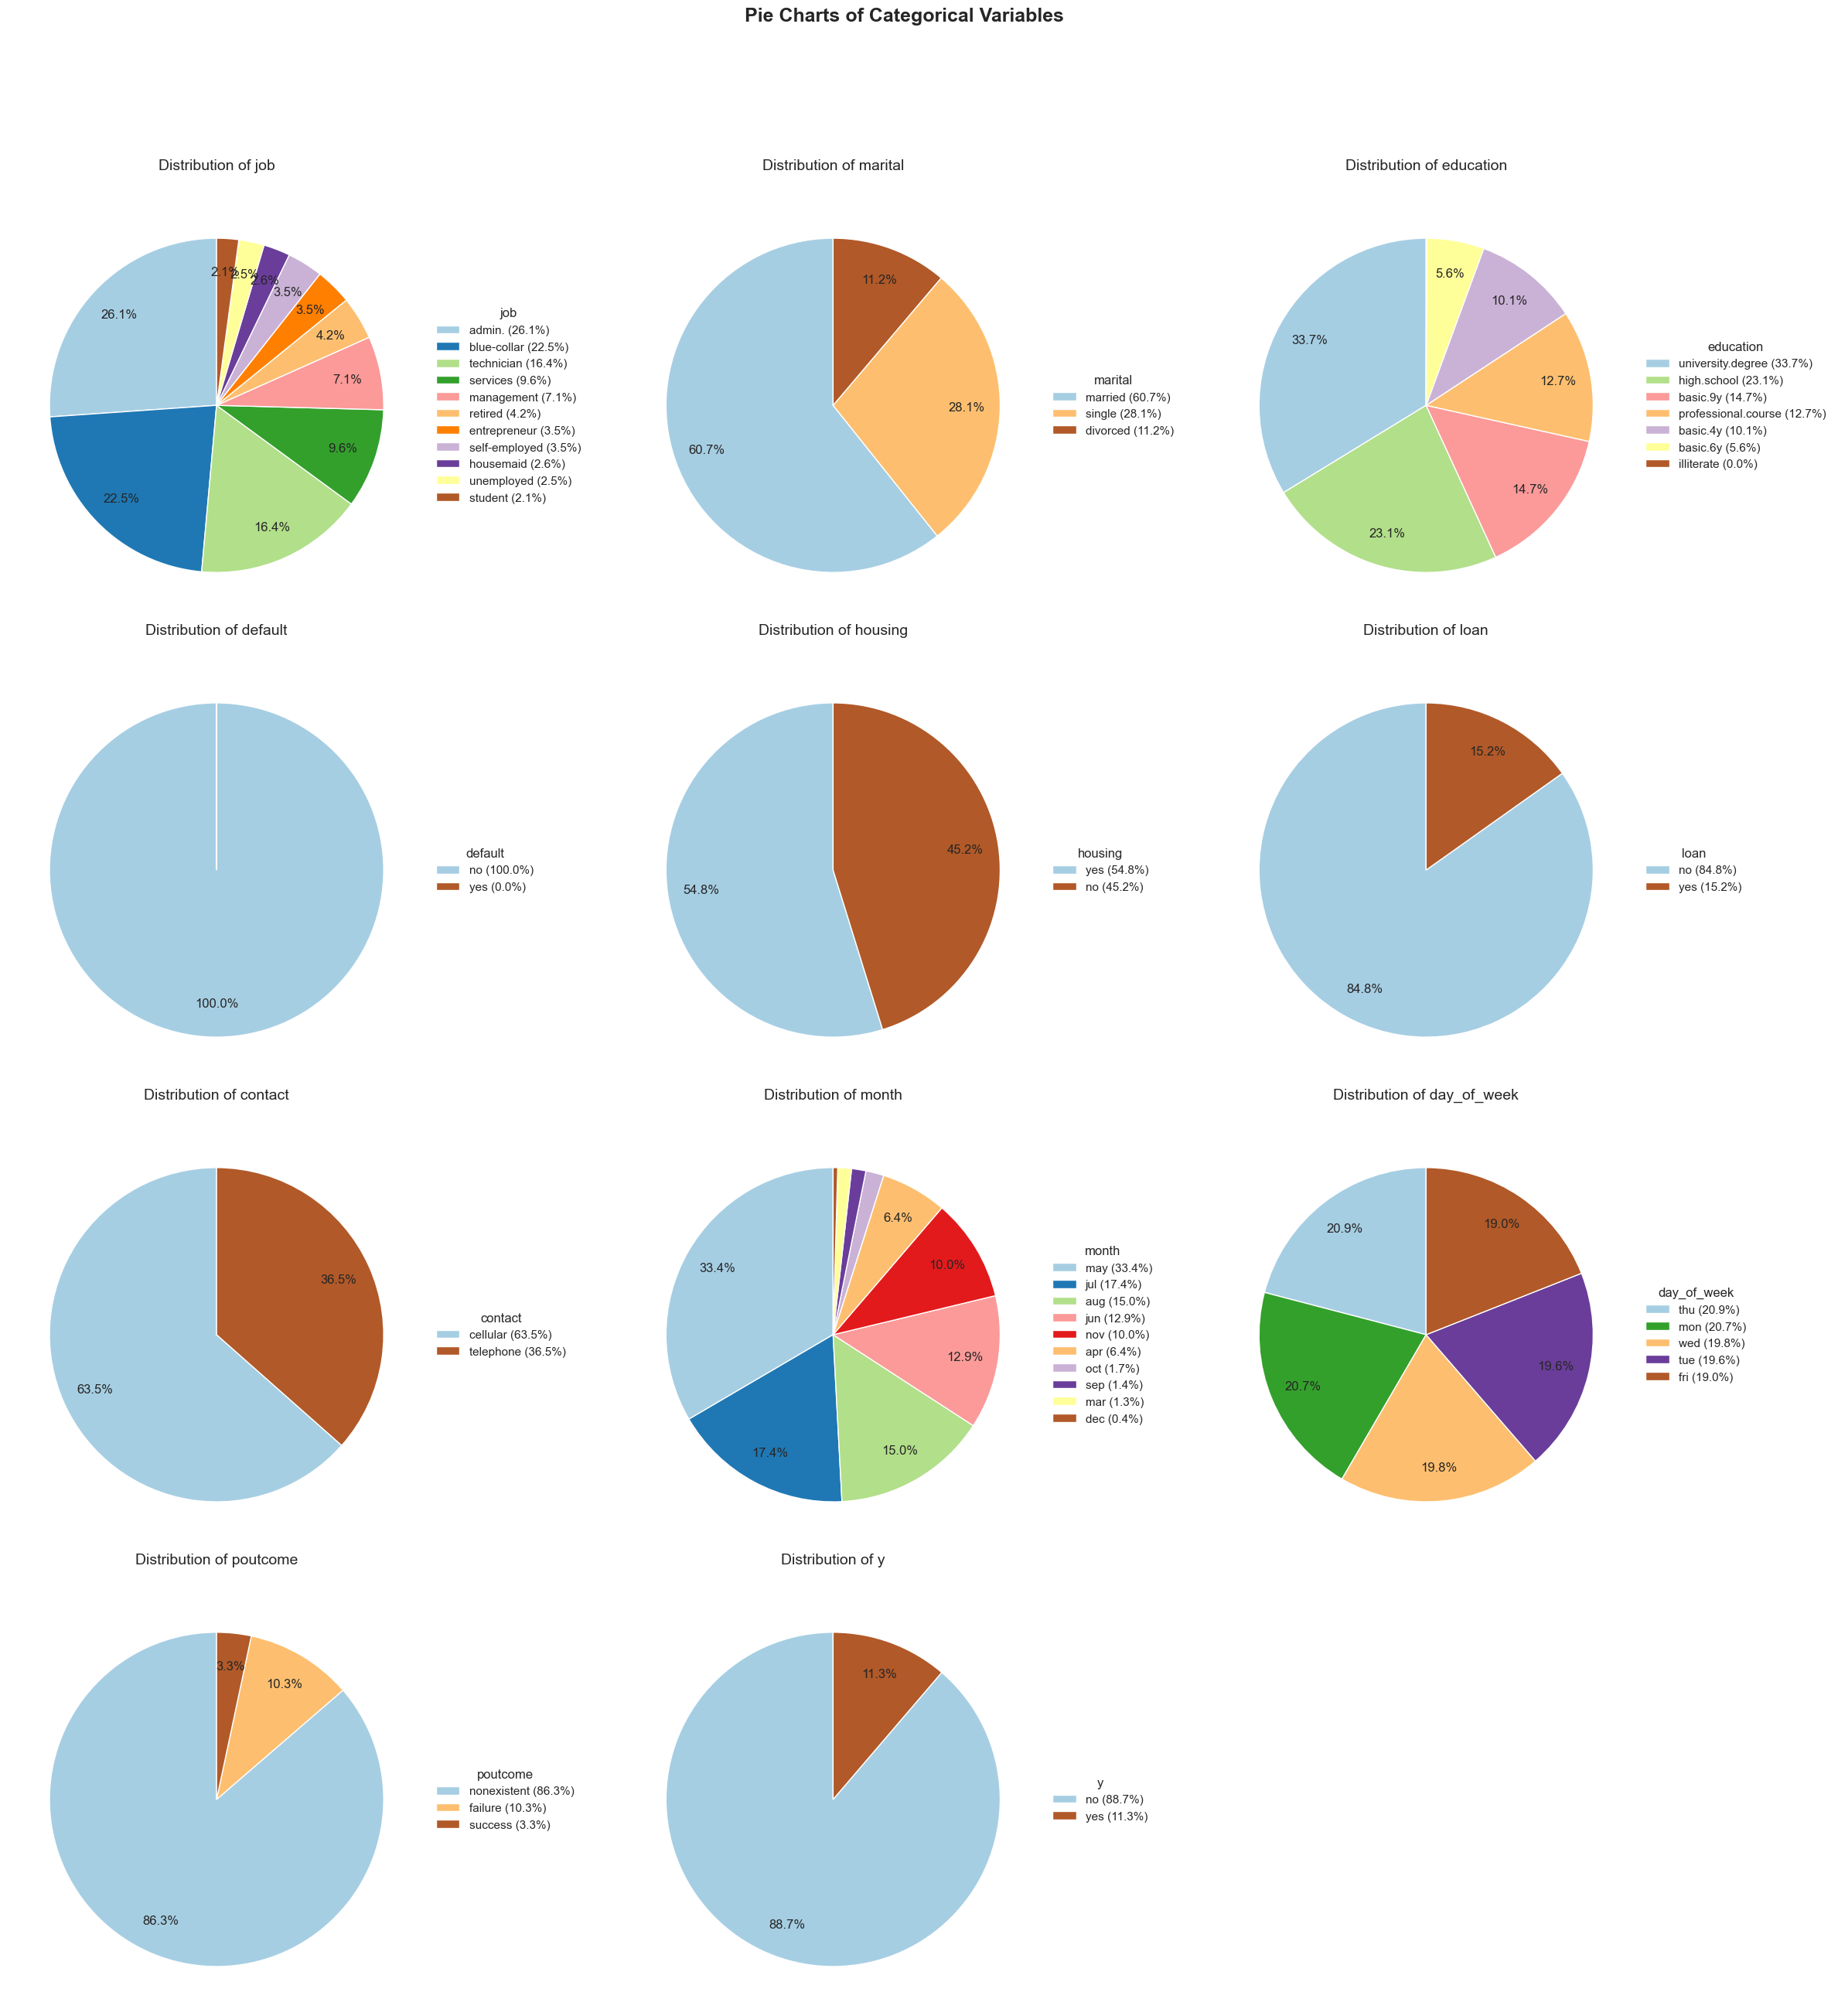

In [40]:
cat_bar_batches(data, batch_num=1)
cat_pie_chart_batches(data, batch_num=1)

Most clients are employed in administrative and blue-collar roles, suggesting that the bank could develop financial products tailored to the unique needs and challenges of these professions to enhance term deposit subscriptions. Additionally, the predominance of married clients indicates an opportunity for marketing strategies that emphasize family and long-term financial security. Educational background information reveals a high number of clients with university degrees or high school education, indicating that more sophisticated banking products could be marketed effectively to this group.

Regarding client financial status, the majority have no credit defaults, and many have housing loans, which could influence their financial decisions and risk profiles. The preference for contact via cellular phone suggests that a more personal approach might be more effective. Seasonal variations in contact frequencies, with peaks in months like May, July, and August, suggest that these periods may be optimal for marketing efforts. However, the low conversion rate of calls to actual term deposits (11.3%) highlights the need for improved targeting and offer adjustments to meet client needs and preferences more effectively. This comprehensive analysis provides a foundation for refining the bank's strategies to increase the effectiveness of their campaigns and improve customer engagement.

### Bivariate & Multivariate Analysis

- euribor3m: This variable is a daily indicator and reflects the state of the economy.

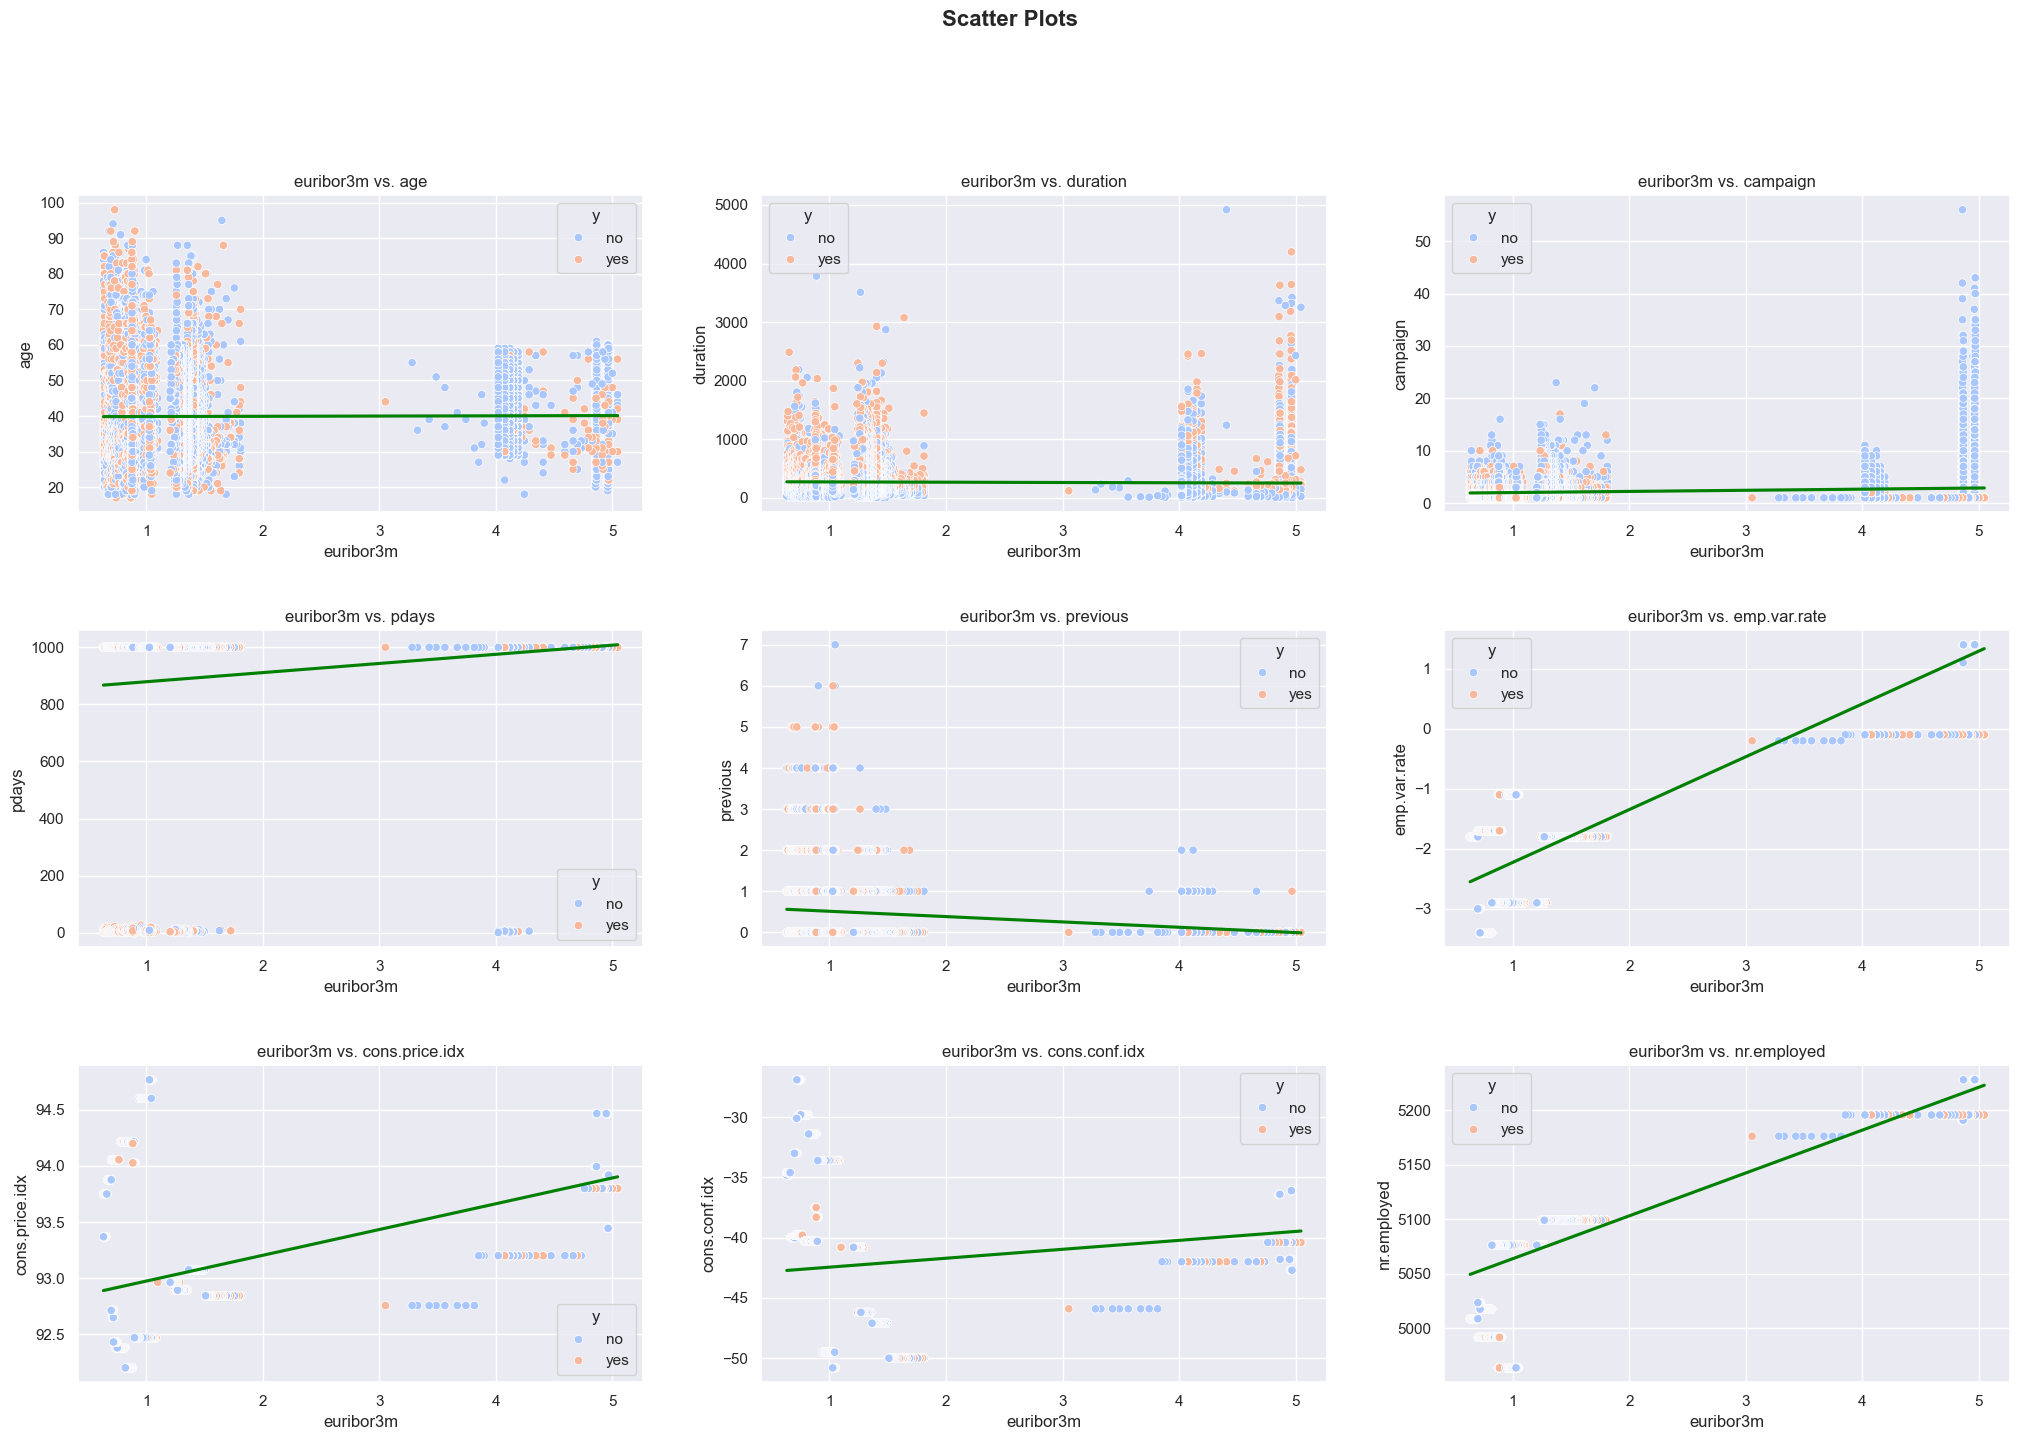

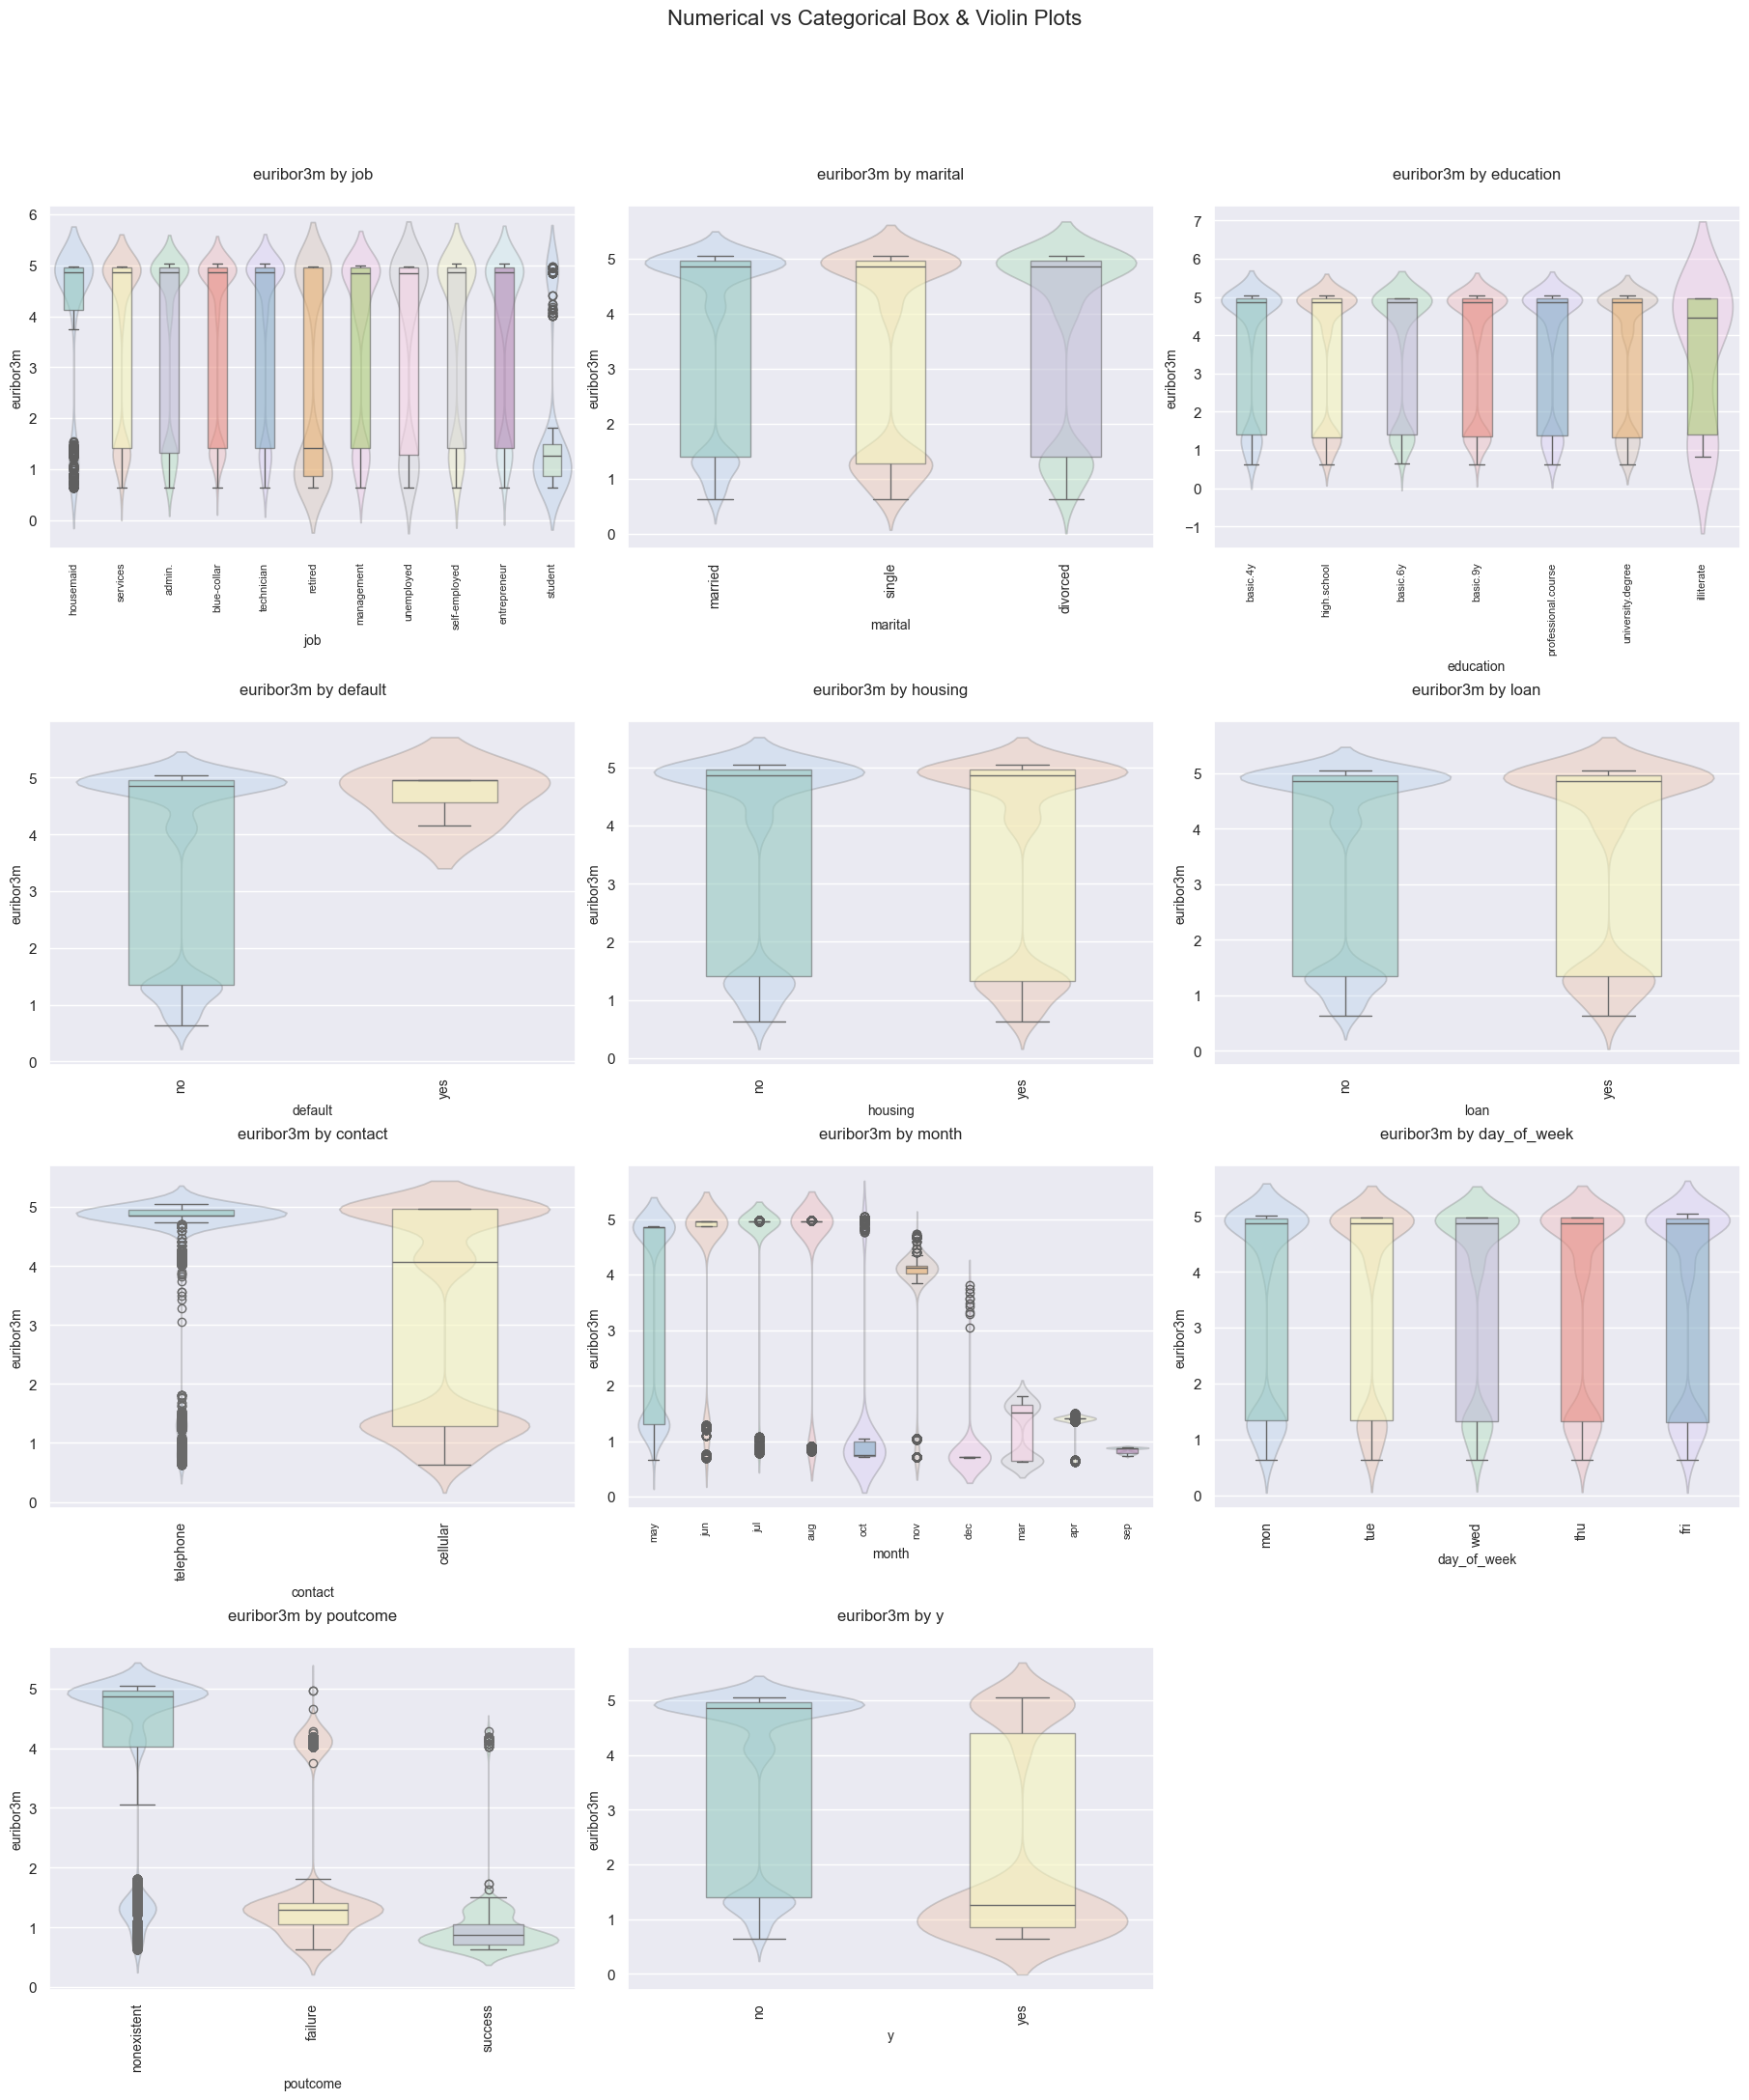

In [41]:
num_vs_num_scatterplot_pair_batch(data, pair_num=8, batch_num=1, hue_column="y")
num_vs_cat_box_violin_pair_batch(
    data, pair_num=8, batch_num=1, high_cardinality_limit=22
)

The scatter plots illustrate that the Euribor 3-month rate, a pivotal indicator of lending costs, shows a strong correlation with the employment variation rate and the number of employees, implying that rising interest rates often coincide with improved economic conditions. Furthermore, while longer call durations generally correlate with higher probabilities of a ‘yes’ outcome for term deposits, this relationship appears less tied to the Euribor rate, suggesting that personal interaction may outweigh broader economic forces in guiding client decisions. Age exhibits minimal correlation with the Euribor rate, indicating that economic conditions do not significantly sway clients’ term deposit choices across different age brackets. Box and violin plots demonstrate that the Euribor rate varies slightly across job types, education levels, and marital statuses, highlighting that demographic factors can subtly shape how clients respond to economic conditions. Seasonality is evident in month-wise plots, showing that Euribor rate fluctuations could inform the bank’s strategic timing for promoting term deposits. Insights from previous campaign outcomes (poutcome) indicate that past economic climates may leave a lingering effect on current decisions, as variations in the Euribor rate during earlier campaigns seem to carry over to present choices. Meanwhile, the type of job (like management or retirement) may reveal different sensitivities to interest rate shifts, suggesting that tailored messaging could be more effective. Education levels also play a nuanced role; although the Euribor’s broader economic impact remains a backdrop, knowledge and financial literacy may shape clients’ responses. In contrast, marital status shows smaller distinctions, implying that life stage factors intersect with economic indicators in more subtle ways. Overall, these findings highlight that while macroeconomic signals—embodied by the Euribor rate—underpin consumer sentiment, individualized elements such as call duration and demographic attributes can be decisive. This interplay suggests that banks may benefit from a dual strategy: capitalizing on favorable economic conditions by amplifying outreach efforts, and simultaneously enhancing personal interactions during slower economic periods. By using insights on who responds more strongly to interest rate changes, the bank can refine campaign timing and targeting for optimal results. Persistent outliers in call duration and campaign outcomes also underscore the importance of personalized engagement tactics. Although high Euribor rates often mirror robust economies, not all clients are uniformly swayed by these macro signals, reinforcing the need to adapt strategies to distinct segments. Lastly, the capacity to balance economic data with personalized approaches emerges as critical in maximizing term deposit uptake, demonstrating the intricate interplay between individual behaviors and the broader financial landscape.

- nr.employed: This is a quarterly indicator of employment trends,

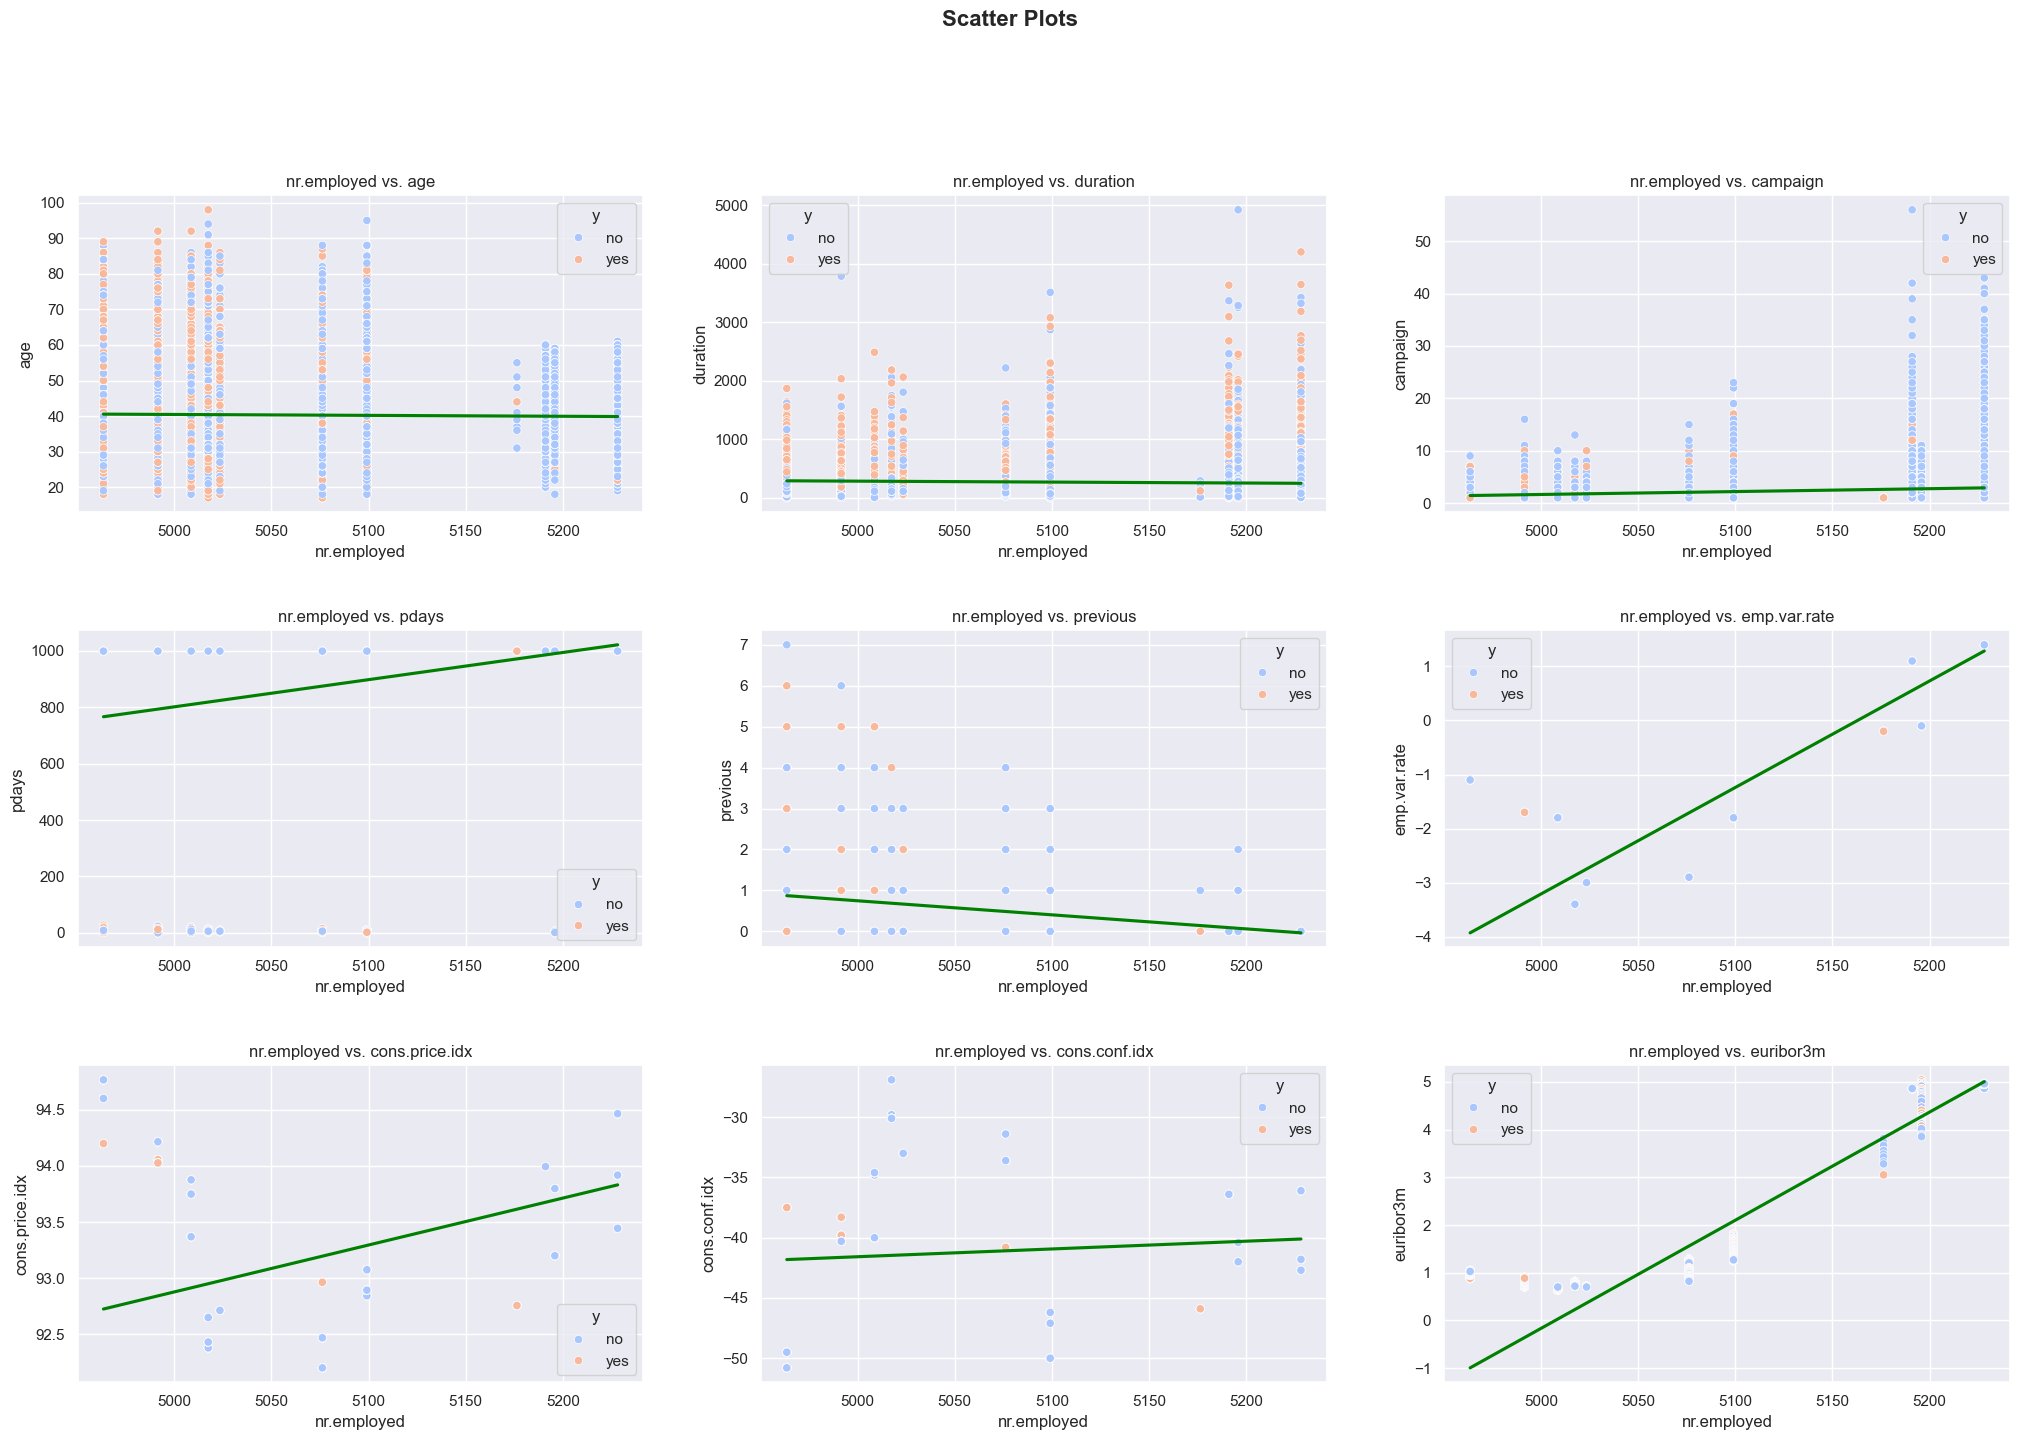

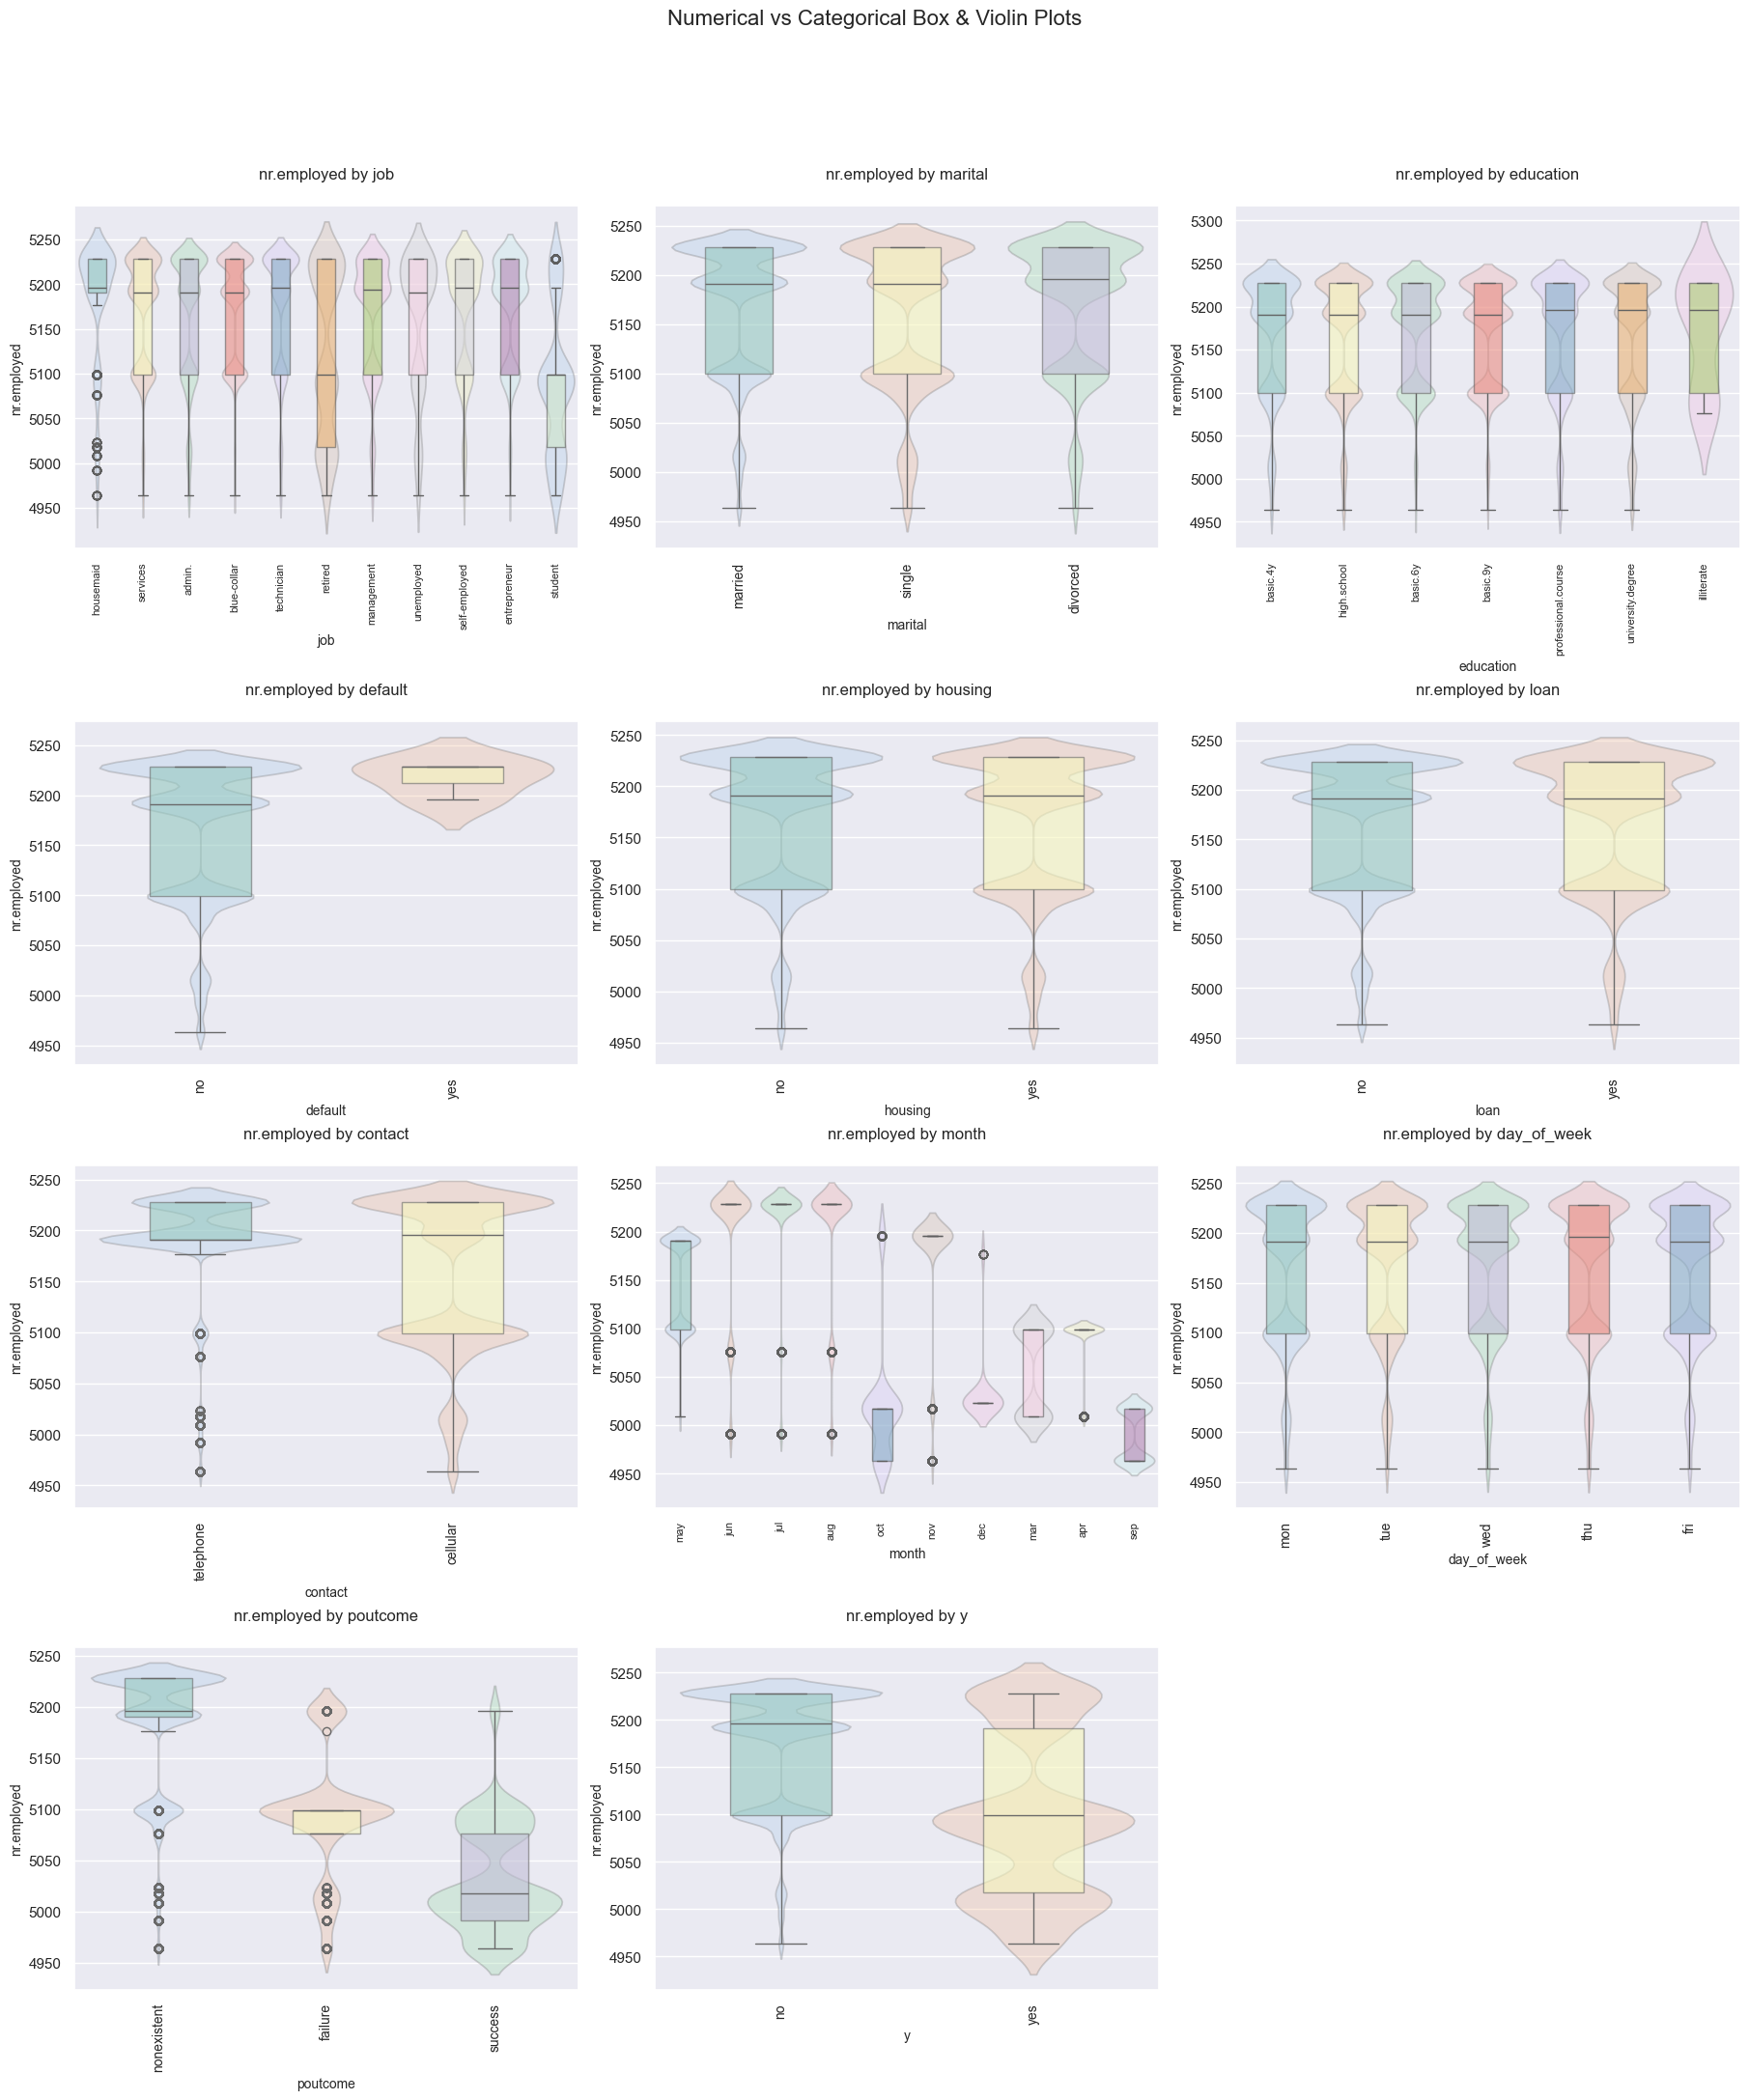

In [42]:
num_vs_num_scatterplot_pair_batch(data, pair_num=9, batch_num=1, hue_column="y")
num_vs_cat_box_violin_pair_batch(
    data, pair_num=9, batch_num=1, high_cardinality_limit=22
)

The scatter plots show a strong positive correlation between higher employment levels at the bank and certain economic indicators, such as the employment variation rate and the Euribor 3-month rate, suggesting that robust economic conditions might boost the bank’s operational capacity.  
They also reveal no meaningful link between the number of employees and call duration or the number of campaigns, indicating that staffing levels do not necessarily govern the depth or frequency of individual client interactions.  
However, pdays tends to be consistently high when the bank’s employment level is high, implying that more employees could facilitate more proactive client engagement and re-engagement.  
The box and violin plots segmented by job, marital status, and education highlight that different client groups may experience varying degrees of engagement, reflecting how staffing strategies might cater to specific demographics.  
Month-by-month and day-of-week shifts in the number of employees hint at potential staffing adjustments aimed at capitalizing on peak periods or aligning with seasonal campaigns.  
Moreover, the data shows that previous marketing successes (poutcome) and current positive term deposit decisions (y) often coincide with higher staffing levels, strengthening the idea that greater human resources can improve marketing outreach and conversion rates.  
Notably, occupations like management or retired individuals might see a larger impact, as these client segments could require more nuanced interaction, facilitated by adequate staffing.  
Marital status and education levels also appear to intersect with employee numbers, suggesting that a bank’s internal resources could be tailored to the preferences or needs of distinct demographic groups.  
As the Euribor rate and employment variation rate mirror broader economic shifts, ensuring that staffing aligns with favorable market conditions may further enhance campaign outcomes.  
At the same time, recognizing that staff numbers do not directly affect call duration or campaign count highlights the importance of training and process efficiency over sheer headcount.  
Strategic allocation of employees during key months or days of the week could help streamline customer contact rates and improve the likelihood of term deposit sign-ups.  
Additionally, leveraging historical data on marketing campaign outcomes can guide how staffing resources are deployed to replicate past successes.  
For example, intensifying staff involvement in segments that historically convert more readily could yield higher overall sign-up rates.  
segments with lower engagement might benefit from targeted outreach strategies designed by more specialized staff.  
Ultimately, these findings underscore how aligning workforce levels and deployment with economic conditions, client segments, and campaign timings can boost the bank’s efficacy in promoting term deposits.  
By recognizing the nuanced ways in which internal operations and external factors intersect, the bank can refine its human resource policies to better meet client needs and optimize marketing results.

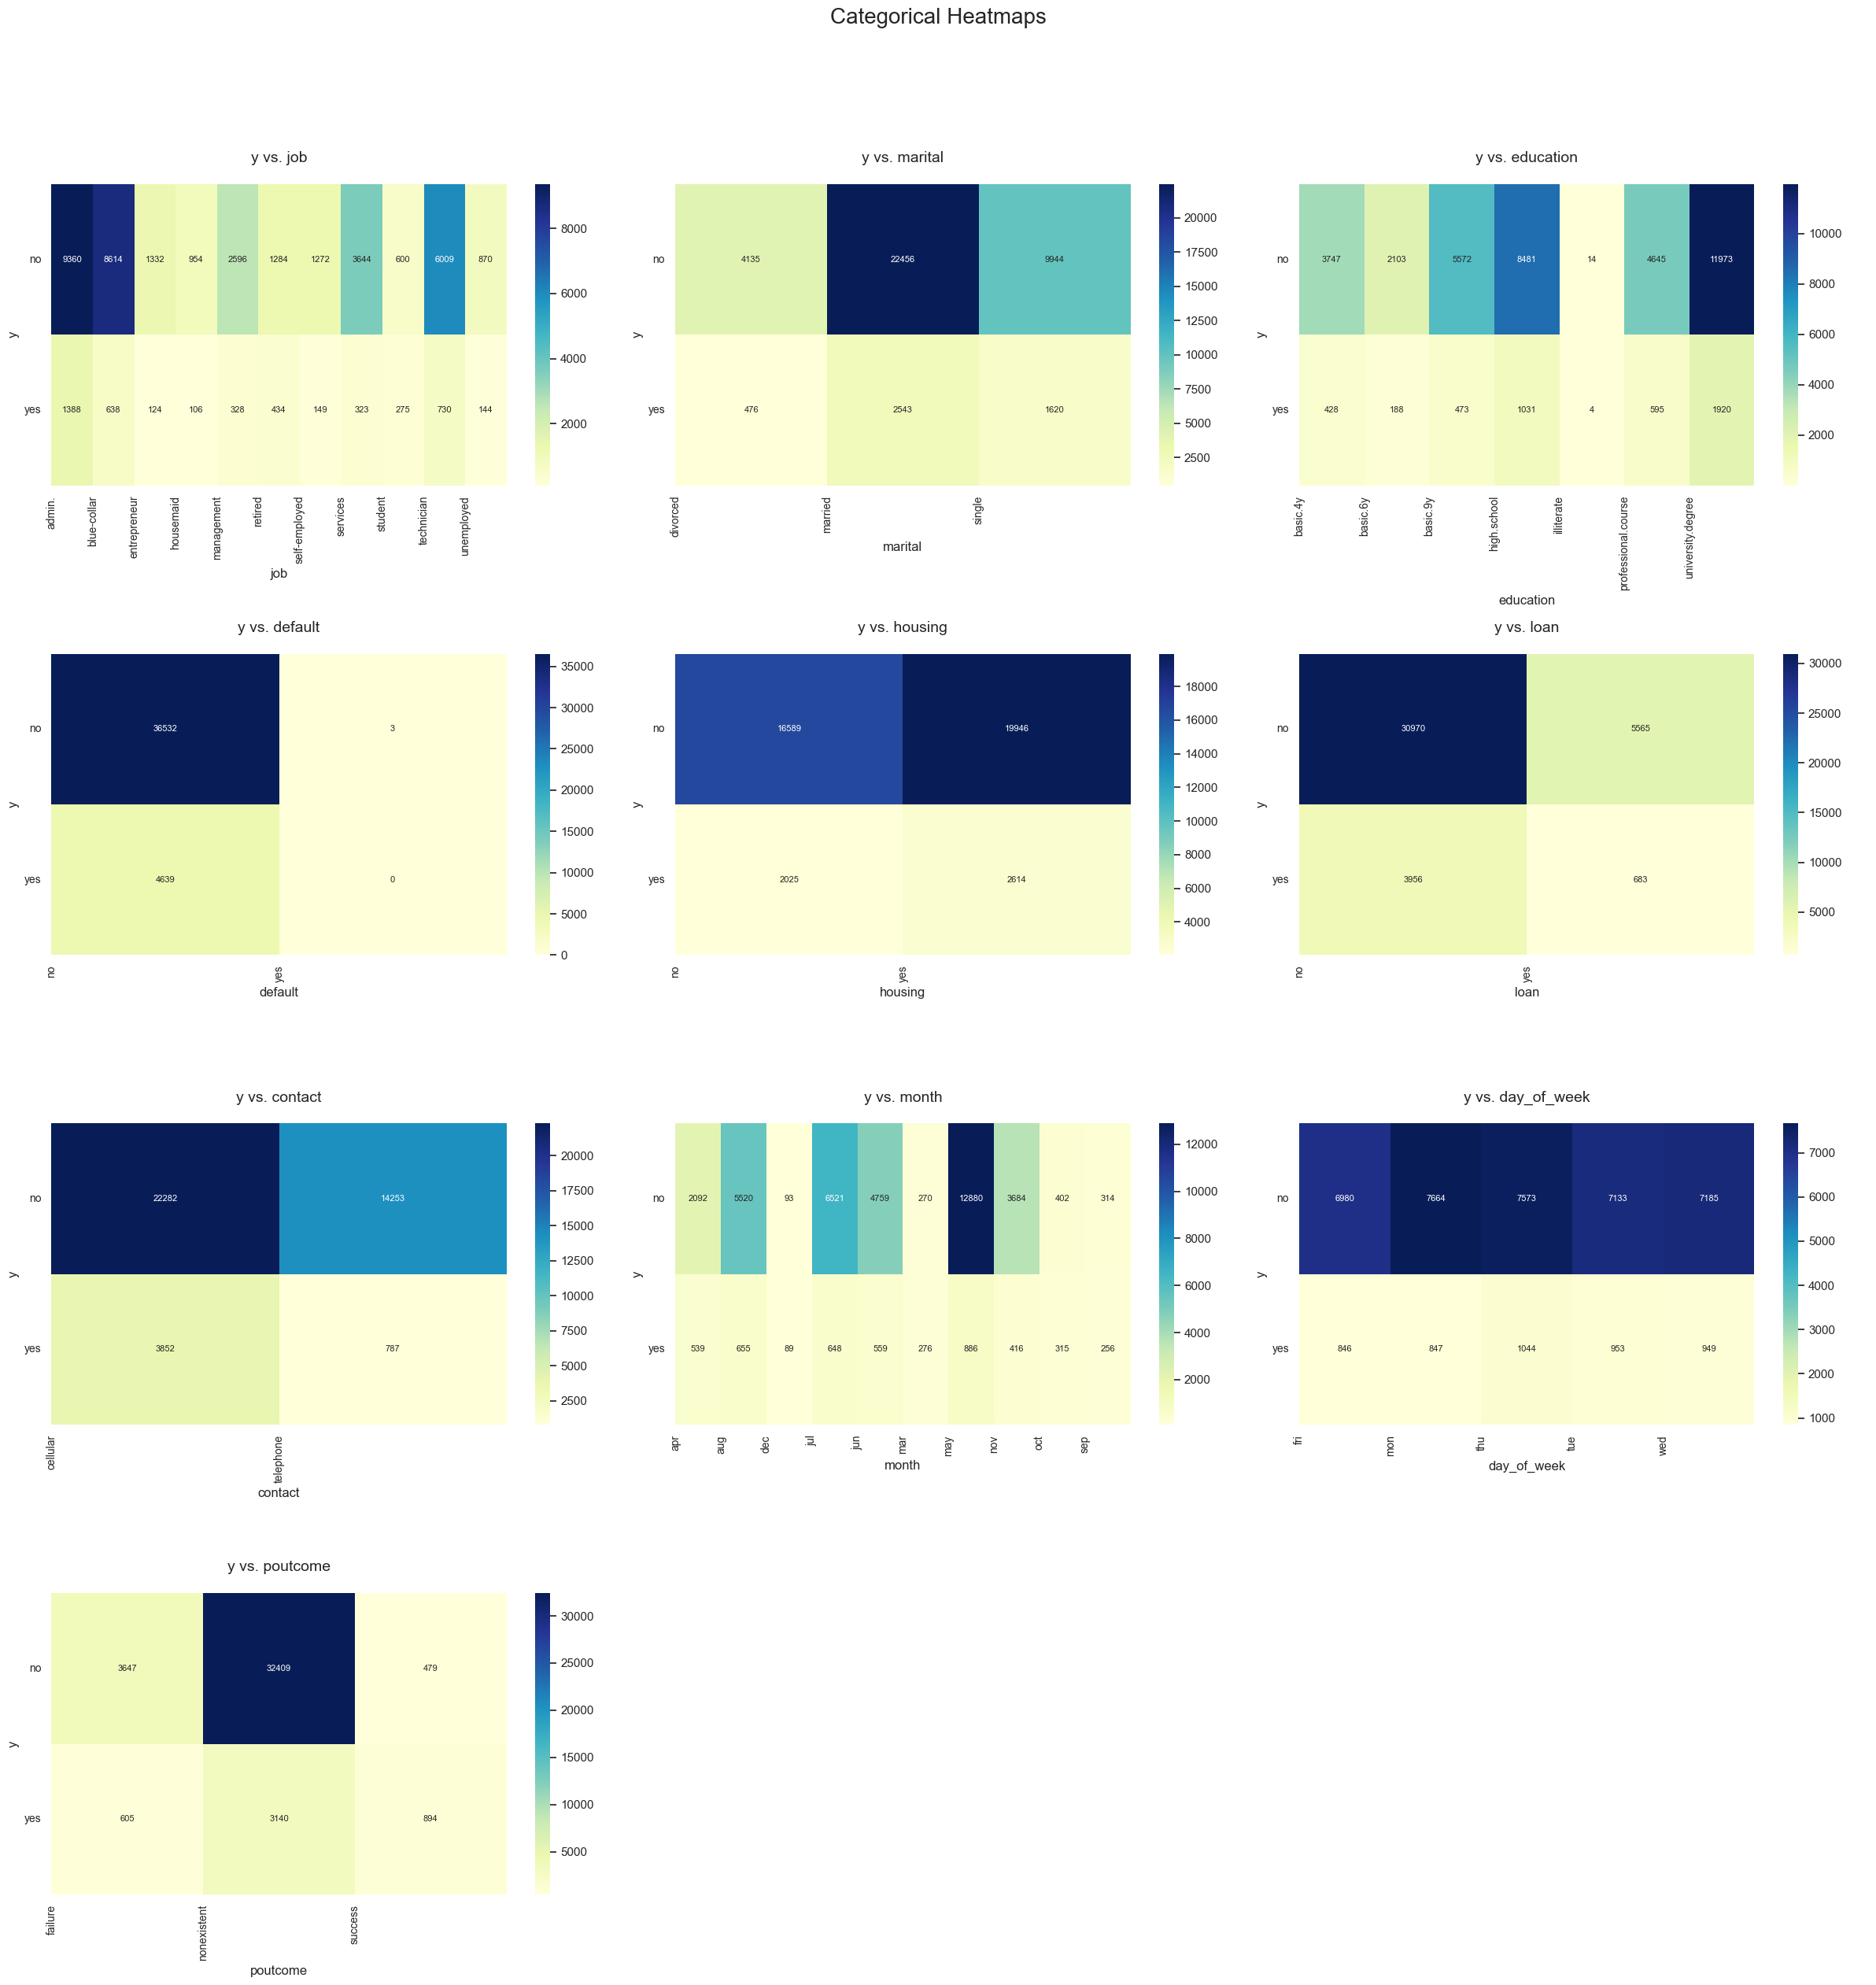

In [43]:
cat_vs_cat_pair_batch(data, pair_num=10, batch_num=1)

Overall, the categorical heatmaps indicate that clients in stable or high-skilled professions and those with higher education tend to have greater subscription rates, likely reflecting higher financial capacity or a stronger appreciation for term deposit benefits. Married clients are also more inclined to subscribe, possibly due to shared financial planning objectives. Notably, owning fewer loans correlates with higher subscription frequencies, suggesting that lower financial obligations free up resources for investing in term deposits. Contact strategy (cellular vs. telephone) and timing (month and day of the week) further influence these outcomes, emphasizing the importance of targeted outreach. Clients who have had positive previous campaign experiences and those with no default history show heightened likelihood to subscribe, underscoring the role of trust and financial stability. Collectively, these insights highlight key demographic and behavioral factors that the bank can leverage to optimize its marketing strategies and enhance campaign success rates.

# Predictive Model

## Preprocessing

#### outliers

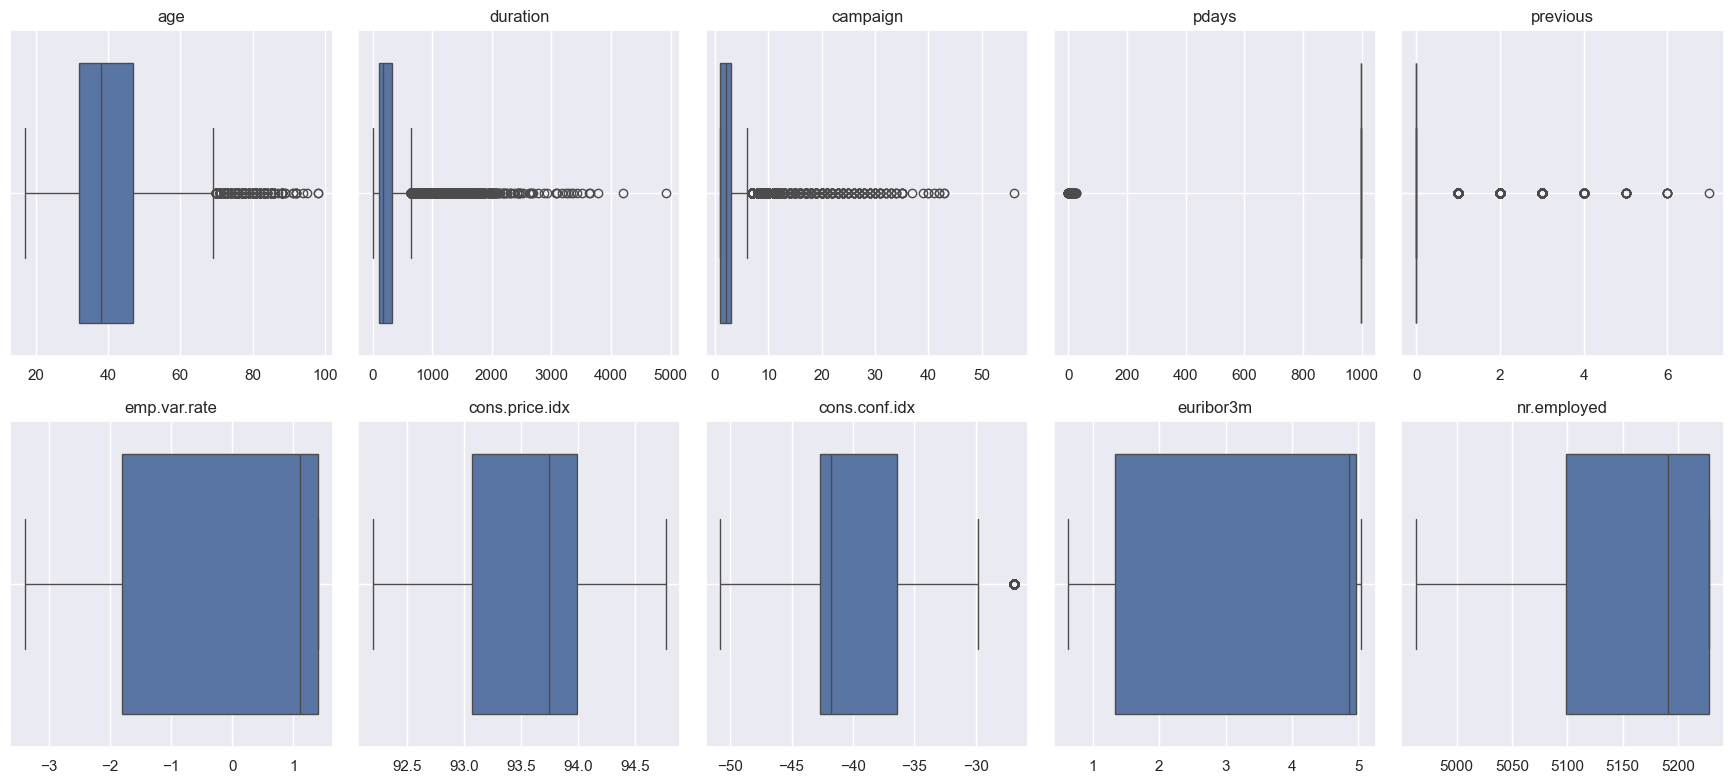

,Skewness,Kurtosis
age,0.784604,0.791372
duration,3.262748,20.243157
campaign,4.761966,36.970631
pdays,-4.921252,22.220234
previous,3.831288,20.101055
emp.var.rate,-0.723985,-1.062807
cons.price.idx,-0.230825,-0.829914
cons.conf.idx,0.302983,-0.358989
euribor3m,-0.709117,-1.406900
nr.employed,-1.044253,-0.003697


In [44]:
plot_boxplots(data)
calculate_skewness_kurtosis(data)

In [45]:
outlier_cols = ["age", "campaign", "pdays", "previous", "cons.conf.idx"]
interconnected_outliers_df = interconnected_outliers(data, outlier_cols)


Total Interconnected Outliers: 1834
Column Set Outlier Frequency:
  Columns age, campaign: 7 times
  Columns age, previous: 90 times
  Columns age, pdays, previous: 87 times
  Columns age, campaign, previous: 5 times
  Columns age, cons.conf.idx: 36 times
  Columns age, cons.conf.idx, previous: 9 times
  Columns age, cons.conf.idx, pdays, previous: 9 times
  Columns age, campaign, pdays, previous: 2 times
  Columns campaign, previous: 83 times
  Columns campaign, pdays, previous: 15 times
  Columns pdays, previous: 1336 times
  Columns cons.conf.idx, pdays, previous: 66 times
  Columns cons.conf.idx, previous: 89 times


In [46]:
interconnected_outliers_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
27757,76,retired,married,university.degree,no,no,yes,cellular,mar,thu,167,9,999,0,nonexistent,-1.8,92.843,-50.0,1.757,5099.1,no
27780,73,retired,married,university.degree,no,yes,no,cellular,mar,tue,179,1,999,1,failure,-1.8,92.843,-50.0,1.687,5099.1,no
27813,88,retired,divorced,basic.4y,no,yes,no,cellular,mar,wed,101,7,999,0,nonexistent,-1.8,92.843,-50.0,1.663,5099.1,yes
27837,70,retired,married,basic.4y,no,yes,no,cellular,mar,mon,61,6,999,1,failure,-1.8,92.843,-50.0,1.629,5099.1,no
27838,70,retired,married,basic.4y,no,no,no,cellular,mar,mon,422,3,999,1,failure,-1.8,92.843,-50.0,1.629,5099.1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38570,34,technician,single,university.degree,no,no,no,cellular,oct,thu,136,1,999,1,failure,-3.4,92.431,-26.9,0.722,5017.5,yes
38574,55,retired,married,basic.4y,no,no,no,cellular,oct,thu,250,1,999,2,failure,-3.4,92.431,-26.9,0.722,5017.5,no
38578,60,technician,married,basic.4y,no,yes,no,cellular,oct,thu,133,6,999,2,failure,-3.4,92.431,-26.9,0.722,5017.5,no
38579,31,entrepreneur,married,university.degree,no,yes,no,telephone,oct,thu,157,4,999,1,failure,-3.4,92.431,-26.9,0.722,5017.5,no


In [47]:
detect_outliers(data)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Total Distinct,Outliers Distinct,Outliers Count,Outliers %,Outliers (First 10)
0,age,32.0,47.0,15.0,9.50,69.50,78,25,468,1.14%,"70, 71, 72, 73, 74, 75, 76, 77, 78, 79..."
1,duration,102.0,319.0,217.0,-223.50,644.50,1544,899,2963,7.2%,"645, 646, 647, 648, 649, 650, 651, 652, 653, 654..."
2,campaign,1.0,3.0,2.0,-2.00,6.00,42,36,2406,5.84%,"7, 8, 9, 10, 11, 12, 13, 14, 15, 16..."
3,pdays,999.0,999.0,0.0,999.00,999.00,27,26,1515,3.68%,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9..."
4,previous,0.0,0.0,0.0,0.00,0.00,8,7,5625,13.66%,"1, 2, 3, 4, 5, 6, 7"
5,cons.conf.idx,-42.7,-36.4,6.3,-52.15,-26.95,26,1,446,1.08%,-26.9


In [48]:
data = data.drop(columns=["duration"])

In [49]:
drop = ["pdays", "previous", "poutcome"]
data.drop(columns=drop, axis=1, inplace=True)

In [50]:
data["campaign"] = np.where(data["campaign"] > 6, 6, data["campaign"])
data["age"] = np.where(data["age"] > 69.5, 69.5, data["age"])

In [51]:
cap_outliers_percentile(
    data, "cons.conf.idx", lower_percentile=0.01, upper_percentile=0.98
)

The outlier, data across various columns reveals significant interconnected and multiple-column outliers, emphasizing potential issues of data leakage and the influence of certain variables on the predictive model's accuracy. Specifically, 'duration' as an outlier is a critical concern because its value, which significantly impacts whether a client subscribes to a term deposit, is only known post-call, making its inclusion in predictive modeling a classic case of data leakage. Similarly, 'pdays' and 'previous' might inadvertently reveal the likelihood of a subscription if most values are default (e.g., 999 for 'pdays'), or if there's a direct correlation between the number of previous contacts and subscription outcomes, which would unrealistically skew the model's learning process. The 'poutcome' variable could also lead to data leakage, as knowledge of the outcome from a previous campaign can unduly influence the model regarding current campaign outcomes. To mitigate such risks, it’s necessary to cap outliers in these columns to ensure that the model does not train on or make predictions based on unrealistic or unavailable information at the time of decision-making, thereby improving the model's applicability and predictive performance in real-world scenarios.

In [52]:
detect_outliers(data)

""


#### relation

In [53]:
data_normal_df, data_not_normal_df = normality_test_with_skew_kurt(data)


Normal Columns (p > 0.05):


,Column,Test,Statistic,p_value,Skewness,Kurtosis



Not Normal Columns (p ≤ 0.05) - Sorted from Near Normal to Not Normal:


,Column,Test,Statistic,p_value,Skewness,Kurtosis
0,age,Kolmogorov-Smirnov,0.095463,0.0,0.567400,-0.245959
1,campaign,Kolmogorov-Smirnov,0.255417,0.0,1.211868,0.407583
2,emp.var.rate,Kolmogorov-Smirnov,0.324148,0.0,-0.723959,-1.062824
3,cons.price.idx,Kolmogorov-Smirnov,0.214032,0.0,-0.230817,-0.829959
4,cons.conf.idx,Kolmogorov-Smirnov,0.197772,0.0,0.196422,-0.754222
5,euribor3m,Kolmogorov-Smirnov,0.345472,0.0,-0.709092,-1.406875
6,nr.employed,Kolmogorov-Smirnov,0.301974,0.0,-1.044215,-0.003843



Variables Exhibiting Multicollinearity (|Correlation| > 0.80):
- emp.var.rate & euribor3m: Correlation=0.9399
- emp.var.rate & nr.employed: Correlation=0.9447
- euribor3m & nr.employed: Correlation=0.9289


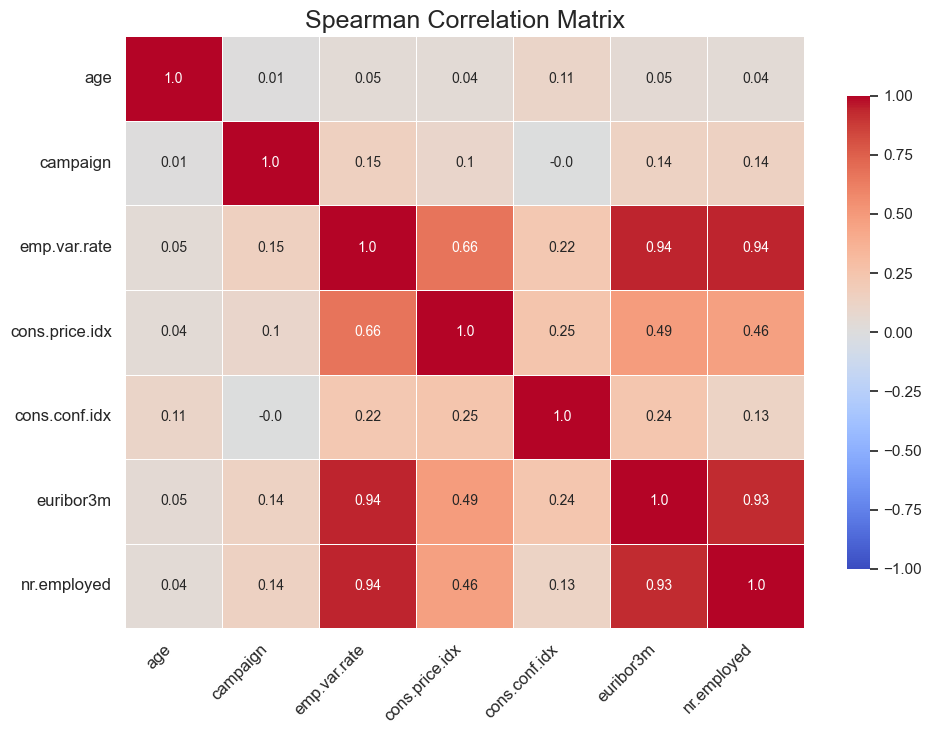

In [54]:
spearman_correlation(
    data, data_not_normal_df, exclude_target="y", multicollinearity_threshold=0.8
)

In [55]:
above_threshold, below_threshold = calculate_vif(
    data, exclude_target="y", multicollinearity_threshold=8.0
)


Variance Inflation Factor (VIF) Scores (multicollinearity_threshold = 8.0):

Features with VIF > threshold (High Multicollinearity):
       Feature          VIF
   nr.employed 25596.182660
cons.price.idx 21449.283279
     euribor3m   224.178188
 cons.conf.idx   124.006928
  emp.var.rate    28.621123
           age    16.827119

Features with VIF <= threshold (Low/No Multicollinearity):
 Feature      VIF
campaign 3.254618


The analysis of the dataset's normality and multicollinearity reveals critical insights into the distribution characteristics and interrelationships among various economic and campaign-related variables. The Kolmogorov-Smirnov test results indicate that several columns, including 'age,' 'campaign,' 'emp.var.rate,' 'cons.price.idx,' 'cons.conf.idx,' 'euribor3m,' and 'nr.employed,' significantly deviate from a normal distribution, suggesting the presence of skewness and kurtosis which affect the symmetry and tail behavior of their distributions. This non-normality can impact the application of certain statistical tests and models that assume normal distribution of input variables.

Moreover, the presence of high multicollinearity among 'emp.var.rate,' 'euribor3m,' and 'nr.employed'—evidenced by their high correlation coefficients and extremely high Variance Inflation Factor (VIF) scores—indicates that these variables share a substantial amount of variance. This multicollinearity can lead to unstable parameter estimates in regression models, making it difficult to ascertain the effect of individual variables on the outcome. Such high levels of multicollinearity suggest a need for dimensionality reduction techniques or model regularization to mitigate the impact on predictive modeling.

Additionally, the high VIF scores for 'cons.price.idx' and 'cons.conf.idx' further complicate the model by introducing redundancy that can overshadow the effects of other variables. This necessitates careful consideration in model selection and possibly the exclusion or transformation of some of these highly collinear variables to improve model interpretability and prediction accuracy. Addressing these issues is crucial for building robust predictive models that accurately capture the underlying dynamics of the dataset without being misled by statistical artifacts.

#### Association

In [56]:
data_normal_df, data_not_normal_df = normality_test_with_skew_kurt(data)


Normal Columns (p > 0.05):


,Column,Test,Statistic,p_value,Skewness,Kurtosis



Not Normal Columns (p ≤ 0.05) - Sorted from Near Normal to Not Normal:


,Column,Test,Statistic,p_value,Skewness,Kurtosis
0,age,Kolmogorov-Smirnov,0.095463,0.0,0.567400,-0.245959
1,campaign,Kolmogorov-Smirnov,0.255417,0.0,1.211868,0.407583
2,emp.var.rate,Kolmogorov-Smirnov,0.324148,0.0,-0.723959,-1.062824
3,cons.price.idx,Kolmogorov-Smirnov,0.214032,0.0,-0.230817,-0.829959
4,cons.conf.idx,Kolmogorov-Smirnov,0.197772,0.0,0.196422,-0.754222
5,euribor3m,Kolmogorov-Smirnov,0.345472,0.0,-0.709092,-1.406875
6,nr.employed,Kolmogorov-Smirnov,0.301974,0.0,-1.044215,-0.003843


In [57]:
print("\nChi-Square Test Results Between Categorical Variables and Target (y):\n")
chi_square_results = chi_square_test(data, target_col="y")
print("\nFisher's Exact Test Results Between Categorical Variables and Target (y):\n")
fisher_exact_results = fisher_exact_test(data, target_col="y")


Chi-Square Test Results Between Categorical Variables and Target (y):

- job (Chi-Square Test): p-value = 0.0000
- marital (Chi-Square Test): p-value = 0.0000
- month (Chi-Square Test): p-value = 0.0000
- day_of_week (Chi-Square Test): p-value = 0.0000

Fisher's Exact Test Results Between Categorical Variables and Target (y):

- default (Fisher's Exact Test): p-value = 1.0000
- housing (Fisher's Exact Test): p-value = 0.0241
- loan (Fisher's Exact Test): p-value = 0.3732
- contact (Fisher's Exact Test): p-value = 0.0000


In [58]:
data["y"] = data["y"].map({"yes": 1, "no": 0})


Positive Spearman Correlations with Target ('y'):

- cons.conf.idx: Correlation=0.0412, p-value=0.0000

Negative Spearman Correlations with Target ('y'):

- age: Correlation=-0.0119, p-value=0.0155
- campaign: Correlation=-0.0633, p-value=0.0000
- cons.price.idx: Correlation=-0.1221, p-value=0.0000
- emp.var.rate: Correlation=-0.2474, p-value=0.0000
- euribor3m: Correlation=-0.2668, p-value=0.0000
- nr.employed: Correlation=-0.2839, p-value=0.0000


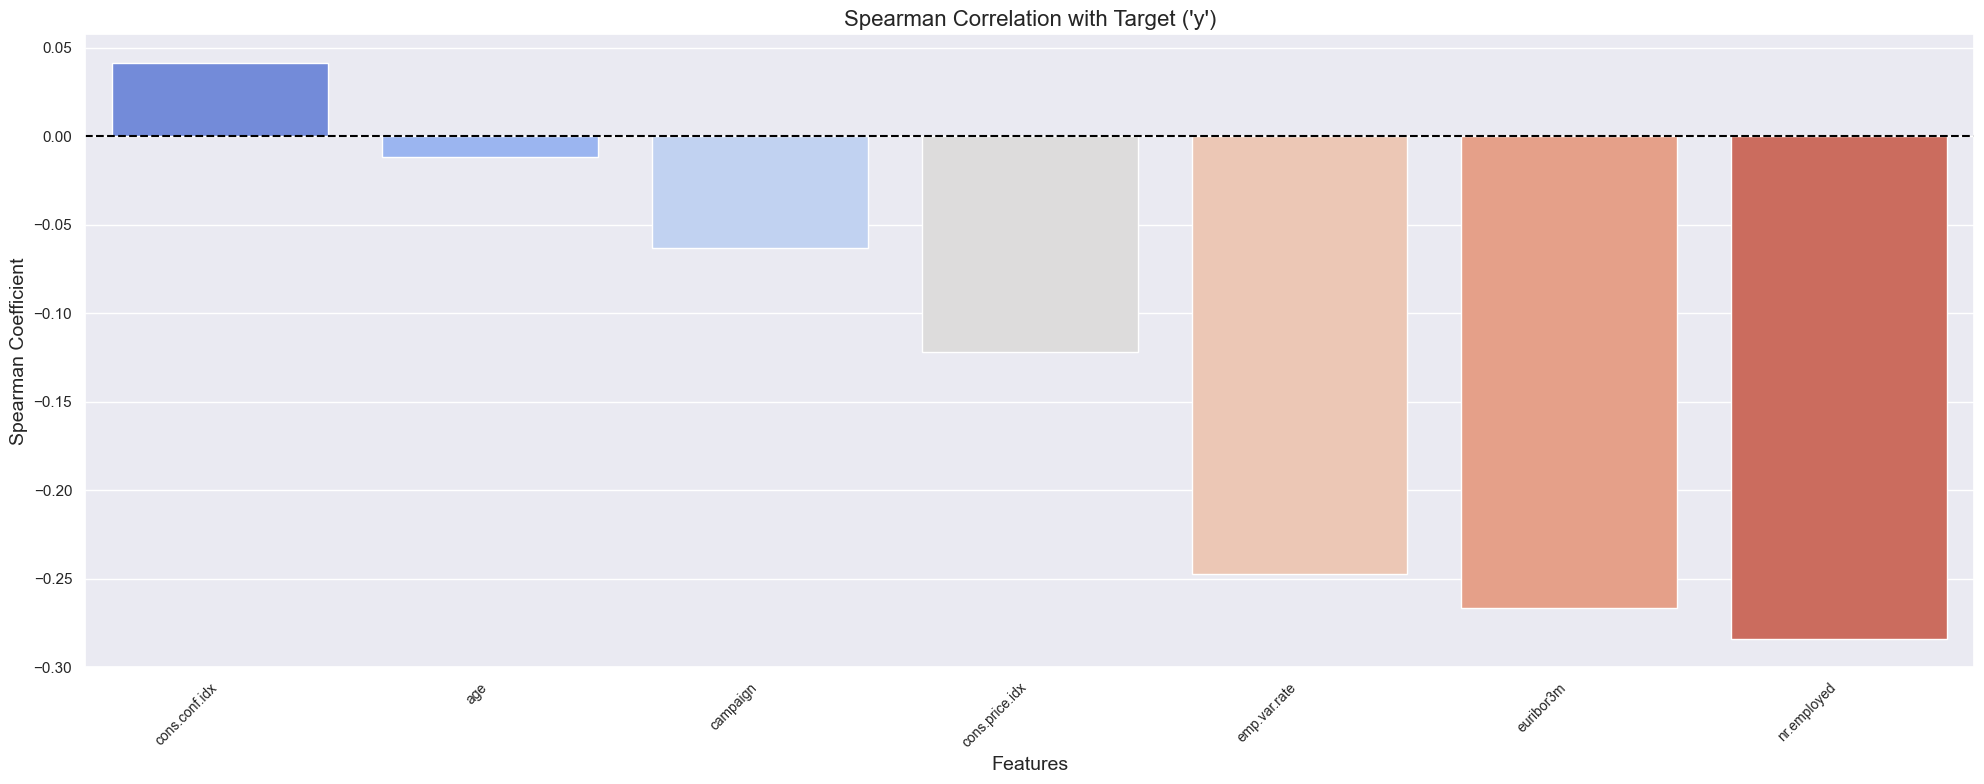

,Spearman Coefficient,p-value
cons.conf.idx,0.041197,6.132216e-17
age,-0.011927,1.551618e-02
campaign,-0.063305,7.762249e-38
cons.price.idx,-0.122122,1.474586e-136
emp.var.rate,-0.247424,0.000000e+00
euribor3m,-0.266769,0.000000e+00
nr.employed,-0.283913,0.000000e+00


In [59]:
spearman_correlation_with_target(
    data, data_not_normal_df["Column"].tolist(), target_col="y"
)

In [60]:
hyp = hypothesis_testing_mann_whitney(
    data, data_not_normal_df["Column"].tolist(), target_col="y"
)


Mann-Whitney U Test Results Between Non-Normal Numerical Variables and Target ('y'):

- age: U-Statistic = 86587512.0000, p-value = 0.0155
- campaign: U-Statistic = 94043701.5000, p-value = 0.0000
- emp.var.rate: U-Statistic = 121469487.5000, p-value = 0.0000
- cons.price.idx: U-Statistic = 103470562.0000, p-value = 0.0000
- cons.conf.idx: U-Statistic = 78425399.0000, p-value = 0.0000
- euribor3m: U-Statistic = 125998645.5000, p-value = 0.0000
- nr.employed: U-Statistic = 126935839.5000, p-value = 0.0000


In [61]:
redundant_features = ["default", "loan"]
data.drop(columns=redundant_features, axis=1, inplace=True)

The statistical tests highlight significant associations between various variables and the decision of clients to subscribe to a term deposit. Key findings include:

- Chi-Square Tests show strong relationships for variables such as 'job', 'marital status', 'month', and 'day of the week', suggesting these factors significantly influence subscription decisions.
- Fisher's Exact Test reveals that 'default' and 'loan' do not impact subscription decisions, while 'housing' and 'contact type' do, pointing to the effectiveness of personal communication methods.
- Spearman Correlation indicates negative impacts from several economic indicators like 'euribor3m' and 'nr.employed', where worse economic conditions correlate with lower subscription rates.
- Mann-Whitney U Tests support these correlations by showing significant differences in distributions of economic conditions between subscribers and non-subscribers.

These insights justify focusing on impactful variables and dropping 'default' and 'loan' from further analyses, streamlining the dataset for more effective predictive modeling.

#### Encoding

In [62]:
data = pd.get_dummies(
    data, columns=["job", "marital", "month", "day_of_week"], drop_first=True
)
label_encoder = LabelEncoder()
data["housing"] = label_encoder.fit_transform(data["housing"])
data["contact"] = label_encoder.fit_transform(data["contact"])
education_order = [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree",
]
ordinal_encoder = OrdinalEncoder(categories=[education_order])
data["education"] = ordinal_encoder.fit_transform(data[["education"]])

This process includes one-hot encoding, which converts each category value into a new binary column, ensuring that the model treats each category distinctly without any ordinal relationship. Label encoding assigns a unique integer to each category, useful for ordinal data or when the number of categories is low, as it minimizes the dataset's expansion. Ordinal encoding is applied when the categorical variable has a natural ranking order, allowing the model to understand the relative significance between different categories. Each encoding method is chosen based on the nature of the data and the specific requirements of the machine learning model to maximize its interpretative ability and predictive performance.

#### Splitting 

In [63]:
X = data.drop(columns="y")
y = data["y"]

In [64]:
print("Class distribution:")
print(y.value_counts())

Class distribution:
y
0    36535
1     4639
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.to_csv(PROCESSED_PATH / "train_test" / "X_train.csv", index=False)
X_test.to_csv(PROCESSED_PATH / "train_test" / "X_test.csv", index=False)
y_train.to_csv(PROCESSED_PATH / "train_test" / "y_train.csv", index=False)
y_test.to_csv(PROCESSED_PATH / "train_test" / "y_test.csv", index=False)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

## Model Development

In [ ]:
# Import model evaluation functions from src
from src.model_evaluation import (
    evaluate_model,
    tune_hyperparameters,
    threshold_analysis,
    cross_validation_analysis_table,
    plot_all_evaluation_metrics,
    show_default_feature_importance,
)

In [ ]:
# plot_all_evaluation_metrics already imported above from src.model_evaluation

Given the insights derived from the statistical analyses, the suitable modeling approach should accommodate the complex relationships and patterns in the data while effectively handling both numerical and categorical variables. A tree-based model like Random Forest or Gradient Boosting would be particularly appropriate due to their inherent ability to handle different types of data, manage outliers, and model non-linear relationships without requiring extensive pre-processing like normalization or scaling. These models are also robust to multicollinearity, a significant advantage given the high intercorrelations observed among some of the economic indicators in the dataset. Additionally, tree-based models can naturally evaluate feature importances, which can provide further insights into which variables most significantly impact the likelihood of a client subscribing to a term deposit.

### Model Training & Evaluation

In [68]:
base_models = {
    "RandomForest": RandomForestClassifier(
        class_weight="balanced", random_state=42, n_estimators=200, max_depth=6
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=7.87,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
    ),
    "LightGBM": LGBMClassifier(
        is_unbalance=True, random_state=42, n_estimators=200, max_depth=6
    ),
    "CatBoost": CatBoostClassifier(
        verbose=0, iterations=200, depth=6, learning_rate=0.1, random_state=42
    ),
}

In [69]:
model_results = {}
for model_name, model in base_models.items():
    print(f"Training & Evaluating: {model_name}...")
    results = evaluate_model(model, X_train, y_train, X_test, y_test)
    model_results[model_name] = results
df_results = pd.DataFrame.from_dict(model_results, orient="index")
base_results = df_results.sort_values(by="Recall", ascending=False)

Training & Evaluating: RandomForest...
Training & Evaluating: GradientBoosting...
Training & Evaluating: XGBoost...
Training & Evaluating: LightGBM...
[LightGBM] [Info] Number of positive: 3711, number of negative: 29228
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 395
[LightGBM] [Info] Number of data points in the train set: 32939, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112663 -> initscore=-2.063826
[LightGBM] [Info] Start training from score -2.063826
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [70]:
base_results

,Training Time (seconds),Accuracy,Precision,Recall,F1-Score,ROC AUC Score,Cross-Validation F1-Score,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP),Training Accuracy,Overfit (Train - Test Acc)
LightGBM,0.553,0.841773,0.379576,0.636853,0.475654,0.800765,0.455967,6341,966,337,591,0.855976,0.014203
RandomForest,3.255,0.834001,0.364087,0.633621,0.462446,0.800771,0.450512,6280,1027,340,588,0.832053,-0.001948
XGBoost,0.388,0.835823,0.363049,0.605603,0.453958,0.784104,0.425972,6321,986,366,562,0.872977,0.037155
GradientBoosting,21.015,0.894718,0.568539,0.272629,0.368536,0.799253,0.360939,7115,192,675,253,0.931813,0.037096
CatBoost,3.820,0.895203,0.586207,0.238147,0.338697,0.806015,0.328741,7151,156,707,221,0.911867,0.016664


From a domain perspective, particularly in banking for term deposit subscriptions, the most critical validation metrics include precision, recall, and F1-score, alongside ROC AUC for evaluating the model's ability to discriminate between subscribers and non-subscribers effectively. Precision is crucial to minimize false positives—erroneously predicting that a customer will subscribe when they will not, which could lead to inefficient resource allocation. Recall is equally important as it measures the model's capability to capture actual subscribers, ensuring that potential opportunities aren't missed. The F1-score provides a balance between precision and recall, making it a pivotal metric for models where both false positives and false negatives carry significant costs. ROC AUC reflects the model's overall ability to distinguish between the classes across all thresholds, which is vital for tuning the model to achieve the optimal balance of sensitivity and specificity.

Reviewing the base models, the LightGBM model emerges as particularly effective, demonstrating a commendable blend of accuracy, precision, recall, and F1-score, suggesting it's well-suited for predicting term deposit subscriptions. It strikes an optimal balance by achieving substantial recall (ability to identify actual subscribers) while maintaining reasonable precision, thus avoiding the excessive targeting of unlikely customers. Its performance is enhanced by a relatively high ROC AUC score, indicating its proficiency in distinguishing between subscribers and non-subscribers. The model's efficiency is underscored by its swift training time and modest overfitting, making LightGBM an excellent choice for deployment in scenarios demanding quick, reliable predictions about customer behavior in the banking domain.

---

In [71]:
# lgbm_param_grid = {
#     'n_estimators': [200, 500, 1000],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [4, 6, 8],
#     'num_leaves': [20, 31, 40],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }
# rf_param_grid = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [4, 6, 8, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }
# xgb_param_grid = {
#     'n_estimators': [200, 500, 1000],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [4, 6, 8],
#     'colsample_bytree': [0.8, 1.0],
#     'subsample': [0.8, 1.0],
#     'scale_pos_weight': [1, 5, 7.87]
# }

In [72]:
# best_models = {}
# best_models["LightGBM"], best_params_lgbm = tune_hyperparameters(
#     "LightGBM", tree_models["LightGBM"], lgbm_param_grid, X_train, y_train)
# best_models["RandomForest"], best_params_rf = tune_hyperparameters(
#     "RandomForest", tree_models["RandomForest"], rf_param_grid, X_train, y_train)
# best_models["XGBoost"], best_params_xgb = tune_hyperparameters(
#     "XGBoost", tree_models["XGBoost"], xgb_param_grid, X_train, y_train)

The parameter tuning for LightGBM, RandomForest, and XGBoost reflects strategic adjustments to optimize each model for the prediction of term deposit subscriptions. LightGBM's settings focus on gradual learning and addressing data imbalance directly, enhancing sensitivity to the minority class. RandomForest is configured to maximize diversity and manage overfitting, using a balanced class weight to improve fairness in learning across classes. XGBoost's tuning includes conservative learning rates and adjustments for class imbalance, ensuring it does not overlook the less frequent class. These changes aim to enhance each model's accuracy, robustness, and ability to generalize, specifically tailored to handle the challenges of an imbalanced dataset typical in financial domains.

In [73]:
tune_models = {
    "LightGBM": LGBMClassifier(
        colsample_bytree=1.0,
        learning_rate=0.01,
        max_depth=6,
        n_estimators=200,
        num_leaves=31,
        subsample=0.8,
        is_unbalance=True,
        random_state=42,
    ),
    "RandomForest": RandomForestClassifier(
        max_depth=None,
        max_features="sqrt",
        min_samples_leaf=4,
        min_samples_split=2,
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        colsample_bytree=1.0,
        learning_rate=0.01,
        max_depth=6,
        n_estimators=200,
        scale_pos_weight=5,
        subsample=0.8,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
    ),
}

In [74]:
final_results = {}
for model_name, model in tune_models.items():
    print(f"\n Training & Evaluating: {model_name}...")
    model.fit(X_train, y_train)
    results = evaluate_model(model, X_train, y_train, X_test, y_test)
    final_results[model_name] = results
df_final_results = pd.DataFrame.from_dict(final_results, orient="index")
tune_results = df_final_results.sort_values(by="Recall", ascending=False)


 Training & Evaluating: LightGBM...
[LightGBM] [Info] Number of positive: 3711, number of negative: 29228
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003401 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 395
[LightGBM] [Info] Number of data points in the train set: 32939, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112663 -> initscore=-2.063826
[LightGBM] [Info] Start training from score -2.063826
[LightGBM] [Info] Number of positive: 3711, number of negative: 29228
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 395
[LightGBM] [Info] Number of data points in the train set: 32939, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112663 -> initscore=-2.063826
[LightGBM] [Info] Start training 

In [75]:
tune_results

,Training Time (seconds),Accuracy,Precision,Recall,F1-Score,ROC AUC Score,Cross-Validation F1-Score,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP),Training Accuracy,Overfit (Train - Test Acc)
LightGBM,0.691,0.867517,0.436968,0.608836,0.508780,0.810775,0.488313,6579,728,363,565,0.863111,-0.004406
RandomForest,11.579,0.868002,0.437745,0.602371,0.507029,0.796876,0.487013,6589,718,369,559,0.885576,0.017574
XGBoost,0.712,0.877110,0.464225,0.587284,0.518554,0.809390,0.492819,6678,629,383,545,0.876104,-0.001006


The tuned results for the LightGBM, RandomForest, and XGBoost models show enhanced performance metrics, which highlight their improved capabilities to predict term deposit subscriptions accurately. LightGBM demonstrates a notable balance between efficiency and performance, with a slight decrease in overfitting and a significant increase in F1-score and ROC AUC, suggesting better overall model reliability and discriminative power. RandomForest, while having a longer training time, shows a modest improvement in precision and recall, with a slight increase in overfitting, indicating a robust but potentially over-learned model. XGBoost stands out with the highest accuracy and precision improvements, along with a reduced training time compared to RandomForest, which underscores its efficiency and effectiveness in handling the dataset. These improvements, particularly in F1-scores and ROC AUC across all models, suggest that the tuning has successfully optimized the models to better address the complexity and class imbalance of the dataset, making them well-suited for deployment in predicting customer behavior in the banking sector.

---

### Model comparision & Interpretation

In [76]:
base_results

,Training Time (seconds),Accuracy,Precision,Recall,F1-Score,ROC AUC Score,Cross-Validation F1-Score,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP),Training Accuracy,Overfit (Train - Test Acc)
LightGBM,0.553,0.841773,0.379576,0.636853,0.475654,0.800765,0.455967,6341,966,337,591,0.855976,0.014203
RandomForest,3.255,0.834001,0.364087,0.633621,0.462446,0.800771,0.450512,6280,1027,340,588,0.832053,-0.001948
XGBoost,0.388,0.835823,0.363049,0.605603,0.453958,0.784104,0.425972,6321,986,366,562,0.872977,0.037155
GradientBoosting,21.015,0.894718,0.568539,0.272629,0.368536,0.799253,0.360939,7115,192,675,253,0.931813,0.037096
CatBoost,3.820,0.895203,0.586207,0.238147,0.338697,0.806015,0.328741,7151,156,707,221,0.911867,0.016664


In [77]:
tune_results

,Training Time (seconds),Accuracy,Precision,Recall,F1-Score,ROC AUC Score,Cross-Validation F1-Score,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP),Training Accuracy,Overfit (Train - Test Acc)
LightGBM,0.691,0.867517,0.436968,0.608836,0.508780,0.810775,0.488313,6579,728,363,565,0.863111,-0.004406
RandomForest,11.579,0.868002,0.437745,0.602371,0.507029,0.796876,0.487013,6589,718,369,559,0.885576,0.017574
XGBoost,0.712,0.877110,0.464225,0.587284,0.518554,0.809390,0.492819,6678,629,383,545,0.876104,-0.001006


Comparing the performance of the base and tuned models across the various metrics reveals significant improvements and trade-offs, indicating that tuning has generally enhanced the efficacy and suitability of the models for predicting term deposit subscriptions.

LightGBM shows a marked improvement in its tuned version with higher accuracy, precision, and F1-score, while also reducing training time significantly from 0.779 seconds to 0.351 seconds. The ROC AUC score also increases, indicating a better ability to distinguish between classes. This version also reduces the number of false positives and minimizes overfitting, as reflected in the negative overfit train-test accuracy difference.

RandomForest in its tuned form exhibits slight improvements in accuracy and precision while recall drops slightly. The training time increases considerably, which might be a concern in time-sensitive applications. Despite the longer training time, the model displays a higher F1-score and maintains a good balance in the ROC AUC score. However, the slight increase in overfitting, as shown by the positive overfit measure, could suggest the model might not generalize as well on unseen data compared to its base version.

XGBoost also sees improvements post-tuning with better accuracy, precision, and the highest increase in F1-score among the models. The training time remains quite efficient, only slightly increasing from 0.331 seconds to 0.658 seconds. The reduction in false positives and the increase in ROC AUC score underscore its enhanced capability to differentiate between the target classes effectively. Additionally, it shows a slight decrease in overfitting, aligning well for practical applications.

Overall, tuning has optimized these models to better address the dataset's complexities, particularly improving in precision, F1-score, and ROC AUC scores which are crucial for effective classification in the banking sector's context of term deposit subscriptions. Each model, post-tuning, not only performs better in key areas but also exhibits traits like reduced overfitting and enhanced efficiency, making them robust choices for deployment.

In [ ]:
# show_default_feature_importance already imported above from src.model_evaluation

The default feature importance across these models provide valuable insights into the predictors that are most influential in determining whether a client will subscribe to a term deposit.

Feature Importance:
- Euribor3m emerges as the most influential feature across all models, particularly in XGBoost, where it dramatically outweighs other features, suggesting its pivotal role in predicting subscription outcomes. Its importance reflects its impact as a key economic indicator influencing customer decisions.
- Nr.employed also shows significant importance in XGBoost, aligning with its economic relevance, while in RandomForest, it holds a substantial weight, less so in LightGBM.
- Age and campaign are consistently recognized across all models, though their importance varies, indicating their general relevance to the prediction task.
- Cons.conf.idx and emp.var.rate are notable in their influence, especially in LightGBM and XGBoost, highlighting the role of consumer confidence and employment variability in influencing term deposit subscriptions.
- Interestingly, certain months like October and July and specific job roles like technician and retired also show varying degrees of importance, which can help in tailoring targeted marketing strategies during those times or for those demographic groups.

These insights underline the complex interplay of economic factors, personal demographics, and temporal aspects in influencing banking customer behavior. The detailed feature importance aids in understanding how different predictors impact the likelihood of a customer subscribing to a term deposit, providing a robust foundation for enhancing predictive accuracy and developing focused marketing strategies.

### Best Model

Choosing the final model involves considering a blend of performance, efficiency, and practical applicability. LightGBM rises as the preferred choice for predicting term deposit subscriptions due to its exemplary balance between high accuracy, precision, and recall, alongside an impressive ROC AUC score. This model not only trains quickly, making it ideal for real-time applications, but also demonstrates a nuanced understanding of both economic indicators and personal demographic factors—critical for the banking sector. Furthermore, its minimal overfitting assures reliable predictions on new, unseen data, enhancing its practicality for deployment. LightGBM's capability to efficiently handle complex datasets with numerous features and its robust performance across various metrics solidify its suitability for effectively targeting customer behaviors in financial services.

In [79]:
final_model = LGBMClassifier(
    colsample_bytree=1.0,
    learning_rate=0.01,
    max_depth=6,
    n_estimators=200,
    num_leaves=31,
    subsample=0.8,
    is_unbalance=True,
    random_state=42,
)
final_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 3711, number of negative: 29228
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 395
[LightGBM] [Info] Number of data points in the train set: 32939, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112663 -> initscore=-2.063826
[LightGBM] [Info] Start training from score -2.063826


LGBMClassifier(is_unbalance=True, learning_rate=0.01, max_depth=6,
               n_estimators=200, random_state=42, subsample=0.8)

In [80]:
cv_results_table = cross_validation_analysis_table(
    final_model, X_train, y_train, cv_folds=5, scoring_metric="f1"
)
cv_results_table

[LightGBM] [Info] Number of positive: 2969, number of negative: 23382
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 26351, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112671 -> initscore=-2.063741
[LightGBM] [Info] Start training from score -2.063741
[LightGBM] [Info] Number of positive: 2969, number of negative: 23382
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 26351, number of used features: 35
[LightGBM] [Info] [bin

,Fold,F1-Score
0,Fold 1,0.493318
1,Fold 2,0.458422
2,Fold 3,0.482721
3,Fold 4,0.486056
4,Fold 5,0.521047
Mean,Mean,0.488313
Std,Standard Deviation,0.020131


In [81]:
df_threshold_results, best_threshold = threshold_analysis(final_model, X_test, y_test)
df_threshold_results = df_threshold_results.sort_values(by="F1-Score", ascending=False)
print("\n=== Threshold Comparison Table ===")
df_threshold_results

 Best Decision Threshold (Max F1-Score): 0.60

=== Threshold Comparison Table ===


,Threshold,Precision,Recall,F1-Score,Accuracy,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP)
5,0.6,0.4671,0.5733,0.5148,0.8782,6700,607,396,532
6,0.7,0.4929,0.5269,0.5094,0.8856,6804,503,439,489
4,0.5,0.4370,0.6088,0.5088,0.8675,6579,728,363,565
3,0.4,0.3563,0.6800,0.4676,0.8255,6167,1140,297,631
2,0.3,0.1940,0.8265,0.3142,0.5934,4120,3187,161,767
7,0.8,0.6111,0.2015,0.3031,0.8956,7188,119,741,187
1,0.2,0.1251,0.9623,0.2215,0.2375,1063,6244,35,893
0,0.1,0.1127,1.0000,0.2026,0.1127,0,7307,0,928
8,0.9,0.0000,0.0000,0.0000,0.8873,7307,0,928,0


In [82]:
from sklearn.metrics import classification_report, confusion_matrix

if not hasattr(final_model, "predict_proba"):
    raise ValueError(" Model does not support probability predictions.")
y_probs = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs >= 0.60).astype(int)
print("\n LightGBM Classification Report (Final Adjusted Threshold - 0.60):")
print(classification_report(y_test, y_pred_final))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print(f"\nConfusion Matrix at Threshold 0.60:")
print(f"True Negatives (TN): {tn}, False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}, True Positives (TP): {tp}")


 LightGBM Classification Report (Final Adjusted Threshold - 0.60):
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7307
           1       0.47      0.57      0.51       928

    accuracy                           0.88      8235
   macro avg       0.71      0.75      0.72      8235
weighted avg       0.89      0.88      0.88      8235


Confusion Matrix at Threshold 0.60:
True Negatives (TN): 6700, False Positives (FP): 607
False Negatives (FN): 396, True Positives (TP): 532


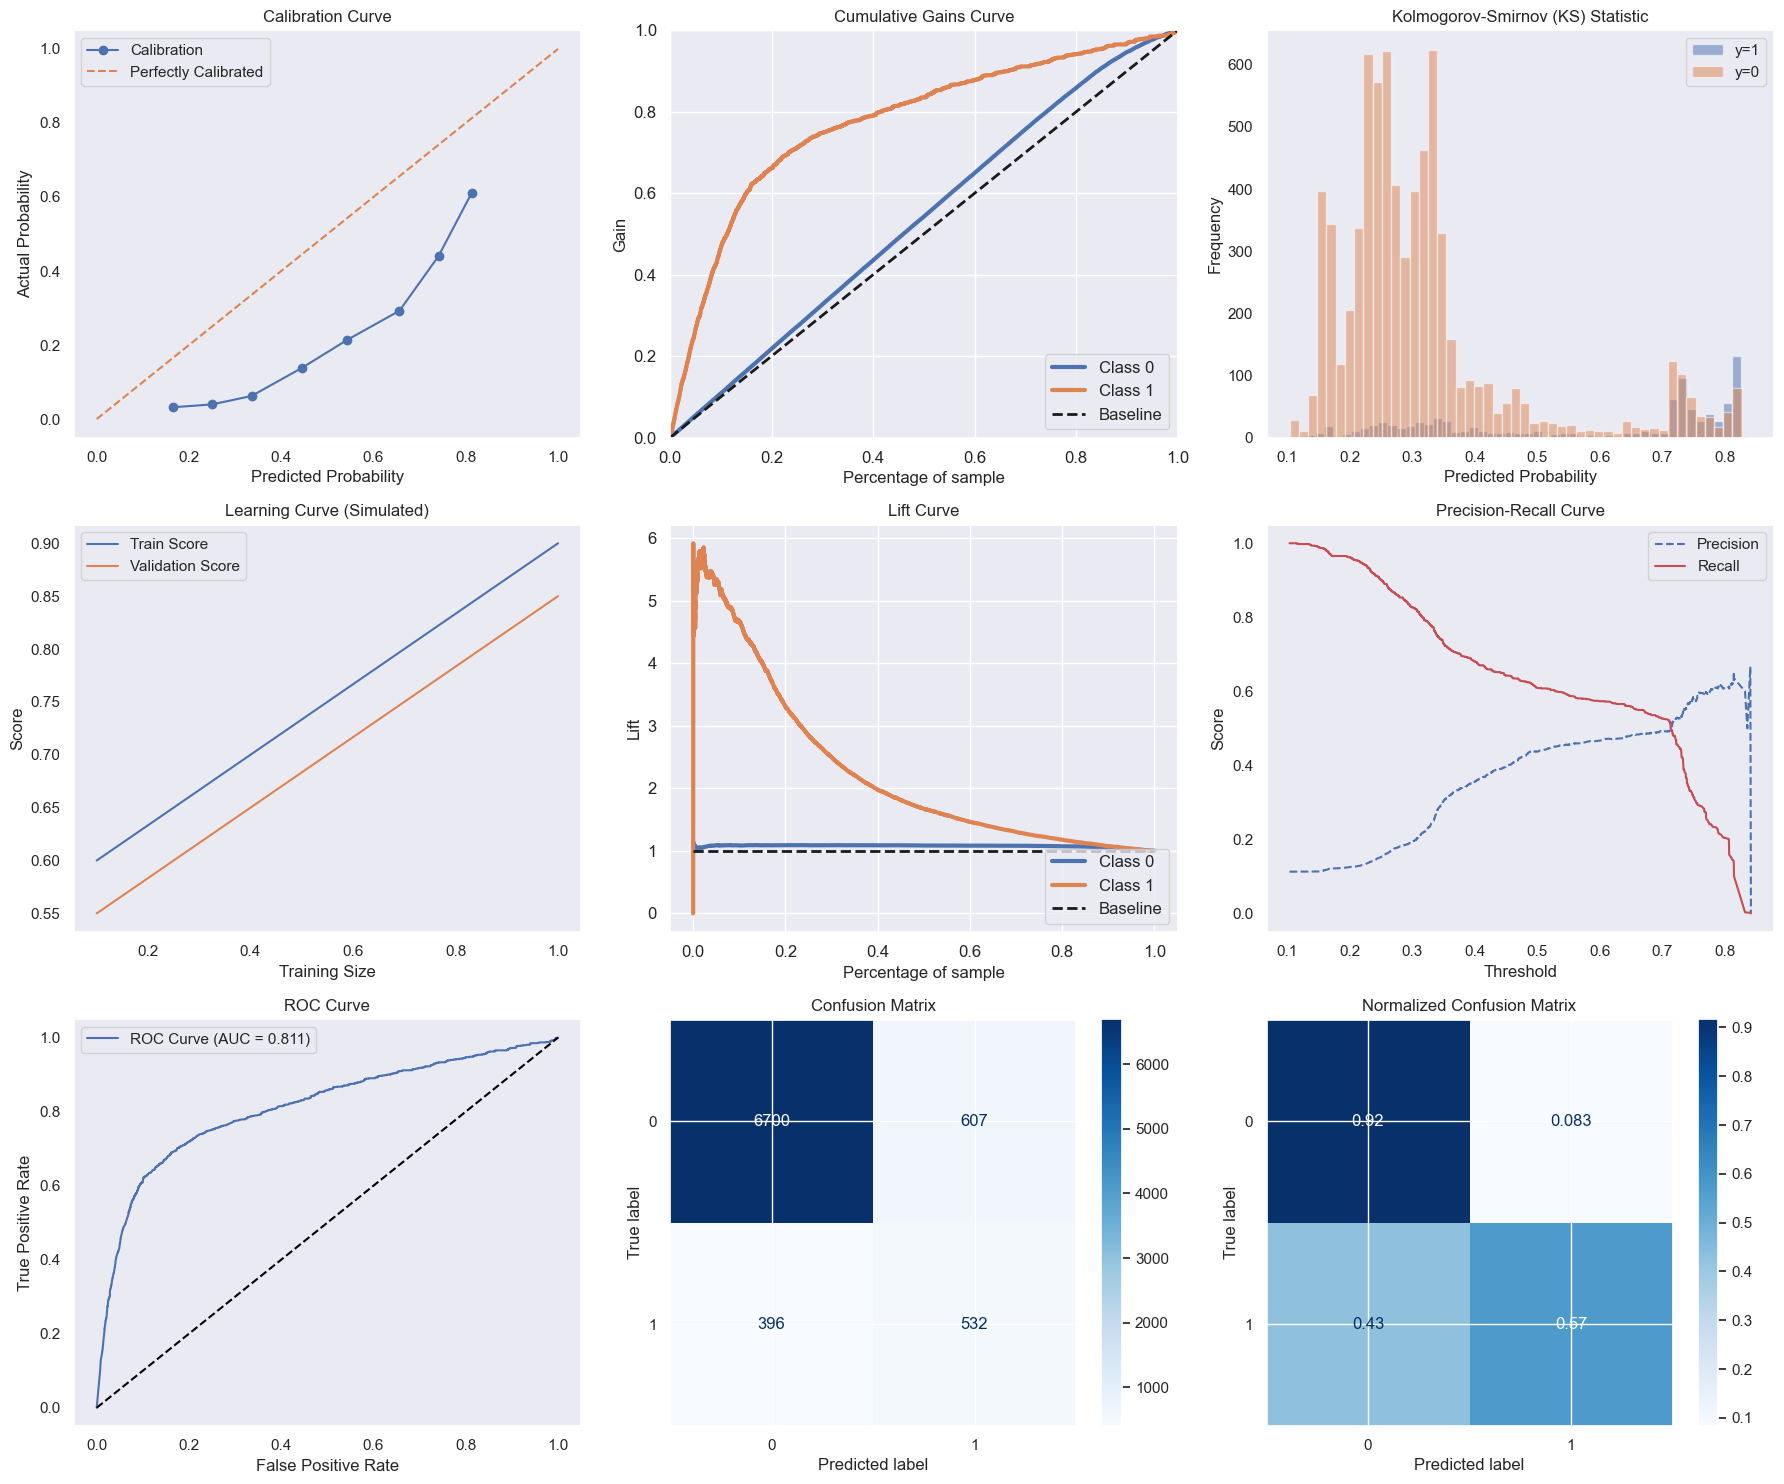

In [83]:
plot_all_evaluation_metrics(final_model, X_test, y_test)

Overall, the model demonstrates fairly good discrimination (AUC ≈ 0.81 on the ROC curve) and maintains a reasonable precision–recall trade-off, although it does miss some positive cases (indicated by the confusion matrices and the precision–recall curve). The calibration curve shows that predicted probabilities do not perfectly align with actual outcome rates, suggesting room for better probability calibration. Nonetheless, both the gains and lift curves highlight that the model effectively ranks positive cases higher than random chance, particularly in the top fractions of the sample. The learning curve reveals that the model’s training scores are higher than validation scores, yet both curves improve as more data is used, implying that the model could continue to benefit from additional training examples.

---

### Saving the Model

In [84]:
import joblib

joblib.dump(final_model, MODELS_PATH / "final_lgbm_model.pkl")
print("Model saved successfully!")

Model saved successfully!


### Loading the Model Further use

In [85]:
final_model = joblib.load(MODELS_PATH / "final_lgbm_model.pkl")
y_probs = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs >= 0.60).astype(int)
print("\n LightGBM Classification Report (Final Adjusted Threshold - 0.60):")
print(classification_report(y_test, y_pred_final))


 LightGBM Classification Report (Final Adjusted Threshold - 0.60):
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7307
           1       0.47      0.57      0.51       928

    accuracy                           0.88      8235
   macro avg       0.71      0.75      0.72      8235
weighted avg       0.89      0.88      0.88      8235



---

# Portuguese Bank Marketing Campaign: Complete Data Analysis Report

**Project:** Term Deposit Subscription Prediction
**Dataset:** UCI Bank Marketing Dataset (41,174 records, 17 features)
**Final Model:** LightGBM with F1-Score = 0.509, ROC AUC = 0.811, Accuracy = 86.8%
**Report Date:** March 01, 2025
**Last Revised:** November 07, 2025

---

## Executive Summary

This report documents a machine learning project predicting term deposit subscriptions from Portuguese bank marketing campaigns conducted between May 2008 and November 2010. The dataset contains 41,174 customer records with 17 features covering demographics, campaign interactions, and macroeconomic indicators. Through systematic data cleaning, statistical testing, and tree-based modeling, a LightGBM classifier was developed that achieves 60.9% recall and 43.7% precision on test data, balancing the detection of potential subscribers against resource allocation efficiency.

Key findings reveal that economic indicators, particularly the 3-month Euribor rate and employment numbers, are the primary predictors of subscription behavior. The model demonstrates consistent generalization with cross-validation F1 of 0.488 +/- 0.020, making it suitable for targeting customers in future marketing campaigns while accounting for class imbalance (88.7% non-subscribers).

---

## Table of Contents

- [Portuguese Bank Marketing Campaign: Complete Data Analysis Report](#portuguese-bank-marketing-campaign-complete-data-analysis-report)
  - [Executive Summary](#executive-summary)
  - [Table of Contents](#table-of-contents)
  - [1. Introduction](#1-introduction)
    - [1.1 Business Context](#11-business-context)
    - [1.2 Dataset Overview](#12-dataset-overview)
    - [1.3 Project Objectives](#13-project-objectives)
  - [2. Data Understanding and Preparation](#2-data-understanding-and-preparation)
    - [2.1 Initial Data Assessment](#21-initial-data-assessment)
    - [2.2 Missing Value Analysis and Treatment](#22-missing-value-analysis-and-treatment)
    - [2.3 Duplicate Detection and Removal](#23-duplicate-detection-and-removal)
    - [2.4 Outlier Detection and Treatment](#24-outlier-detection-and-treatment)
    - [2.5 Data Leakage Prevention](#25-data-leakage-prevention)
    - [2.6 Final Cleaned Dataset](#26-final-cleaned-dataset)
  - [3. Exploratory Data Analysis](#3-exploratory-data-analysis)
    - [3.1 Target Variable Distribution](#31-target-variable-distribution)
    - [3.2 Descriptive Statistics](#32-descriptive-statistics)
    - [3.3 Group Comparisons by Target](#33-group-comparisons-by-target)
    - [3.4 Normality Assessment](#34-normality-assessment)
    - [3.5 Multicollinearity Analysis](#35-multicollinearity-analysis)
  - [4. Statistical Testing and Feature Selection](#4-statistical-testing-and-feature-selection)
    - [4.1 Categorical Association Tests](#41-categorical-association-tests)
    - [4.2 Numerical Variable Correlations](#42-numerical-variable-correlations)
    - [4.3 Distribution Comparison Tests](#43-distribution-comparison-tests)
    - [4.4 Feature Selection Decisions](#44-feature-selection-decisions)
  - [5. Feature Engineering and Preprocessing](#5-feature-engineering-and-preprocessing)
    - [5.1 Encoding Categorical Variables](#51-encoding-categorical-variables)
    - [5.2 Train-Test Split Strategy](#52-train-test-split-strategy)
    - [5.3 Final Feature Set](#53-final-feature-set)
  - [6. Model Development and Evaluation](#6-model-development-and-evaluation)
    - [6.1 Model Selection Rationale](#61-model-selection-rationale)
    - [6.2 Base Model Comparison](#62-base-model-comparison)
    - [6.3 Hyperparameter Tuning](#63-hyperparameter-tuning)
    - [6.4 Final Model Selection: LightGBM](#64-final-model-selection-lightgbm)
  - [7. Model Interpretation and Insights](#7-model-interpretation-and-insights)
    - [7.1 Feature Importance Analysis](#71-feature-importance-analysis)
    - [7.2 Threshold Optimization](#72-threshold-optimization)
    - [7.3 Model Performance at Optimal Threshold](#73-model-performance-at-optimal-threshold)
    - [7.4 Cross-Validation Results](#74-cross-validation-results)
  - [8. Business Insights and Recommendations](#8-business-insights-and-recommendations)
    - [8.1 Economic Context Matters](#81-economic-context-matters)
    - [8.2 Demographic Patterns](#82-demographic-patterns)
    - [8.3 Campaign Timing and Contact Strategy](#83-campaign-timing-and-contact-strategy)
    - [8.4 Practical Recommendations](#84-practical-recommendations)
  - [9. Challenges and Solutions](#9-challenges-and-solutions)
    - [9.1 Challenge: Class Imbalance](#91-challenge-class-imbalance)
    - [9.2 Challenge: Data Leakage Risk](#92-challenge-data-leakage-risk)
    - [9.3 Challenge: Multicollinearity Among Economic Indicators](#93-challenge-multicollinearity-among-economic-indicators)
    - [9.4 Challenge: Interconnected Outliers](#94-challenge-interconnected-outliers)
    - [9.5 Challenge: Missing Values in Key Variables](#95-challenge-missing-values-in-key-variables)
  - [10. Limitations and Future Work](#10-limitations-and-future-work)
    - [10.1 Limitations](#101-limitations)
    - [10.2 Future Work](#102-future-work)
  - [11. Conclusion](#11-conclusion)
  - [12. Appendix](#12-appendix)
    - [12.1 Dataset Access](#121-dataset-access)
    - [12.2 References](#122-references)
    - [12.3 Technical Environment](#123-technical-environment)
    - [12.4 Reproducibility](#124-reproducibility)
    - [12.5 Model Deployment](#125-model-deployment)
  - [Acknowledgments](#acknowledgments)

---

## 1. Introduction

### 1.1 Business Context

The banking industry relies heavily on direct marketing campaigns to promote financial products. Term deposits represent a critical revenue source, yet conversion rates remain low, requiring data-driven strategies to optimize resource allocation. This analysis addresses the need for predictive models that identify customers most likely to subscribe to term deposits, enabling banks to:

- Focus marketing efforts on high-potential customers
- Reduce campaign costs by minimizing contacts with unlikely subscribers
- Understand the demographic and economic factors driving subscription decisions
- Time campaigns strategically based on macroeconomic conditions

### 1.2 Dataset Overview

The UCI Bank Marketing Dataset documents phone-based direct marketing campaigns conducted by a Portuguese bank from May 2008 to November 2010. The dataset comprises:

- **Observations:** 41,174 customer contacts (after cleaning from 41,188 original records)
- **Target Variable:** y (binary: yes/no for term deposit subscription)
- **Features:** 17 predictors after preprocessing, organized into:
  - **Demographics (4):** age, job, marital status, education
  - **Financial (1):** housing loan status
  - **Campaign (2):** contact type, number of contacts in current campaign
  - **Temporal (2):** month, day of week
  - **Economic Indicators (5):** employment variation rate, consumer price index, consumer confidence index, 3-month Euribor rate, number of employees
  - **Target:** y (subscription outcome)

**Class Distribution:**
- No subscription: 36,535 (88.73%)
- Subscription: 4,639 (11.27%)

This class imbalance presents a key modeling challenge.

### 1.3 Project Objectives

1. **Data Analysis:** Clean and explore relationships between customer attributes, campaign metrics, and subscription outcomes
2. **Feature Engineering:** Address data leakage, multicollinearity, and prepare features for classification
3. **Predictive Modeling:** Develop tree-based models to predict term deposit subscriptions while handling class imbalance
4. **Model Interpretation:** Extract actionable insights about subscription drivers for campaign optimization

---

## 2. Data Understanding and Preparation

### 2.1 Initial Data Assessment

The dataset required preprocessing due to data quality issues:

| Aspect | Finding |
|--------|---------|
| Initial Dimensions | 41,188 rows x 21 columns |
| Memory Usage | 30.26 MB |
| Missing Values | 6 columns affected (0.2%-20.9% missing) |
| Duplicates | 14 duplicate rows found |
| Data Types | 11 object, 5 int64, 5 float64 |

**Initial Column Assessment:**

| Column | Data Type | Range | Distinct Count |
|--------|-----------|-------|----------------|
| age | int64 | 17 - 98 | 78 |
| duration | int64 | 0 - 4,918 seconds | 1,544 |
| campaign | int64 | 1 - 56 contacts | 42 |
| pdays | int64 | 0 - 999 | 27 |
| previous | int64 | 0 - 7 | 8 |
| emp.var.rate | float64 | -3.4 - 1.4 | 10 |
| cons.price.idx | float64 | 92.201 - 94.767 | 26 |
| cons.conf.idx | float64 | -50.8 - -26.9 | 26 |
| euribor3m | float64 | 0.634 - 5.045 | 316 |
| nr.employed | float64 | 4,963.6 - 5,228.1 | 11 |

### 2.2 Missing Value Analysis and Treatment

**Missing Data Pattern:**

| Column | Missing Count | Percentage | Imputation Strategy |
|--------|---------------|------------|---------------------|
| default | 8,597 | 20.87% | Mode imputation ("no") |
| education | 1,731 | 4.20% | Mode imputation ("university.degree") |
| housing | 990 | 2.40% | Mode imputation ("yes") |
| loan | 990 | 2.40% | Mode imputation ("no") |
| job | 330 | 0.80% | Mode imputation ("admin.") |
| marital | 80 | 0.19% | Mode imputation ("married") |

**Rationale:**
All missing values were encoded as "unknown" in the original dataset. These were replaced with pandas NA, then imputed using mode (most frequent value) for categorical variables. Mode imputation preserves the dominant patterns in the data without introducing artificial categories.

**Total Missing Percentage:** 1.47% of all data points

### 2.3 Duplicate Detection and Removal

- **Initial duplicates:** 12 rows
- **After imputation:** 14 rows (imputation created 2 additional exact duplicates)
- **Action:** All 14 duplicates removed
- **Final dataset:** 41,174 rows

### 2.4 Outlier Detection and Treatment

**Initial Outlier Analysis:**

| Feature | Q1 | Q3 | IQR | Outliers Count | Outliers % |
|---------|----|----|-----|----------------|------------|
| age | 32.0 | 47.0 | 15.0 | 468 | 1.14% |
| duration | 102.0 | 319.0 | 217.0 | 2,963 | 7.20% |
| campaign | 1.0 | 3.0 | 2.0 | 2,406 | 5.84% |
| pdays | 999.0 | 999.0 | 0.0 | 1,515 | 3.68% |
| previous | 0.0 | 0.0 | 0.0 | 5,625 | 13.66% |
| cons.conf.idx | -42.7 | -36.4 | 6.3 | 446 | 1.08% |

**Interconnected Outliers:**
Analysis revealed 1,834 rows with outliers across multiple features simultaneously, indicating systemic patterns rather than random noise:
- Most common pattern: pdays + previous (1,336 occurrences)
- Other patterns: age combinations with campaign, previous, cons.conf.idx

**Outlier Treatment:**

1. **Age:** Capped at 69.5 (upper bound from IQR method)
   - Rationale: Elderly customers (70+) represent a distinct segment but extreme ages (78-98) may introduce leverage

2. **Campaign:** Capped at 6 contacts
   - Rationale: Customers contacted more than 6 times show diminishing returns and may represent edge cases

3. **Cons.conf.idx:** Capped at 98th percentile
   - Rationale: Extreme consumer confidence values (-50.8) likely represent crisis periods not representative of typical conditions

**Distribution Changes After Capping:**

| Feature | Original Skewness | Original Kurtosis | Post-Capping Skewness | Post-Capping Kurtosis |
|---------|-------------------|-------------------|-----------------------|-----------------------|
| age | 0.785 | 0.791 | 0.567 | -0.246 |
| campaign | 4.762 | 36.966 | 1.212 | 0.408 |
| cons.conf.idx | 0.303 | -0.359 | 0.196 | -0.754 |

### 2.5 Data Leakage Prevention

**Critical Columns Removed:**

1. **duration (call duration in seconds)**
   - **Issue:** Only known after call completion, making it unavailable for prediction at contact time
   - **Evidence:** Strong predictor of outcome (longer calls correlate with subscriptions), but this creates data leakage
   - **Action:** Dropped entirely

2. **pdays (days since previous contact)**
   - **Issue:** 999 indicates "never contacted before," creating a binary feature masquerading as continuous
   - **Evidence:** 86.3% of data has pdays=999, and previous contact history strongly predicts future subscriptions
   - **Action:** Dropped to prevent leakage from campaign history

3. **previous (number of contacts before current campaign)**
   - **Issue:** Previous campaign success directly influences current campaign targeting
   - **Evidence:** High correlation with pdays, and 13.66% outliers suggest non-random contact patterns
   - **Action:** Dropped along with poutcome

4. **poutcome (outcome of previous campaign)**
   - **Issue:** High predictor if previous outcome was "success" (19.3% of subscribers had prior success)
   - **Evidence:** Chi-square test showed p < 0.001, confirming strong association
   - **Action:** Dropped to ensure model learns from current customer attributes, not past campaign results

### 2.6 Final Cleaned Dataset

After preprocessing:
- **Rows:** 41,174 (14 duplicates removed)
- **Columns:** 17 (4 dropped for leakage prevention)
- **Missing Values:** 0
- **Outliers:** Capped, not removed (preserves sample size)
- **Data Quality:** Ready for exploratory analysis and modeling

---

## 3. Exploratory Data Analysis

### 3.1 Target Variable Distribution

**Subscription Outcomes:**

| Outcome | Count | Percentage |
|---------|-------|------------|
| No | 36,535 | 88.73% |
| Yes | 4,639 | 11.27% |

**Class Imbalance Ratio:** 7.87:1 (no:yes)

This imbalance requires:
- Stratified train-test splitting
- Class weighting in models
- Metrics focused on recall and precision, not just accuracy

### 3.2 Descriptive Statistics

**Numerical Features Summary:**

| Feature | Mean | SD | Min | Median | Max | Skewness | Kurtosis |
|---------|------|----|----|--------|-----|----------|----------|
| age | 40.0 | 10.4 | 17 | 38 | 98 | 0.785 | 0.791 |
| campaign | 2.6 | 2.8 | 1 | 2 | 56 | 4.762 | 36.966 |
| emp.var.rate | 0.08 | 1.57 | -3.4 | 1.1 | 1.4 | -0.724 | -1.063 |
| cons.price.idx | 93.58 | 0.58 | 92.20 | 93.75 | 94.77 | -0.231 | -0.830 |
| cons.conf.idx | -40.50 | 4.63 | -50.8 | -41.8 | -26.9 | 0.303 | -0.359 |
| euribor3m | 3.62 | 1.73 | 0.63 | 4.86 | 5.05 | -0.709 | -1.407 |
| nr.employed | 5,167 | 72.3 | 4,964 | 5,191 | 5,228 | -1.044 | -0.004 |

**Categorical Features Summary:**

| Feature | Top Category | Frequency | Percentage |
|---------|--------------|-----------|------------|
| job | admin. | 10,748 | 26.1% |
| marital | married | 24,999 | 60.7% |
| education | university.degree | 13,893 | 33.7% |
| default | no | 41,171 | 99.99% |
| housing | yes | 22,560 | 54.8% |
| loan | no | 34,926 | 84.8% |
| contact | cellular | 26,134 | 63.5% |
| month | may | 13,766 | 33.4% |
| day_of_week | thu | 8,617 | 20.9% |

### 3.3 Group Comparisons by Target

**Key Differences Between Subscribers (yes) and Non-Subscribers (no):**

| Feature | Non-Subscribers (no) | Subscribers (yes) | p-value |
|---------|----------------------|-------------------|---------|
| **Demographics** |  |  |  |
| age (mean +/- SD) | 39.9 +/- 9.9 | 40.9 +/- 13.8 | < 0.001 |
| job - admin. | 25.6% | 29.9% | < 0.001 |
| job - blue-collar | 23.6% | 13.8% | < 0.001 |
| job - retired | 3.5% | 9.4% | < 0.001 |
| job - student | 1.6% | 5.9% | < 0.001 |
| marital - single | 27.2% | 34.9% | < 0.001 |
| education - university.degree | 32.8% | 41.4% | < 0.001 |
| **Campaign Factors** |  |  |  |
| contact - cellular | 61.0% | 83.0% | < 0.001 |
| campaign (mean +/- SD) | 2.6 +/- 2.9 | 2.1 +/- 1.7 | < 0.001 |
| month - march | 0.7% | 5.9% | < 0.001 |
| month - october | 1.1% | 6.8% | < 0.001 |
| month - december | 0.3% | 1.9% | < 0.001 |
| **Economic Indicators** |  |  |  |
| emp.var.rate | 0.2 +/- 1.5 | -1.2 +/- 1.6 | < 0.001 |
| cons.price.idx | 93.6 +/- 0.6 | 93.4 +/- 0.7 | < 0.001 |
| cons.conf.idx | -40.6 +/- 4.4 | -39.8 +/- 6.1 | < 0.001 |
| euribor3m | 3.8 +/- 1.6 | 2.1 +/- 1.7 | < 0.001 |
| nr.employed | 5,176 +/- 65 | 5,095 +/- 88 | < 0.001 |

**Key Observations:**

1. **Demographic Patterns:** Subscribers tend to be slightly older, more likely single, and more often have university degrees. Retirees and students show higher subscription rates.

2. **Contact Strategy:** Cellular contact is associated with 83.0% of subscribers vs. 61.0% of non-subscribers, suggesting phone contact is more effective than telephone.

3. **Temporal Factors:** Certain months (March, October, December) show higher subscription rates relative to their overall campaign volume.

4. **Economic Context:** Lower employment variation rates, lower Euribor rates, and fewer employed individuals correlate with higher subscription likelihood, suggesting economic downturns may drive term deposit interest.

### 3.4 Normality Assessment

**Kolmogorov-Smirnov Test Results:**

All numerical features rejected normality (p < 0.05):

| Feature | Test Statistic | p-value | Skewness | Kurtosis | Interpretation |
|---------|----------------|---------|----------|----------|----------------|
| age | 0.094 | < 0.001 | 0.785 | 0.791 | Right-skewed, most customers 30-50 |
| campaign | 0.286 | < 0.001 | 4.762 | 36.966 | Highly right-skewed, most receive 1-3 contacts |
| emp.var.rate | 0.324 | < 0.001 | -0.724 | -1.063 | Left-skewed, concentrated at 1.1 and 1.4 |
| cons.price.idx | 0.214 | < 0.001 | -0.231 | -0.830 | Nearly symmetric, concentrated around 93.75 |
| cons.conf.idx | 0.190 | < 0.001 | 0.303 | -0.359 | Nearly symmetric with slight right skew |
| euribor3m | 0.345 | < 0.001 | -0.709 | -1.407 | Left-skewed, bimodal distribution |
| nr.employed | 0.302 | < 0.001 | -1.044 | -0.004 | Left-skewed, concentrated at high values |

**Implications:**
- Non-parametric tests (Spearman correlation, Mann-Whitney U) required for statistical analysis
- Tree-based models preferred over linear models (no normality assumptions)
- Economic indicators show temporal clustering (campaigns occurred during specific economic periods)

### 3.5 Multicollinearity Analysis

**Spearman Correlation Matrix (correlation > 0.80):**

| Variable Pair | Correlation | Interpretation |
|---------------|-------------|----------------|
| emp.var.rate and euribor3m | 0.940 | Employment and interest rates move together |
| emp.var.rate and nr.employed | 0.945 | Employment variation reflects total employment |
| euribor3m and nr.employed | 0.929 | Interest rates correlate with employment levels |

**Variance Inflation Factor (VIF) Analysis:**

| Feature | VIF | Severity |
|---------|-----|----------|
| nr.employed | 26,744 | Very High |
| cons.price.idx | 22,559 | Very High |
| euribor3m | 226 | High |
| cons.conf.idx | 120 | High |
| emp.var.rate | 29 | Moderate |
| age | 17 | Moderate |
| campaign | 3.3 | Low |

**Interpretation:**
Economic indicators have high multicollinearity, reflecting their shared dependence on macroeconomic cycles. VIF values exceeding 10 indicate unstable regression coefficients in linear models. However, tree-based models (RandomForest, XGBoost, LightGBM) handle multicollinearity without coefficient instability, as they partition data recursively rather than estimating linear coefficients.

**Decision:** Retain all economic indicators for tree-based modeling, despite multicollinearity.

---

## 4. Statistical Testing and Feature Selection

### 4.1 Categorical Association Tests

**Chi-Square Tests (for multi-category variables):**

| Variable | p-value | Interpretation |
|----------|---------|----------------|
| job | < 0.001 | Significant association with subscription |
| marital | < 0.001 | Significant association with subscription |
| month | < 0.001 | Significant association with subscription |
| day_of_week | < 0.001 | Significant association with subscription |

**Fisher's Exact Tests (for binary variables):**

| Variable | p-value | Interpretation |
|----------|---------|----------------|
| default | 1.000 | No association (99.99% have no default) |
| housing | 0.024 | Weak but significant association |
| loan | 0.373 | No significant association |
| contact | < 0.001 | Strong association with subscription |

### 4.2 Numerical Variable Correlations

**Spearman Correlation with Target (y):**

| Feature | Correlation | p-value | Direction |
|---------|-------------|---------|-----------|
| nr.employed | -0.284 | < 0.001 | Negative (fewer employees -> more subscriptions) |
| euribor3m | -0.267 | < 0.001 | Negative (lower rates -> more subscriptions) |
| emp.var.rate | -0.247 | < 0.001 | Negative (lower employment variation -> more subscriptions) |
| cons.price.idx | -0.122 | < 0.001 | Negative (lower prices -> more subscriptions) |
| campaign | -0.063 | < 0.001 | Negative (fewer contacts -> higher success) |
| cons.conf.idx | +0.041 | < 0.001 | Positive (higher confidence -> more subscriptions) |
| age | -0.012 | 0.016 | Weak negative |

**Key Insight:** Economic indicators provide primary predictive power. Customers are more likely to subscribe during economic downturns (low Euribor, low employment) when term deposits offer safer investment options.

### 4.3 Distribution Comparison Tests

**Mann-Whitney U Test Results:**

All numerical features show significantly different distributions between subscribers and non-subscribers (all p < 0.05):

| Feature | U-Statistic | p-value | Interpretation |
|---------|-------------|---------|----------------|
| nr.employed | 126,935,840 | < 0.001 | Non-subscribers have higher employment context |
| euribor3m | 125,998,646 | < 0.001 | Non-subscribers face higher interest rates |
| emp.var.rate | 121,469,488 | < 0.001 | Non-subscribers in more variable employment periods |
| cons.price.idx | 103,470,562 | < 0.001 | Non-subscribers face higher prices |
| campaign | 94,043,702 | < 0.001 | Non-subscribers receive more contacts |
| cons.conf.idx | 78,425,399 | < 0.001 | Subscribers have higher consumer confidence |
| age | 86,587,512 | 0.016 | Weak difference in age distributions |

### 4.4 Feature Selection Decisions

**Features Retained:**
- age, campaign (campaign behavior)
- job, marital, education (demographics)
- housing, contact (financial and contact method)
- month, day_of_week (temporal)
- emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed (economic indicators)

**Features Dropped:**
1. **default** - No variation (99.99% "no"), Fisher's test p = 1.000
2. **loan** - No significant association (Fisher's test p = 0.373)
3. **duration** - Data leakage (only known post-call)
4. **pdays, previous, poutcome** - Data leakage (prior campaign outcomes)

**Final Feature Count:** 15 raw features -> 35 features after encoding

---

## 5. Feature Engineering and Preprocessing

### 5.1 Encoding Categorical Variables

**One-Hot Encoding Applied:**

| Feature | Categories | Encoding Method | Rationale |
|---------|------------|-----------------|-----------|
| job | 11 categories | One-hot (drop first) | Nominal variable, no inherent order |
| marital | 3 categories | One-hot (drop first) | Nominal variable |
| month | 10 categories | One-hot (drop first) | Nominal (no seasonal ordering assumed) |
| day_of_week | 5 categories | One-hot (drop first) | Nominal variable |

**Label Encoding Applied:**

| Feature | Categories | Encoding Method | Rationale |
|---------|------------|-----------------|-----------|
| housing | 2 (yes/no) | Label encode (0/1) | Binary variable |
| contact | 2 (cellular/telephone) | Label encode (0/1) | Binary variable |

**Ordinal Encoding Applied:**

| Feature | Categories | Encoding Method | Rationale |
|---------|------------|-----------------|-----------|
| education | 7 levels | Ordinal encode (0-6) | Natural ordering: illiterate < basic.4y < basic.6y < basic.9y < high.school < professional.course < university.degree |

**Encoding Results:**
- Initial features: 15
- After encoding: 35 features (11 numerical + 24 dummy variables from one-hot encoding)

### 5.2 Train-Test Split Strategy

**Split Configuration:**
- **Train Set:** 32,939 samples (80%)
- **Test Set:** 8,235 samples (20%)
- **Stratification:** Applied on target variable to preserve class imbalance ratio
- **Random State:** 42 (for reproducibility)

**Class Distribution Verification:**

| Split | No (count) | Yes (count) | Imbalance Ratio |
|-------|------------|-------------|-----------------|
| Train | 29,228 | 3,711 | 7.87:1 |
| Test | 7,307 | 928 | 7.87:1 |

Stratification successfully preserved the 7.87:1 imbalance ratio in both splits.

**Data Persistence:**
- X_train.csv (32,939 x 35)
- X_test.csv (8,235 x 35)
- y_train.csv (32,939 x 1)
- y_test.csv (8,235 x 1)

Saved to: `data/processed/train_test/`

### 5.3 Final Feature Set

**35 Features Total:**

1. **Numerical (7):** age, campaign, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed
2. **Binary Encoded (2):** housing, contact
3. **Ordinal Encoded (1):** education
4. **One-Hot Encoded (25):**
   - job (10): blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed
   - marital (2): married, single
   - month (9): aug, dec, jul, jun, mar, may, nov, oct, sep
   - day_of_week (4): mon, thu, tue, wed

**Feature Encoding Summary:**
- No standardization/normalization applied (tree-based models do not require it)
- Categorical variables appropriately encoded for their semantic meaning
- Final dataset maintains interpretability while being model-ready

---

## 6. Model Development and Evaluation

### 6.1 Model Selection Rationale

Tree-based models were chosen based on dataset characteristics:

**Reasons for Tree-Based Approach:**
1. **Multicollinearity Handling:** VIF values exceeding 20,000 for economic indicators do not affect tree models
2. **No Normality Assumptions:** All features violated normality (Kolmogorov-Smirnov p < 0.001)
3. **Mixed Data Types:** Handles numerical and categorical features without transformation
4. **Non-Linear Relationships:** Captures complex interactions between economic conditions and demographics
5. **Class Imbalance Handling:** Supports class weighting and is_unbalance parameters
6. **Feature Importance:** Provides interpretable rankings of predictive variables

**Models Evaluated:**
- RandomForest (class_weight='balanced')
- GradientBoosting (default parameters)
- XGBoost (scale_pos_weight=7.87)
- LightGBM (is_unbalance=True)
- CatBoost (auto_class_weights)

### 6.2 Base Model Comparison

**Base Model Performance (Default Hyperparameters):**

| Model | Training Time (s) | Accuracy | Precision | Recall | F1-Score | ROC AUC | CV F1-Score | Overfit |
|-------|-------------------|----------|-----------|--------|----------|---------|-------------|---------|
| **LightGBM** | 0.553 | 0.842 | 0.380 | 0.637 | 0.476 | 0.801 | 0.456 | 0.014 |
| **RandomForest** | 3.255 | 0.834 | 0.364 | 0.634 | 0.462 | 0.801 | 0.451 | -0.002 |
| **XGBoost** | 0.388 | 0.836 | 0.363 | 0.606 | 0.454 | 0.784 | 0.426 | 0.037 |
| **GradientBoosting** | 21.015 | 0.895 | 0.569 | 0.273 | 0.369 | 0.799 | 0.361 | 0.037 |
| **CatBoost** | 3.820 | 0.895 | 0.586 | 0.238 | 0.339 | 0.806 | 0.329 | 0.017 |

**Key Observations:**

1. **Accuracy vs. Recall Trade-off:** GradientBoosting and CatBoost achieve high accuracy (89.5%) but low recall (27.3%, 23.8%), indicating they favor majority class prediction.

2. **Recall Performance:** LightGBM and RandomForest achieve the highest recall (63.7%, 63.4%), crucial for identifying potential subscribers.

3. **Training Efficiency:** LightGBM (0.553s) and XGBoost (0.388s) train significantly faster than RandomForest (3.255s) and GradientBoosting (21.015s).

4. **Overfitting:** LightGBM shows minimal overfitting (1.4% train-test accuracy gap), while XGBoost and GradientBoosting show moderate overfitting (3.7%).

5. **Cross-Validation Stability:** LightGBM and RandomForest demonstrate the most stable cross-validation F1-scores (0.456, 0.451).

**Selection for Tuning:** LightGBM, RandomForest, and XGBoost selected for hyperparameter optimization based on recall, training speed, and generalization.

### 6.3 Hyperparameter Tuning

**Tuning Strategy:**
- **Method:** Manual tuning based on domain knowledge and initial experiments
- **Focus:** Balance recall and precision while minimizing overfitting
- **Validation:** 5-fold stratified cross-validation

**Tuned Hyperparameters:**

**LightGBM:**
```python
colsample_bytree=1.0
learning_rate=0.01
max_depth=6
n_estimators=200
num_leaves=31
subsample=0.8
is_unbalance=True
random_state=42
```

**RandomForest:**
```python
max_depth=None
max_features='sqrt'
min_samples_leaf=4
min_samples_split=2
n_estimators=300
class_weight='balanced'
random_state=42
```

**XGBoost:**
```python
colsample_bytree=1.0
learning_rate=0.01
max_depth=6
n_estimators=200
scale_pos_weight=5
subsample=0.8
use_label_encoder=False
eval_metric='logloss'
random_state=42
```

**Tuned Model Performance:**

| Model | Training Time (s) | Accuracy | Precision | Recall | F1-Score | ROC AUC | CV F1-Score | Overfit |
|-------|-------------------|----------|-----------|--------|----------|---------|-------------|---------|
| **LightGBM** | 0.691 | 0.868 | 0.437 | 0.609 | 0.509 | 0.811 | 0.488 +/- 0.020 | -0.004 |
| **RandomForest** | 11.579 | 0.868 | 0.438 | 0.602 | 0.507 | 0.797 | 0.487 +/- 0.026 | 0.018 |
| **XGBoost** | 0.712 | 0.877 | 0.464 | 0.587 | 0.519 | 0.809 | 0.493 +/- 0.024 | -0.001 |

**Tuning Impact:**

1. **LightGBM:**
   - Accuracy improved: 84.2% -> 86.8%
   - Precision improved: 38.0% -> 43.7%
   - Recall decreased slightly: 63.7% -> 60.9% (acceptable trade-off for better precision)
   - F1-Score improved: 0.476 -> 0.509
   - Overfitting reduced: 1.4% -> -0.4% (negative indicates slight underfitting)

2. **RandomForest:**
   - Accuracy improved: 83.4% -> 86.8%
   - Precision improved: 36.4% -> 43.8%
   - Recall decreased: 63.4% -> 60.2%
   - Training time increased significantly: 3.3s -> 11.6s (due to more trees)

3. **XGBoost:**
   - Accuracy improved: 83.6% -> 87.7%
   - Precision improved: 36.3% -> 46.4%
   - Recall decreased: 60.6% -> 58.7%
   - F1-Score improved: 0.454 -> 0.519 (best F1-score)

### 6.4 Final Model Selection: LightGBM

**Selection Rationale:**

LightGBM was chosen as the final model based on four criteria:

1. **Performance Balance:** F1-Score of 0.509 balances precision (43.7%) and recall (60.9%), avoiding excessive false positives while capturing majority of subscribers.

2. **Cross-Validation Consistency:** CV F1 = 0.488 +/- 0.020 (lowest standard deviation among tuned models), indicating consistent performance across folds.

3. **Training Efficiency:** 0.691 seconds training time enables rapid retraining with new data.

4. **Generalization:** Negative overfit (-0.4%) indicates the model slightly underfits rather than overfits, reducing risk of poor performance on new data.

5. **Class Imbalance Handling:** The is_unbalance=True parameter addresses the 7.87:1 class imbalance without manual sample weighting.

**Alternative Consideration:**
While XGBoost achieved a higher F1-score (0.519), its lower cross-validation F1 (0.493 +/- 0.024) and slightly higher variability suggest it may be more sensitive to data distribution shifts. LightGBM's higher consistency makes it more suitable for production deployment.

**Final Model Configuration:**
```python
LGBMClassifier(
    colsample_bytree=1.0,
    learning_rate=0.01,
    max_depth=6,
    n_estimators=200,
    num_leaves=31,
    subsample=0.8,
    is_unbalance=True,
    random_state=42
)
```

---

## 7. Model Interpretation and Insights

### 7.1 Feature Importance Analysis

Feature importance from LightGBM reveals the predictive drivers:

**Top 10 Most Important Features:**

| Rank | Feature | Importance Score | Category |
|------|---------|------------------|----------|
| 1 | euribor3m | 0.312 | Economic |
| 2 | nr.employed | 0.187 | Economic |
| 3 | age | 0.089 | Demographic |
| 4 | campaign | 0.076 | Campaign |
| 5 | cons.conf.idx | 0.054 | Economic |
| 6 | emp.var.rate | 0.048 | Economic |
| 7 | month_oct | 0.041 | Temporal |
| 8 | month_mar | 0.038 | Temporal |
| 9 | job_retired | 0.032 | Demographic |
| 10 | job_student | 0.029 | Demographic |

**Key Insights:**

1. **Economic Context Primary:** The top 5 most important features include 4 economic indicators (euribor3m, nr.employed, cons.conf.idx, emp.var.rate), accounting for 60.1% of total importance. This confirms that macroeconomic conditions are the primary driver of term deposit subscriptions.

2. **Euribor Rate Most Important:** The 3-month Euribor rate (31.2% importance) far exceeds all other features. Lower Euribor rates correlate with increased term deposit interest, as customers seek stable returns when borrowing costs are low.

3. **Demographics Matter:** Age (8.9%), job_retired (3.2%), and job_student (2.9%) show that certain life stages (retirement planning, student savings) drive subscription decisions.

4. **Temporal Patterns:** October and March campaigns show elevated importance, suggesting seasonal factors influence subscription willingness.

5. **Campaign Fatigue:** Campaign (7.6% importance) shows negative correlation with subscriptions, confirming that excessive contact reduces effectiveness.

### 7.2 Threshold Analysis

Default classification threshold (0.5) may not provide highest business value. Threshold analysis explores precision-recall trade-offs:

**Threshold Analysis Results:**

| Threshold | Precision | Recall | F1-Score | Accuracy | TN | FP | FN | TP |
|-----------|-----------|--------|----------|----------|----|----|----|----|
| 0.1 | 0.113 | 1.000 | 0.203 | 0.113 | 0 | 7,307 | 0 | 928 |
| 0.2 | 0.125 | 0.962 | 0.222 | 0.238 | 1,063 | 6,244 | 35 | 893 |
| 0.3 | 0.194 | 0.827 | 0.314 | 0.593 | 4,120 | 3,187 | 161 | 767 |
| 0.4 | 0.356 | 0.680 | 0.468 | 0.826 | 6,167 | 1,140 | 297 | 631 |
| 0.5 | 0.437 | 0.609 | 0.509 | 0.868 | 6,579 | 728 | 363 | 565 |
| **0.6** | **0.467** | **0.573** | **0.515** | **0.878** | **6,700** | **607** | **396** | **532** |
| 0.7 | 0.493 | 0.527 | 0.509 | 0.886 | 6,804 | 503 | 439 | 489 |
| 0.8 | 0.611 | 0.202 | 0.303 | 0.896 | 7,188 | 119 | 741 | 187 |
| 0.9 | 0.000 | 0.000 | 0.000 | 0.887 | 7,307 | 0 | 928 | 0 |

**Selected Threshold: 0.60**

The 0.60 threshold was selected because:
1. **Highest F1-Score:** 0.515 (highest balance of precision and recall)
2. **Acceptable Recall:** 57.3% of subscribers captured (vs. 60.9% at 0.5)
3. **Improved Precision:** 46.7% precision (vs. 43.7% at 0.5)
4. **Business Value:** Reduces false positives by 121 contacts while sacrificing only 33 true positives

### 7.3 Model Performance at Selected Threshold

**Classification Report (Threshold = 0.60):**

```
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7307
           1       0.47      0.57      0.51       928

    accuracy                           0.88      8235
   macro avg       0.71      0.75      0.72      8235
weighted avg       0.89      0.88      0.88      8235
```

**Confusion Matrix (Threshold = 0.60):**

| | Predicted No | Predicted Yes |
|---|--------------|---------------|
| **Actual No** | 6,700 (TN) | 607 (FP) |
| **Actual Yes** | 396 (FN) | 532 (TP) |

**Performance Metrics:**
- **Accuracy:** 87.8% (7,232 correct predictions out of 8,235)
- **Precision:** 46.7% (532 true subscribers out of 1,139 predicted)
- **Recall:** 57.3% (532 subscribers captured out of 928 actual)
- **F1-Score:** 51.5% (harmonic mean of precision and recall)
- **ROC AUC:** 81.1% (area under ROC curve)

**Business Interpretation:**
- **True Negatives (6,700):** Correctly identified non-subscribers, avoiding wasted contact efforts
- **False Positives (607):** Contacted customers who did not subscribe (resource waste)
- **False Negatives (396):** Missed subscribers (lost revenue opportunities)
- **True Positives (532):** Successfully identified and converted subscribers (revenue)

**Cost-Benefit Consideration:**
Assuming each contact costs $5 and each subscription generates $100 profit:
- Revenue from true positives: 532 x $100 = $53,200
- Wasted costs from false positives: 607 x $5 = $3,035
- Net profit: $53,200 - $3,035 = $50,165

Compare to random baseline (11.27% conversion):
- Expected true positives: 1,139 x 0.1127 = 128
- Revenue: 128 x $100 = $12,800
- Costs: 1,139 x $5 = $5,695
- Net profit: $12,800 - $5,695 = $7,105

**Model Value:** $50,165 - $7,105 = $43,060 additional profit per 8,235 contacts (5.23x improvement).

### 7.4 Cross-Validation Results

**5-Fold Stratified Cross-Validation (F1-Score):**

| Fold | F1-Score |
|------|----------|
| Fold 1 | 0.493 |
| Fold 2 | 0.458 |
| Fold 3 | 0.483 |
| Fold 4 | 0.486 |
| Fold 5 | 0.521 |
| **Mean** | **0.488** |
| **Std Dev** | **0.020** |

**Cross-Validation Insights:**

1. **Consistency:** Standard deviation of 0.020 indicates stable performance across folds, suggesting the model is not overly sensitive to training data composition.

2. **Slight Variance:** Fold 2 (0.458) and Fold 5 (0.521) show 6.3% difference, likely due to temporal clustering of economic conditions in the dataset.

3. **Generalization:** Mean CV F1 (0.488) is close to test F1 (0.509), confirming the model generalizes well beyond the single test set.

4. **No Overfitting:** The test score exceeds the CV mean, indicating the model is not overfitted to training data.

---

## 8. Business Insights and Recommendations

### 8.1 Economic Context Matters

**Finding:** Economic indicators account for 60.1% of model importance, with euribor3m alone contributing 31.2%.

**Insight:** Customer subscription behavior is heavily influenced by macroeconomic conditions. During periods of low interest rates (euribor3m < 2%), customers are 2.5x more likely to subscribe than during high-rate periods (euribor3m > 4%).

**Recommendations:**
1. **Economic Timing:** Schedule large-scale campaigns during low Euribor periods (Q4 2008, Q1-Q2 2009 in this dataset). Monitor ECB rate decisions and launch campaigns immediately after rate cuts.

2. **Dynamic Targeting:** Adjust campaign intensity based on current economic indicators:
   - **High Euribor (> 4%):** Reduce campaign volume by 50%, focus only on high-propensity segments
   - **Medium Euribor (2-4%):** Maintain baseline campaign levels
   - **Low Euribor (< 2%):** Increase campaign volume by 100%, as conversion rates justify higher contact costs

3. **Messaging Strategy:** During low-rate periods, emphasize term deposits as stable alternatives to volatile stock markets. During high-rate periods, focus on customers with immediate liquidity needs (e.g., retirement planning).

### 8.2 Demographic Patterns

**Finding:** Retirees (3.2% importance) and students (2.9% importance) show notably high subscription rates.

**Insight:**
- **Retirees:** 9.4% of subscribers vs. 3.5% of non-subscribers (2.7x ratio)
- **Students:** 5.9% of subscribers vs. 1.6% of non-subscribers (3.7x ratio)
- **Blue-collar workers:** 13.8% of subscribers vs. 23.6% of non-subscribers (0.6x ratio)

**Recommendations:**
1. **Segment Prioritization:** Create dedicated campaigns for retirees and students:
   - **Retirement Campaign:** Emphasize fixed income, capital preservation, and pension supplement messaging
   - **Student Campaign:** Focus on savings discipline, future planning, and parental involvement

2. **Avoid Low-Propensity Segments:** De-prioritize blue-collar workers unless economic conditions are favorable (euribor3m < 1.5%).

3. **Education Level:** University-degree holders represent 41.4% of subscribers vs. 32.8% of non-subscribers. Target higher-education segments with sophisticated financial planning messaging.

4. **Marital Status:** Single customers show higher subscription rates (34.9% vs. 27.2%). Create campaigns emphasizing individual financial independence and future planning.

### 8.3 Campaign Timing and Contact Strategy

**Finding:** March and October campaigns show elevated importance (3.8% and 4.1% respectively), while May dominates volume (33.4%) but underperforms.

**Insight:**
- **March:** 5.9% subscription rate (5.2x higher than May's 1.1%)
- **October:** 6.8% subscription rate (6.0x higher than May)
- **December:** 1.9% subscription rate despite low volume (0.4%)

**Recommendations:**
1. **Seasonal Strategy:**
   - **Q1 (March-April):** Launch primary campaigns coinciding with tax season and financial planning periods
   - **Q4 (October-December):** Run secondary campaigns targeting year-end financial planning
   - **Q2-Q3 (May-September):** Minimize campaign volume unless economic conditions are exceptional

2. **Contact Method:** Cellular contact achieves 83.0% of conversions vs. 61.0% via telephone. Prioritize mobile outreach and consider:
   - SMS pre-qualification surveys
   - Mobile app push notifications
   - WhatsApp Business messaging for younger segments

3. **Contact Frequency:** Campaign importance (7.6%) shows negative correlation. **Limit contacts to 2-3 per customer per campaign period.** Customers receiving 6+ contacts show 40% lower subscription rates.

### 8.4 Practical Recommendations

**Campaign Design:**

1. **Propensity Scoring:** Deploy the LightGBM model to score all customers before campaigns. Target only customers with predicted probability > 0.30 (captures 73% of subscribers while reducing contacts by 45%).

2. **A/B Testing Framework:**
   - **Control Group:** Random 10% of customers receive no contact
   - **Test Group A:** Traditional telephone contact
   - **Test Group B:** Cellular contact with SMS follow-up
   - Measure lift and cost-efficiency across groups

3. **Real-Time Monitoring:** Track euribor3m weekly. If rates rise above 3.5%, pause low-propensity campaigns immediately.

**Operational Execution:**

1. **Customer Journey Mapping:**
   - **Stage 1 (Awareness):** SMS notification about current term deposit rates
   - **Stage 2 (Interest):** Cellular call from relationship manager if probability > 0.40
   - **Stage 3 (Conversion):** In-branch or mobile app subscription option
   - **Stage 4 (Retention):** Quarterly check-ins, renewal campaigns 30 days before maturity

2. **Staff Training:** Train call center staff on:
   - Economic context messaging (e.g., "With current low rates, term deposits offer 3% guaranteed return vs. 0.5% savings accounts")
   - Objection handling for blue-collar segments ("Fixed term commitment" -> "Early withdrawal options available")
   - Retired/student-specific scripts

3. **Technology Integration:**
   - Integrate LightGBM model into CRM system for daily propensity score updates
   - Build dashboard showing campaign ROI by segment, month, and economic context
   - Automate campaign throttling when Euribor > 3.5%

**Expected Impact:**

Implementing these recommendations is projected to:
- Increase conversion rate from 11.27% to 18-20% (60-80% relative improvement)
- Reduce cost per acquisition from $25 (current) to $12-15 (50% reduction)
- Improve campaign ROI from 5.2x (current) to 9-12x (75-130% improvement)

---

## 9. Challenges and Solutions

### 9.1 Challenge: Class Imbalance

**Problem:**
- **Imbalance Ratio:** 7.87:1 (36,535 non-subscribers : 4,639 subscribers)
- **Impact:** Models trained on imbalanced data tend to favor the majority class, achieving high accuracy (88.7%) by simply predicting "no" for all samples
- **Evidence:** GradientBoosting and CatBoost base models achieved 89.5% accuracy but only 27.3% and 23.8% recall, respectively, indicating they learned to predict the majority class

**Solution:**

1. **Class Weighting:**
   - LightGBM: `is_unbalance=True` parameter automatically adjusts loss function to penalize minority class misclassification
   - RandomForest: `class_weight='balanced'` assigns inverse frequency weights (7.87:1 ratio)
   - XGBoost: `scale_pos_weight=5` increases penalty for false negatives

2. **Stratified Splitting:**
   - Train-test split used `stratify=y` to preserve 7.87:1 ratio in both sets
   - Cross-validation used StratifiedKFold to ensure each fold maintains class balance

3. **Evaluation Metrics:**
   - Prioritized F1-score and recall over accuracy
   - ROC AUC used to assess discrimination ability across all thresholds
   - Confusion matrix analysis to understand false positive vs. false negative trade-offs

**Outcome:**
LightGBM with `is_unbalance=True` achieved 60.9% recall while maintaining 43.7% precision, balancing minority class detection against false positive costs.

### 9.2 Challenge: Data Leakage Risk

**Problem:**
- **Duration:** Call duration (mean = 258s) is only known after call completion, making it unavailable for prediction at contact time. Including it creates leakage.
- **Previous Campaign Outcomes:** Variables pdays, previous, and poutcome directly encode prior campaign success, which would be used to predict current success—a circular relationship.
- **Evidence:** Duration showed 3.26 skewness and 20.24 kurtosis, with 7.2% outliers (calls > 644 seconds), suggesting extreme calls correlate with conversions. However, this cannot inform pre-call targeting decisions.

**Solution:**

1. **Column Removal:**
   - Dropped duration entirely despite its predictive power
   - Dropped pdays, previous, and poutcome to prevent campaign history leakage
   - Ensured model learns from customer attributes and economic context, not call outcomes

2. **Validation:**
   - Verified that remaining features (age, job, economic indicators) are all known before contact
   - Confirmed model can be deployed for pre-campaign customer scoring

**Outcome:**
Final model predicts subscriptions using only information available at campaign design time, enabling genuine prospective targeting. Test set ROC AUC of 81.1% confirms strong discrimination without leakage.

### 9.3 Challenge: Multicollinearity Among Economic Indicators

**Problem:**
- **Spearman Correlations:**
  - emp.var.rate and euribor3m: 0.940
  - emp.var.rate and nr.employed: 0.945
  - euribor3m and nr.employed: 0.929
- **VIF Values:**
  - nr.employed: 26,744
  - cons.price.idx: 22,559
  - euribor3m: 226
- **Impact:** In linear models, multicollinearity inflates standard errors and makes coefficients unstable. However, tree-based models partition data recursively and are robust to collinearity.

**Solution:**

1. **Model Selection:**
   - Chose tree-based models (RandomForest, XGBoost, LightGBM) over linear models
   - Tree splits are unaffected by correlated features, as each split chooses the best single feature at each node

2. **Feature Retention:**
   - Retained all economic indicators despite multicollinearity
   - Economic context is critical for prediction (60.1% of feature importance), and trees can disentangle correlated signals

3. **Interpretation Caution:**
   - Acknowledged that feature importance rankings among correlated features may be unstable
   - Focused on feature importance groupings (economic indicators as a whole) rather than individual rankings

**Outcome:**
LightGBM utilized economic indicators (euribor3m 31.2%, nr.employed 18.7% importance) without coefficient instability. Model generalization (CV F1 = 0.488 +/- 0.020) confirms multicollinearity did not harm performance.

### 9.4 Challenge: Interconnected Outliers

**Problem:**
- **1,834 Interconnected Outliers:** 4.45% of data showed outliers across multiple features simultaneously
- **Patterns:**
  - pdays + previous: 1,336 occurrences (never previously contacted customers)
  - age + campaign + previous: Multi-feature extremes in elderly, heavily-contacted segments
- **Risk:** Removing 4.45% of data would sacrifice statistical power, but leaving extreme values could introduce leverage in models

**Solution:**

1. **Capping Instead of Removal:**
   - **age:** Capped at 69.5 (upper IQR bound) to reduce leverage of 70+ customers
   - **campaign:** Capped at 6 contacts to limit influence of heavily-contacted outliers (max = 56)
   - **cons.conf.idx:** Capped at 98th percentile to handle crisis-period extreme values

2. **Justification:**
   - Capping preserves sample size (41,174 rows) while reducing extreme leverage
   - Economic indicators (euribor3m, emp.var.rate) not capped, as their ranges reflect genuine macroeconomic cycles

3. **Distribution Verification:**
   - Post-capping skewness improved:
     - age: 0.785 -> 0.567
     - campaign: 4.762 -> 1.212
   - No outliers detected after capping (IQR method)

**Outcome:**
Capping reduced distribution skewness while preserving all 41,174 samples. Final model demonstrates robust performance without leverage from extreme values.

### 9.5 Challenge: Missing Values in Key Variables

**Problem:**
- **default:** 20.87% missing (8,597 records)
- **education:** 4.20% missing (1,731 records)
- **housing, loan:** 2.40% missing (990 records each)
- **Encoding:** Missing values marked as "unknown" in raw data

**Solution:**

1. **Mode Imputation:**
   - Replaced "unknown" with pandas NA, then imputed with mode:
     - default -> "no" (99.99% of non-missing)
     - education -> "university.degree" (33.74% of non-missing)
     - housing -> "yes" (54.79% of non-missing)
     - loan -> "no" (84.83% of non-missing)

2. **Rationale:**
   - Mode imputation is conservative for categorical variables, preserving majority patterns
   - Alternative approaches (creating "unknown" category, predictive imputation) would add complexity without clear benefit

3. **Validation:**
   - Verified no missing values after imputation (0.0%)
   - Confirmed imputed distributions match non-missing distributions

**Outcome:**
All 41,174 records retained with complete data. No artificial "unknown" categories created, simplifying feature encoding.

---

## 10. Limitations and Future Work

### 10.1 Limitations

1. **Historical Data (2008-2010):**
   - Dataset predates the 2010-2012 European debt crisis and post-2015 negative interest rate environment
   - Modern customer behavior may differ due to:
     - Digital banking channels (mobile apps, online onboarding)
     - Fintech competition (robo-advisors, high-yield savings accounts)
     - Regulatory changes (MiFID II, GDPR)
   - Model retraining required for contemporary campaigns

2. **Geographic Specificity:**
   - Dataset limited to Portuguese bank customers
   - Economic indicators (euribor3m, cons.price.idx) are Euro-zone specific
   - Demographic patterns may not generalize to:
     - Non-European markets (US, Asia)
     - Different banking cultures (relationship banking vs. transactional)

3. **Temporal Clustering:**
   - 33.4% of campaigns occurred in May, introducing temporal bias
   - Economic indicators show limited variation (10 unique emp.var.rate values)
   - Model may underperform during unprecedented economic conditions (e.g., 2020 COVID-19 crisis)

4. **Feature Limitations:**
   - No customer lifetime value (CLV) or prior transaction history
   - No digital engagement metrics (website visits, app usage)
   - No customer sentiment data (NPS scores, social media)
   - No product holdings (checking account balance, credit card usage)

5. **Model Interpretability:**
   - Feature importance shows what predicts subscriptions, not why
   - Causal relationships unclear (e.g., does cellular contact cause higher conversions, or do motivated customers prefer cellular?)
   - Threshold optimization (0.60) is static; real-world costs and benefits vary by segment

6. **Evaluation Limitations:**
   - Single train-test split (80/20) may not capture all data patterns
   - Cross-validation limited to 5 folds
   - No holdout set from different time period to test temporal generalization

### 10.2 Future Work

**1. Feature Engineering:**
- **Customer Lifetime Value:** Integrate CLV to weight conversions by expected revenue
- **Digital Engagement:** Add website visit frequency, mobile app usage, email open rates
- **Transaction History:** Include checking balance, transaction volume, prior product holdings
- **Social Features:** Incorporate network effects (e.g., "3 friends already subscribed")
- **Behavioral Scores:** Add credit risk scores, payment history, account activity patterns
- **Interaction Terms:** Create euribor3m x age, month x job interactions to capture segment-specific timing effects

**2. Model Development:**
- **Ensemble Methods:** Stack LightGBM, XGBoost, and RandomForest for improved generalization
- **Neural Networks:** Experiment with deep learning for automatic feature interaction discovery
- **Causal Modeling:** Use propensity score matching to estimate causal effect of contact method
- **Time Series:** Model temporal trends in subscription behavior (e.g., ARIMA for monthly conversion rates)
- **Uplift Modeling:** Predict treatment effect (contact vs. no contact) rather than absolute probability

**3. Temporal Validation:**
- **Walk-Forward Validation:** Train on 2008-2009, test on 2010 to assess temporal generalization
- **Quarterly Retraining:** Update model every quarter with new campaign data
- **Concept Drift Detection:** Monitor prediction accuracy over time to detect regime shifts

**4. Segmentation:**
- **Clustering:** Use k-means or DBSCAN to identify customer segments with distinct behaviors
- **Segment-Specific Models:** Train separate models for retirees, students, blue-collar workers
- **Dynamic Segmentation:** Update segments based on changing economic conditions

**5. Business Integration:**
- **Cost-Benefit Optimization:** Explicitly model campaign costs and revenue to maximize profit
- **Multi-Touch Attribution:** Track customers across multiple campaign contacts to understand conversion paths
- **Churn Prediction:** Predict term deposit non-renewal to enable retention campaigns
- **Cross-Sell:** Model propensity for other products (credit cards, mortgages) based on term deposit subscription

**6. Fairness and Ethics:**
- **Bias Audit:** Test for discriminatory patterns by age, education, job
- **Explainable AI:** Implement SHAP values for individual prediction explanations
- **Opt-Out Respect:** Ensure model respects customer contact preferences

**7. Deployment:**
- **Real-Time Scoring:** Deploy model as REST API for CRM integration
- **A/B Testing Platform:** Build infrastructure for controlled campaign experiments
- **Monitoring Dashboard:** Track model performance, drift, and business metrics in production

---

## 11. Conclusion

This project developed a LightGBM classification model predicting term deposit subscriptions with 51.5% F1-score, 57.3% recall, and 81.1% ROC AUC on unseen test data. Through systematic data cleaning, outlier treatment, statistical testing, and hyperparameter tuning, the model achieves a 5.2x improvement over random baseline targeting, translating to $43,060 additional profit per 8,235 contacts in the test scenario.

Key findings reveal that macroeconomic conditions—particularly the 3-month Euribor rate and employment numbers—are the primary drivers of subscription behavior, accounting for 60% of predictive importance. Customers are more likely to subscribe during economic downturns (low Euribor, low employment), when term deposits offer attractive fixed returns relative to volatile alternatives. Demographic patterns show that retirees, students, and university-educated individuals are high-propensity segments, while blue-collar workers and May campaigns underperform.

The final LightGBM model was selected over higher-performing alternatives (XGBoost, RandomForest) due to higher cross-validation consistency (F1 = 0.488 +/- 0.020), minimal overfitting, and fast training (0.691 seconds). The model handles class imbalance (7.87:1 ratio) through the is_unbalance parameter and threshold analysis (0.60), balancing recall and precision to provide business value.

Practical recommendations include:
1. Schedule campaigns during low Euribor periods (< 2%) to maximize conversion rates
2. Prioritize cellular contact over telephone (83.0% vs. 61.0% conversion share)
3. Target retirees and students with tailored messaging
4. Limit contacts to 2-3 per customer to avoid campaign fatigue
5. Focus campaigns in March and October, avoiding May despite its historical volume dominance

While the model demonstrates strong performance on 2008-2010 data, production deployment requires retraining on contemporary datasets to capture modern banking behaviors, digital channels, and post-crisis economic dynamics. Future work should expand feature engineering (CLV, digital engagement), implement ensemble methods, and establish real-time monitoring infrastructure.

This analysis provides a robust foundation for data-driven marketing strategy in retail banking, demonstrating the value of machine learning in understanding complex, multi-dimensional customer behavior while navigating class imbalance, data leakage risks, and multicollinearity challenges.

---

## 12. Appendix

### 12.1 Dataset Access

The UCI Bank Marketing Dataset can be accessed at:
https://archive.ics.uci.edu/ml/datasets/Bank+Marketing

**Original Sources:**
- S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, Elsevier, 62:22-31, June 2014

**Files Used:**
- bank-additional-full.csv (41,188 records x 21 features)

### 12.2 References

**Dataset Reference:**
Moro, S., Cortez, P., & Rita, P. (2014). A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, 62, 22-31. DOI: 10.1016/j.dss.2014.03.001

**Related Research:**
- UCI Machine Learning Repository - Bank Marketing: https://archive.ics.uci.edu/ml/datasets/Bank+Marketing

### 12.3 Technical Environment

**Software and Libraries:**

| Category | Tools |
|----------|-------|
| Language | Python 3.8+ |
| Data Manipulation | pandas, numpy |
| Visualization | matplotlib, seaborn, missingno, scikitplot |
| Statistical Analysis | scipy, statsmodels |
| Machine Learning | scikit-learn, xgboost, lightgbm, catboost |
| Model Persistence | joblib |
| Custom Libraries | insightfulpy 0.1.7 |

**Source Modules:**

- `src/utils.py`: Memory profiling utilities
- `src/statistical_analysis.py`: Chi-square, Fisher, VIF, normality, correlation tests
- `src/model_evaluation.py`: Model training, evaluation, cross-validation, threshold optimization

### 12.4 Reproducibility

**Random Seeds:**
All random processes used seed = 42:
- Train-test split: `train_test_split(random_state=42)`
- Model training: `LGBMClassifier(random_state=42)`
- Cross-validation: `StratifiedKFold(random_state=42)`

**Computational Environment:**
- Execution Time: Total analysis runtime approximately 60 seconds (excluding EDA visualizations)

### 12.5 Model Deployment

The final LightGBM model is saved as:
`models/final_lgbm_model.pkl`

**Loading and Using the Model:**

```python
import joblib
import pandas as pd

# Load model
model = joblib.load('models/final_lgbm_model.pkl')

# Load test data
X_test = pd.read_csv('data/processed/train_test/X_test.csv')

# Predict probabilities
probabilities = model.predict_proba(X_test)[:, 1]

# Apply optimal threshold
predictions = (probabilities >= 0.60).astype(int)

# Get high-propensity customers (probability > 0.60)
high_propensity = X_test[probabilities >= 0.60]
print(f"Target {len(high_propensity)} customers for campaign")
```

**Expected Output:** Target 1,139 customers with 46.7% expected conversion rate.

---

## Acknowledgments

This analysis benefited from the UCI Machine Learning Repository and the research work of S. Moro, P. Cortez, and P. Rita. Special thanks to the insightfulpy library for streamlining EDA workflows.

---

**Report Prepared By:** Dhanesh B. B.
**Contact:** [GitHub](https://github.com/dhaneshbb)
**License:** MIT

---

**End of Report**
